In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.linear_model import LinearRegression
import yfinance as yf
from datetime import datetime, timedelta

def get_option_data(df, date_val, exdate_val):
    
    filtered_df = df[(df['date'] == int(date_val)) & (df['exdate'] == int(exdate_val))]
    result_df = filtered_df[['strike_price', 'cp_flag', 'best_bid', 'best_offer']]
    return result_df.to_numpy()

def get_spx_close(date_val):
    
    date_str = str(date_val)
    start_date = datetime.strptime(date_str, '%Y%m%d')
 
    end_date = start_date + timedelta(days=1)

    spx = yf.download('^SPX', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)

    if not spx.empty:
        return spx['Close'].iloc[0]
    else:
        return None

def process_date_exdate(df, date_val, exdate_val):
    
    test = get_option_data(df, date_val, exdate_val)

    test_calls = test[test[:, 1] == 'C']
    test_puts = test[test[:, 1] == 'P']
    
    test_calls = np.delete(test_calls, 1, axis=1).astype(float)
    test_puts = np.delete(test_puts, 1, axis=1).astype(float)
    
    common_strikes = np.intersect1d(test_calls[:, 0], test_puts[:, 0])
    
    test_calls = test_calls[np.isin(test_calls[:, 0], common_strikes)]
    
    test_puts = test_puts[np.isin(test_puts[:, 0], common_strikes)]
    
    test_calls = test_calls[test_calls[:, 0].argsort()]
    test_puts = test_puts[test_puts[:, 0].argsort()]

    mid_calls = test_calls[:, 1:3].mean(axis=1)
    mid_puts = test_puts[:, 1:3].mean(axis=1)
    
    diff_prices = (mid_calls - mid_puts).reshape(-1, 1)

    test_avg = np.hstack((test_calls[:, [0]], diff_prices))
    
    X = test_avg[:, 0].reshape(-1, 1)
    y = test_avg[:, 1]
    
    model = LinearRegression()
    model.fit(X, y)
    
    B = model.coef_[0]
    A = model.intercept_

    y_pred = model.predict(X)

    lower_bound = test_calls[:, 1] - test_puts[:, 2]
    upper_bound = test_calls[:, 2] - test_puts[:, 1]

    within_bounds = (y_pred >= lower_bound) & (y_pred <= upper_bound)
    
    num_violations = np.sum(~within_bounds)
    print(f"Checking regression constraints for {len(X)} strikes:")
    print(f"Number of violations: {num_violations}")
    
    if num_violations > 0:
        print("\nViolations found at these strikes:")
        violations_df = pd.DataFrame({
            'Strike': X.flatten()[~within_bounds],
            'Lower Bound': lower_bound[~within_bounds],
            'Predicted': y_pred[~within_bounds],
            'Upper Bound': upper_bound[~within_bounds]
        })
        display(violations_df)
    else:
        print("All predicted values are within the specified bounds.")

    D = -B
    F = A/D

    spot = get_spx_close(date_val)
    spot_val = float(spot.iloc[0]) if hasattr(spot, 'iloc') else float(spot)

    strike_scale = spot_val / F
    price_scale = spot_val / (D * F)
    
    test_calls[:, 0] = test_calls[:, 0] * strike_scale
    test_calls[:, 1:3] = test_calls[:, 1:3] * price_scale
    
    test_puts[:, 0] = test_puts[:, 0] * strike_scale
    test_puts[:, 1:3] = test_puts[:, 1:3] * price_scale

    K = test_calls[:, 0]

    C_h = np.minimum(test_calls[:, 2], test_puts[:, 2] + spot_val - K)

    C_l = np.maximum(test_calls[:, 1], test_puts[:, 1] + spot_val - K)

    return K, C_l, C_h, spot_val

def load_theta(S, K, C_h, C_l):
    N = len(K)
    A = np.zeros((N-1+N-2+4,N))
    b = np.zeros((N-1+N-2+4,1))
    lb = np.zeros((N,1))
    ub = np.zeros((N,1))
    L = 0
    Kbar = max(2000, K[-1] + 100)
    
    for i in range(0,N-1):
        A[i,i] = -1.0
        A[i,i+1] = 1.0
    
    for i in range(1,N-1):
        A[N-1+i-1,i-1] = -1.0/(K[i]-K[i-1])
        A[N-1+i-1,i] = 1.0/(K[i]-K[i-1]) + 1.0/(K[i+1]-K[i])
        A[N-1+i-1,i+1] = -1.0/(K[i+1]-K[i])
    
    for i in range(0,N):
        lb[i] = max([0.0,S-K[i],C_l[i]])
        ub[i] = min([S,C_h[i]])
    
    A[N-1+N-2,0] = -1
    b[N-1+N-2,0] = K[0] - L - S
    
    A[N-1+N-2+1,N-1] = -1
    
    A[N-1+N-2+2,0] = 1.0/(K[0] - L) + 1.0/(K[1]-K[0])
    A[N-1+N-2+2,1] = -1.0/(K[1]-K[0])
    b[N-1+N-2+2,0] = S/(K[0] - L)
    
    A[N-1+N-2+3,N-2] = -1.0/(K[N-1]-K[N-2])
    A[N-1+N-2+3,N-1] = 1.0/(Kbar - K[N-1]) + 1.0/(K[N-1]-K[N-2])
    
    A = np.concatenate((A, np.identity(N), -np.identity(N)), axis=0)
    b = np.concatenate((b, ub, -lb), axis=0)
    b = b.T[0]

    n = A.shape[1] 

    x = cp.Variable(n)
    slack = b - A @ x
    objective = cp.Maximize(cp.sum(cp.log(slack)))
    
    prob = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL)  

    C = x.value

    def Atilde(sigma,A,B,w,K):
        return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)

    def Btilde(sigma,A,B,w,K):
        return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)

    def findSigmaHat(A,B,w,K1,K2,V):
        my_eps = 1.0e-8
        def SigmaHat_obj(sigma):
            return Atilde(sigma,A,B,w,K1) + Btilde(sigma,A,B,w,K1)*(K2-w) - V
        low = my_eps
        high = 1.0
        while (SigmaHat_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaHat_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def SigmaTilde(sigma,A,B,w,K1,K2,V):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        At = Atilde(sigma,A,B,w,K1)
        Bt = Btilde(sigma,A,B,w,K1)
        def SigmaTilde_obj(sigma_t):
            return 0.5*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) + 0.5*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t) - V
        low = my_eps
        high = 1
        while (SigmaTilde_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaTilde_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def FindSigma(A,B,w,K1,K2,V,B1,sigma_h):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        def FindSigma_obj(sigma):
            sigma_t = SigmaTilde(sigma,A,B,w,K1,K2,V)
            At = Atilde(sigma,A,B,w,K1)
            Bt = Btilde(sigma,A,B,w,K1)
            return B1 - (0.5/sigma_t)*(At + sigma_t*Bt)*np.exp((K2-w)/sigma_t) + (0.5/sigma_t)*(At - sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
        low = sigma_h
        high = sigma_h+1
        while (FindSigma_obj(high) > 0):
            high = 2.0*high
        #print(high)
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (FindSigma_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    i0 = 0
    for i in range(N-1):
        if (K[i]<S) & (S<K[i+1]):
            i0 = i
    
    Lt1 = C[i0] + (S-K[i0])*(C[i0]-C[i0-1])/(K[i0]-K[i0-1])
    Lt2 = C[i0+1] + (S-K[i0+1])*(C[i0+2]-C[i0+1])/(K[i0+2]-K[i0+1])
    Lt = max([Lt1,Lt2])
    
    Ut = C[i0]*(K[i0+1]-S)/(K[i0+1]-K[i0]) + C[i0+1]*(S-K[i0])/(K[i0+1]-K[i0])
    
    delta = 0.5
    Vtemp = delta*Lt + (1-delta)*Ut
    
    K1 = [0]
    V1 = [0]
    for i in range(N):
        if (K[i]<S):
            K1.append(K[i])
            V1.append(C[i]-S+K[i])
    
    K2 = [0]
    V2 = [0]
    for i in range(N):
        if (K[N-1-i]>S):
            K2.append(Kbar - K[N-1-i])
            V2.append(C[N-1-i])
    
    K1.append(S)
    K2.append(Kbar-S)
    V1.append(Vtemp)
    V2.append(Vtemp)

    def Interpolate(K,V):
        N = len(K)
        nu = []
        kappa = []
        omega = []
        sigmas = []
        A = V[0]
        delta = 0.5
        #B = delta*(V[1]-V[0])/(K[1]-K[0]) + (1-delta)*V[0]/K[0]
        B = delta*(V[1]-V[0])/(K[1]-K[0])
        for i in range(N-2):
            #print(i)
            K1t = K[i]
            K2t = K[i+1]
            V1t = V[i]
            V2t = V[i+1]
            B1 = delta*(V[i+2]-V2t)/(K[i+2]-K2t) + (1.0-delta)*(V2t-V1t)/(K2t-K1t)
            w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
            sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
            #print(sigma_h)
            sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
            #print(sigma)
            sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
            At = Atilde(sigma,A,B,w,K1t)
            Bt = Btilde(sigma,A,B,w,K1t)
            nu.append(K1t)
            nu.append(w)
            omega.append(1.0/sigma)
            omega.append(1.0/sigma_t)
            kappa.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
            kappa.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])
            sigmas.append(sigma);
            sigmas.append(sigma_t);
            A = V2t
            #B = (0.5/sigma_t)*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) - (0.5/sigma_t)*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
            B=B1
        return nu, sigmas, B
        
    nu1, sigmas1, B1_last = Interpolate(K1,V1)
    nu2, sigmas2, B2_last = Interpolate(K2,V2)

    delta1 = 0.5
    rho = delta1 + delta1*(V2[-2]-V2[-1])/(K2[-1]-K2[-2]) + (1.0-delta1)*(V1[-1]-V1[-2])/(K1[-1]-K1[-2])

    K1t = K1[-2]
    K2t = K1[-1]
    V1t = V1[-2]
    V2t = V1[-1]
    A = V1t
    B = B1_last
    B1 = rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu1.append(K1t)
    nu1.append(w)
    sigmas1.append(sigma)
    sigmas1.append(sigma_t)

    K1t = K2[-2]
    K2t = K2[-1]
    V1t = V2[-2]
    V2t = V2[-1]
    A = V1t
    B = B2_last
    B1 = 1 - rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu2.append(K1t)
    nu2.append(w)
    sigmas2.append(sigma)
    sigmas2.append(sigma_t)

    initial_sigs1 = np.array(sigmas1)
    initial_sigs2 = np.array(sigmas2[::-1])
    initial_nus1 = np.array(nu1)
    initial_nus2 = Kbar - np.array(nu2[::-1])

    return initial_nus1, initial_sigs1, initial_nus2, initial_sigs2

In [2]:
def load_c_values(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0/sigs1[0]), np.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * np.exp(-dist/sigs1[j+1]), 0.5 * (P + sigs1[j+1]*S) * np.exp(dist/sigs1[j+1])))
    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u/sigs2[-1]), -np.exp(-dist_u/sigs2[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * np.exp(dist/sigs2[j-1]), 0.5 * (P + sigs2[j-1]*S) * np.exp(-dist/sigs2[j-1]))
    v1, Dk_v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1], (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2, Dk_v2 = c_v2_unit[0][0] + c_v2_unit[0][1], (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = (Dk_v1 * v2 - v1 * Dk_v2)
    lam1, lam2 = v2 / denom, v1 / denom
    
    c_v1 = np.array(c_v1_unit) * lam1
    c_v2 = np.array(c_v2_unit) * lam2
    return c_v1, c_v2

def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    eps = 1e-7
    
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))

def validate_and_check_market_withoutbound(R1, R2, S0, theta, bid_ask_arr):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))
    
def newObjective(sigs):
    return np.log(np.sum(np.diff(1/sigs**2)**2))

def coordinateDescent(R1, R2, S0, init_theta, bid_ask_arr, threshold, limit, num_indices = 1):
    theta = init_theta.copy()

    if not validate_and_check_market_withoutbound(R1, R2, S0, theta, bid_ask_arr): 
        print("Doesn't satisfy!!!!")

    rand_perm = np.random.permutation(R1 + R2 - num_indices + 1)

    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 :]
    sigs = np.concatenate([sigs1, sigs2])

    current_loss = newObjective(sigs)
    loss_check = current_loss

    for i in range(100000):

        if (i % 100 == 99):
            if loss_check - newObjective(sigs) < threshold: break
            else: loss_check = newObjective(sigs)

        if newObjective(sigs) < limit: break

        grad_sigs = np.zeros_like(sigs)

        # Optimized Vectorized Update Rule:
        # # Slice to get neighbors for all internal elements
        s_prev = sigs[:-2]
        s_next = sigs[2:]

        # Perform the calculation for all j from 1 to len(sigs)-2 simultaneously
        target = (np.sqrt(2) * s_prev * s_next) / np.sqrt(s_prev**2 + s_next**2)
        grad_sigs[1:-1] = target - sigs[1:-1]
        grad_sigs[0] = 2*sigs[1] - sigs[2] - sigs[0]
        grad_sigs[-1] = 2*sigs[-2] - sigs[-3] - sigs[-1]

        start = i % (R1 + R2 - num_indices + 1)
        indices = range(start, start+num_indices)

        update_vector = np.zeros_like(theta)
        for index in indices:
            if grad_sigs[index] == 0:
                continue
            if index < R1:
                update_vector[R1 + index] += grad_sigs[index]
            else:
                update_vector[2 * R1 + R2 + (index - R1)] += grad_sigs[index]

        curr_alpha = 1.0
        for b in range(5):
            test_theta = theta + curr_alpha * update_vector
            test_sigs = np.concatenate([test_theta[R1 : 2 * R1], test_theta[2 * R1 + R2 :]])
            new_loss = newObjective(test_sigs)
            if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr) and new_loss < current_loss:
                theta = test_theta
                current_loss = new_loss
                sigs1 = theta[R1 : 2 * R1]
                sigs2 = theta[2 * R1 + R2 :]
                sigs = np.concatenate([sigs1, sigs2])
                break
            curr_alpha *= 0.5
    return theta

def coordinateDescentSpecific(R1, R2, S0, init_theta, bid_ask_arr, I, num_indices = 1):
    theta = init_theta.copy()

    if not validate_and_check_market_withoutbound(R1, R2, S0, theta, bid_ask_arr): 
        print("Doesn't satisfy!!!!")
    
    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 :]
    sigs = np.concatenate([sigs1, sigs2])

    current_loss = newObjective(sigs)

    grad_sigs = np.zeros_like(sigs)

    s_prev = sigs[:-2]
    s_next = sigs[2:]

    target = (np.sqrt(2) * s_prev * s_next) / np.sqrt(s_prev**2 + s_next**2)
    grad_sigs[1:-1] = target - sigs[1:-1]
    grad_sigs[0] = 2*sigs[1] - sigs[2] - sigs[0]
    grad_sigs[-1] = 2*sigs[-2] - sigs[-3] - sigs[-1]

    # grad_sigs[1:] += -0.5 * np.diff(sigs)
    # grad_sigs[:-1] += 0.5 * np.diff(sigs)

    start = max(I - (num_indices)//2, 0)
    end = min(I + (num_indices+1)//2, len(grad_sigs))
    indices = range(start, end)

    update_vector = np.zeros_like(theta)
    for index in indices:
        if grad_sigs[index] == 0:
            continue
        if index < R1:
            update_vector[R1 + index] += grad_sigs[index]
        else:
            update_vector[2 * R1 + R2 + (index - R1)] += grad_sigs[index]

    curr_alpha = 1.0
    for b in range(5):
        test_theta = theta + curr_alpha * update_vector
        test_sigs = np.concatenate([test_theta[R1 : 2 * R1], test_theta[2 * R1 + R2 :]])
        if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr) and newObjective(test_sigs) < current_loss:
            theta = test_theta
            break
        curr_alpha *= 0.5
    return theta

def calculate_J(R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    jumps = []
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j, 0] + c_v1[j, 1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1, 0]*np.exp(dist/sigs1[j+1]) + c_v1[j+1, 1]*np.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1, 0] + c_v1[-1, 1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0, 0] + c_v2[0, 1])
    jumps.append(v2_S0 - v1_S0)
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1, 0] + c_v2[j+1, 1])
        dist = nus2_full[j+1] - nus2_full[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j, 0]*np.exp(-dist/sigs2[j]) + c_v2[j, 1]*np.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
    return np.sum(np.array(jumps) ** 2)

def optimize_nus(R1, R2, S0, init_theta, bid_ask_arr, num_additions = 100, tol=1e-5):
    theta = init_theta.copy()
    sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
    nus = np.concatenate([theta[:R1], [S0], theta[2*R1:2*R1+R2]])

    min_length = np.min(np.diff(nus))

    for i in range(num_additions):

        index = np.argmax(np.diff(nus))

        if (nus[index+1] - nus[index]) < min_length: break

        new_nu = (nus[index+1] + nus[index])/2
        nus = np.insert(nus, index + 1, new_nu)

        if (index < R1):
            nus = np.delete(nus, R1 + 1)
            R1 += 1
        else:
            nus = np.delete(nus, R1)
            R2 += 1

        sigs = np.insert(sigs, index + 1, sigs[index])

        theta = np.concatenate([nus[:R1], sigs[:R1], nus[R1:], sigs[R1:]])
        theta = coordinateDescentSpecific(R1, R2, S0, theta, bid_ask_arr, index+1, num_indices = (R1+R2)//10)

        sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
        nus = np.concatenate([theta[:R1], [S0], theta[2*R1:2*R1+R2]])

    return R1, R2, theta

In [3]:
def run_optimizer(initial_nus1, initial_sigs1, initial_nus2, initial_sigs2, S0, market_bid_ask):
    R1 = len(initial_sigs1)
    R2 = len(initial_sigs2)
    
    init_theta = np.concatenate([initial_nus1, initial_sigs1, initial_nus2, initial_sigs2])
    init_sigs = np.concatenate([initial_sigs1, initial_sigs2])

    plot_V_over_C2(R1, R2, init_theta, S0)

    opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, 0.0001, -100, num_indices = 1)
    opt_sigs = np.concatenate([opt_theta[R1 : 2 * R1], opt_theta[2 * R1 + R2 :]])
    
    limit = newObjective(opt_sigs) + 0.05
    
    opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, 0.0001, limit, num_indices = 1)
    opt_sigs = np.concatenate([opt_theta[R1 : 2 * R1], opt_theta[2 * R1 + R2 :]])

    new_R1, new_R2, refined_theta = optimize_nus(R1, R2, S0, opt_theta, market_bid_ask, num_additions=1000)
    refined_sigs = np.concatenate([refined_theta[new_R1 : 2*new_R1], refined_theta[2*new_R1 + new_R2 :]])

    final_theta = coordinateDescent(new_R1, new_R2, S0, refined_theta, market_bid_ask, 0.00000001, -100, num_indices=(new_R1+new_R1)//10)
    final_sigs = np.concatenate([final_theta[new_R1 : 2*new_R1], final_theta[2*new_R1 + new_R2 :]])

    obj_init = newObjective(init_sigs)
    obj_opt = newObjective(opt_sigs)
    obj_refined = newObjective(refined_sigs)
    obj_final = newObjective(final_sigs)

    print(obj_init, obj_opt, obj_refined, obj_final)
    
    plot_V_over_C2(new_R1, new_R2, final_theta, S0)

    return final_theta, new_R1, new_R2

In [4]:
def plot_V_over_C2(R1, R2, theta, S0):
    nus = np.concatenate([theta[:R1], [S0], theta[2*R1:2*R1+R2]])
    sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
    
    y_vals = 1.0 / (sigs**2)
    
    plt.figure(figsize=(15, 5))
    for i in range(len(nus) - 1):
        plt.hlines(y_vals[i], nus[i], nus[i+1], colors='b', lw=0.5, label='1/sigs^2', alpha = 1)
        if i < len(nus) - 2:
            plt.vlines(nus[i+1], min(y_vals[i], y_vals[i+1]), max(y_vals[i], y_vals[i+1]), lw=0.5, colors='b', alpha = 1)

    plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')
    plt.xlabel('Strike')
    plt.ylabel('1/sigma^2')
    plt.title('V / C"')
    plt.grid(True, alpha=0.3)
    plt.show()

def test_index(INDEX):
    
    dataframe = pd.read_csv("SPX_opt_2011_2012.csv")
    
    unique_date_exdate_combinations = dataframe[['date', 'exdate']].drop_duplicates()
    date = unique_date_exdate_combinations.iloc[INDEX, 0]
    exdate = unique_date_exdate_combinations.iloc[INDEX, 1]
    
    print("Date: ", date)
    print("ExDate: ", exdate)

    K, C_l, C_h, S0 = process_date_exdate(dataframe, date, exdate)

    market_bid_ask = np.column_stack([K, C_l, C_h])

    initial_nus1, initial_sigs1, initial_nus2, initial_sigs2 = load_theta(S0, K, C_h, C_l)

    run_optimizer(initial_nus1, initial_sigs1, initial_nus2, initial_sigs2, S0, market_bid_ask)

Date:  20110103
ExDate:  20110122
Checking regression constraints for 159 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


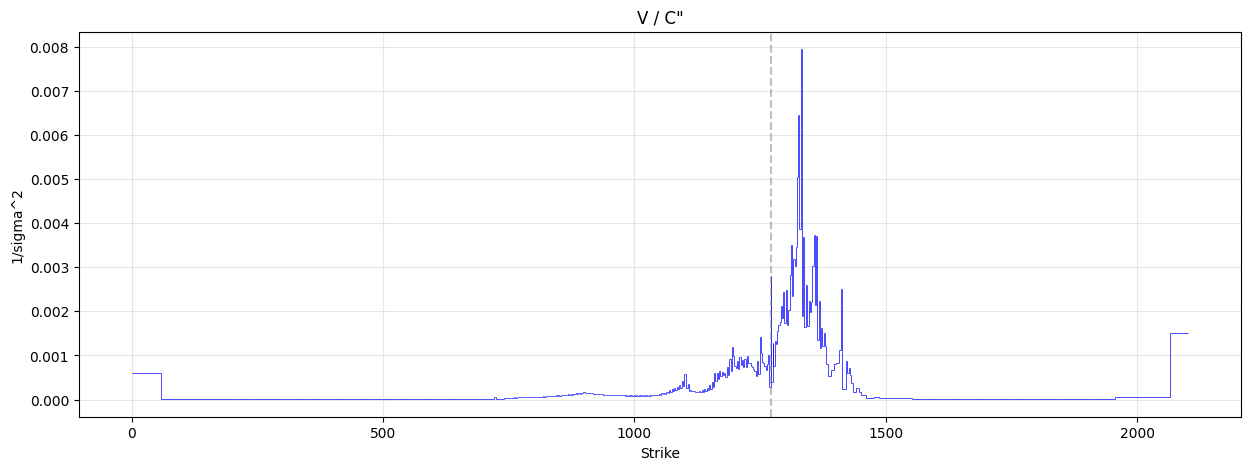

-9.039063504424496 -12.19096593824926 -14.44342900273886 -14.443429005899848


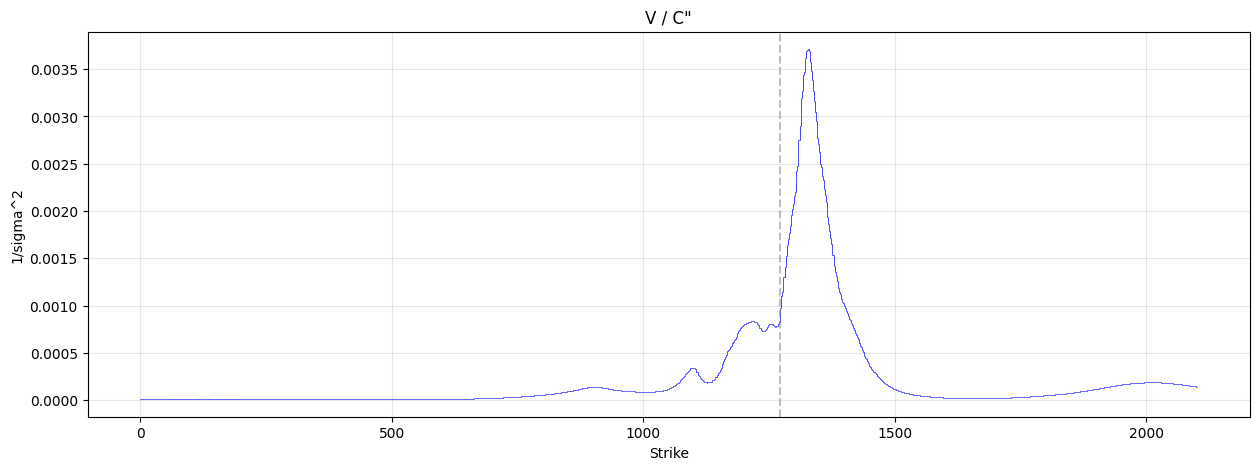

Date:  20110103
ExDate:  20110319
Checking regression constraints for 123 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


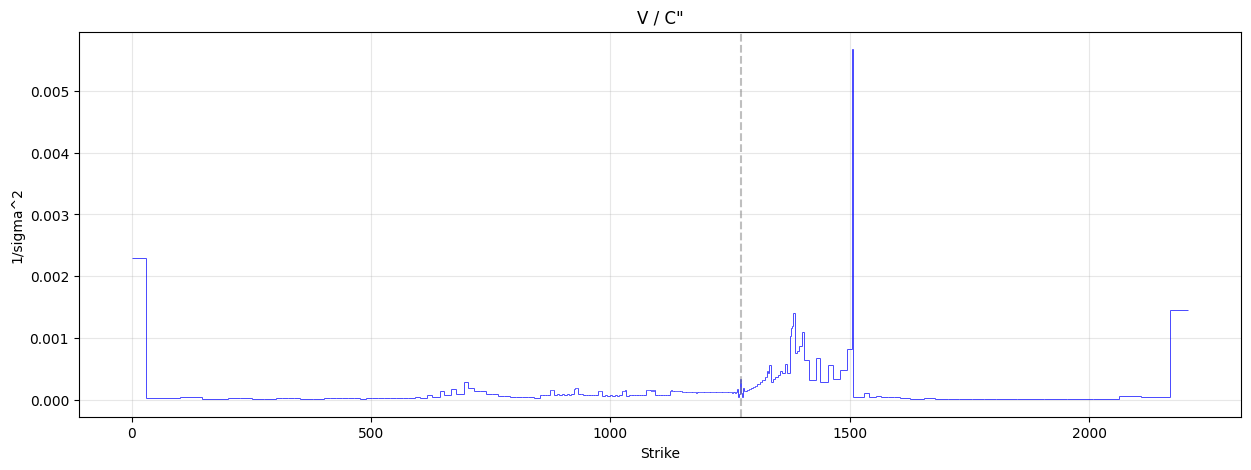

-9.6485203335955 -17.5330780441032 -18.538025296911076 -18.765288225561957


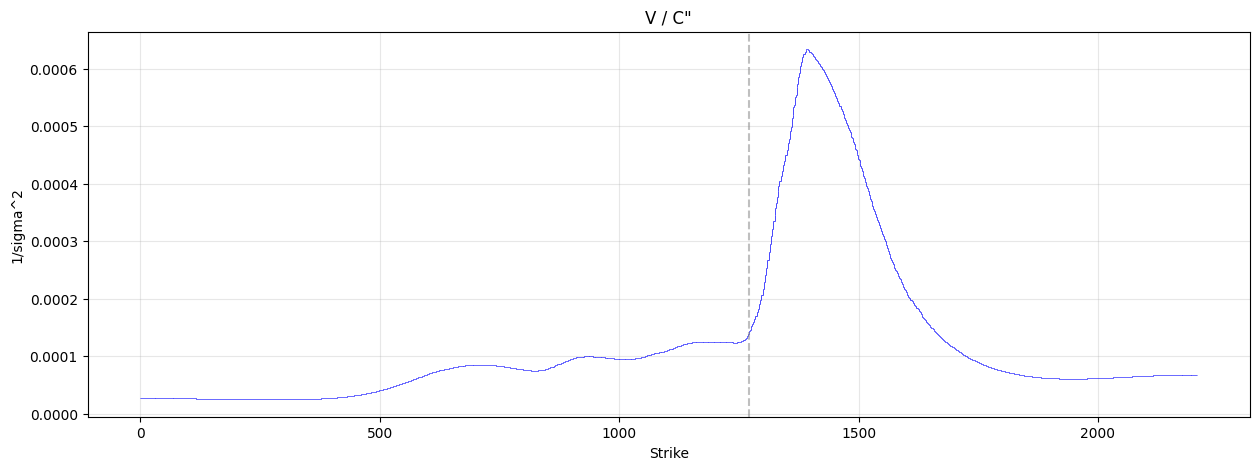

Date:  20110103
ExDate:  20111217
Checking regression constraints for 68 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


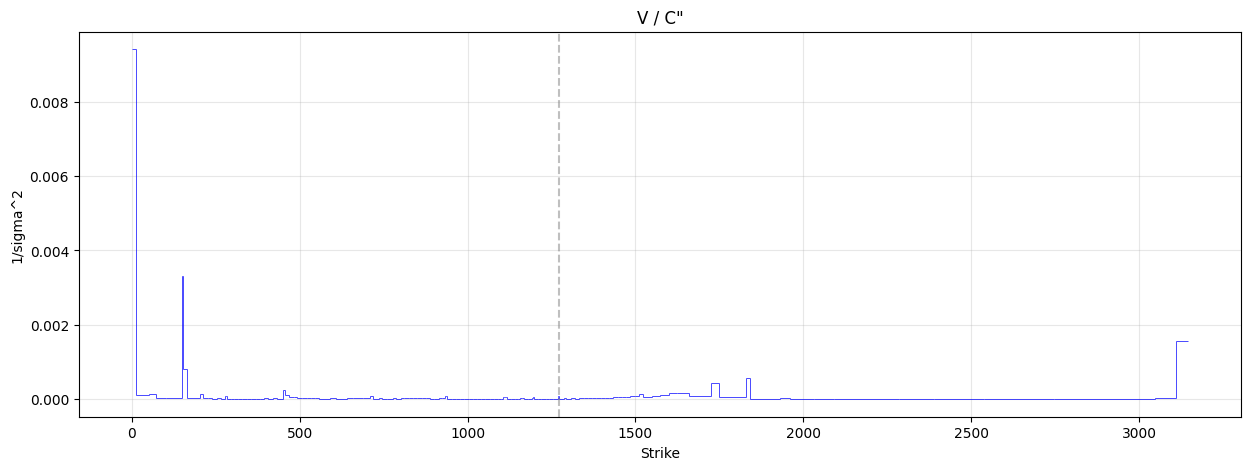

-9.13885927437654 -14.527784531295419 -15.001528982318355 -15.048840194001215


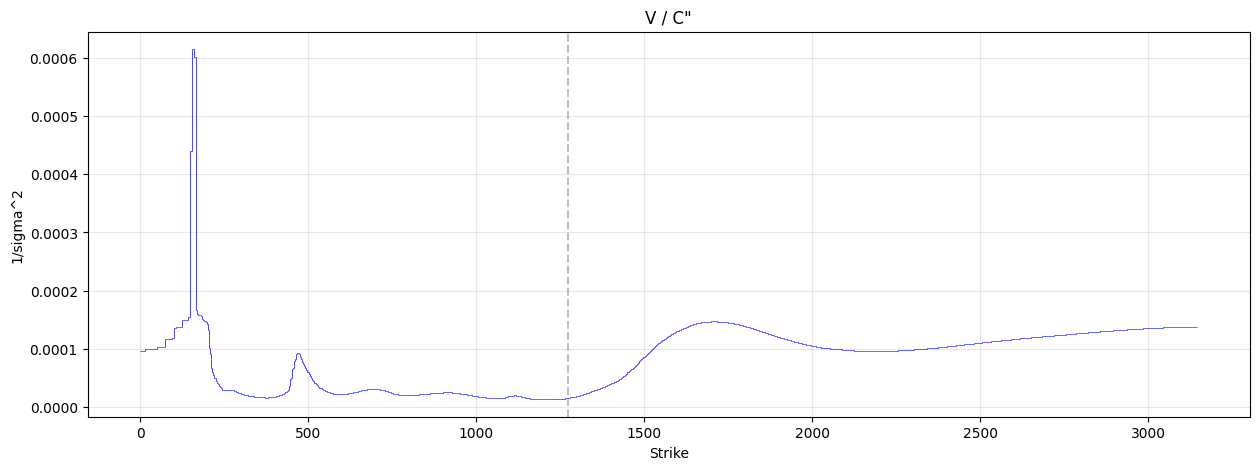

Date:  20110103
ExDate:  20110219
Checking regression constraints for 156 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


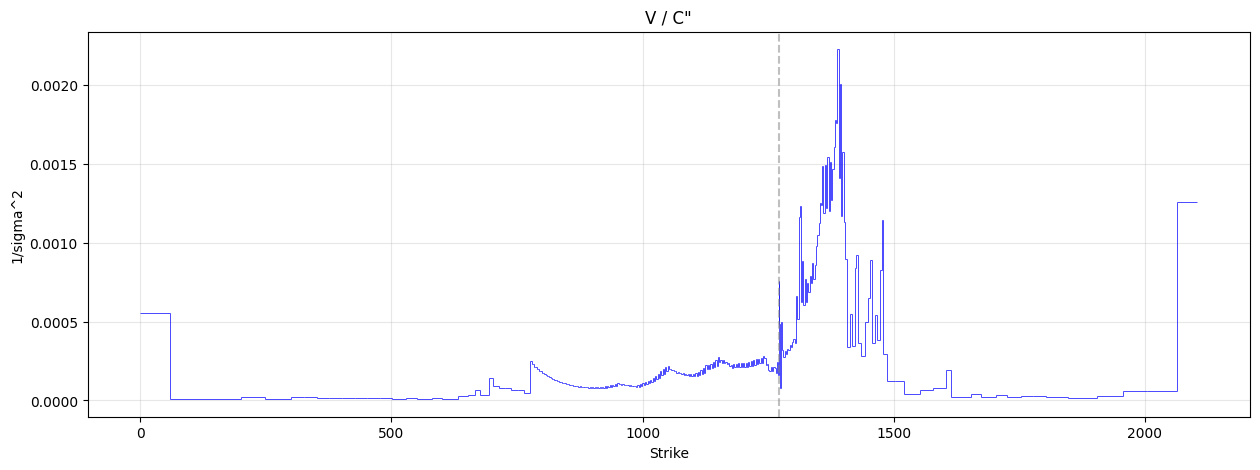

-11.561976780049331 -15.039961076982493 -16.542891817947037 -16.723348760084452


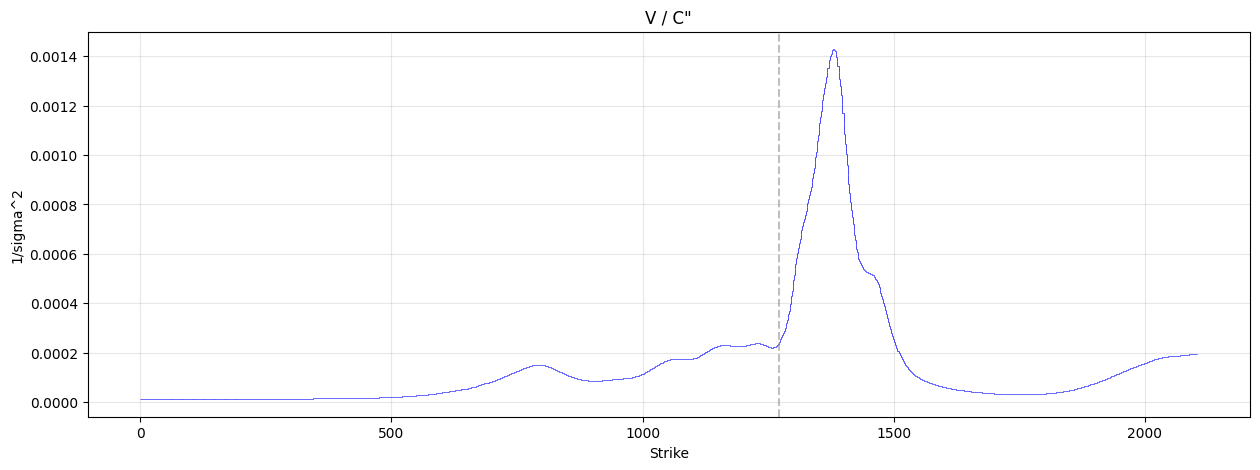

Date:  20110103
ExDate:  20110416
Checking regression constraints for 40 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


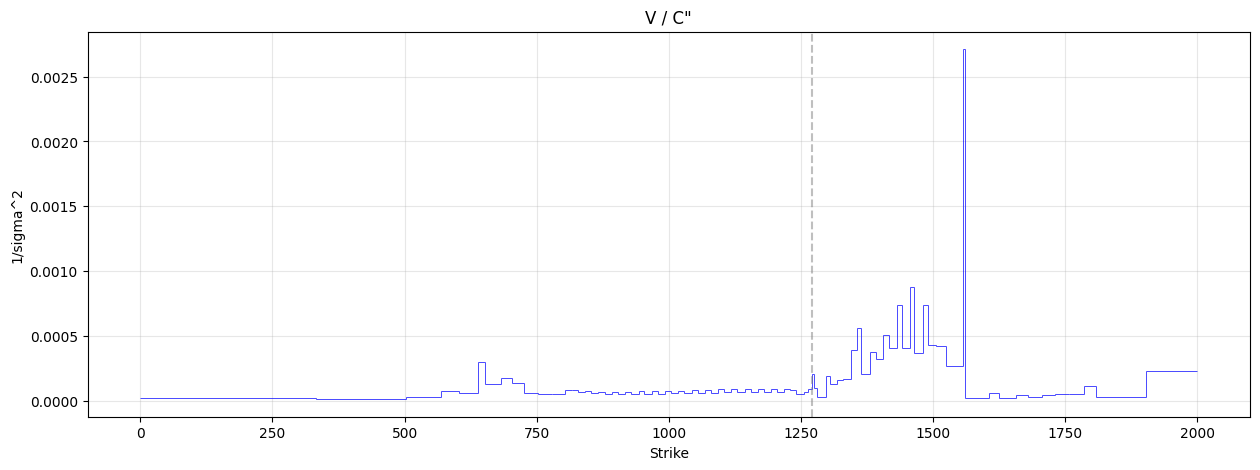

-11.128561825688939 -18.322793657669195 -19.552066511831537 -19.568630271767454


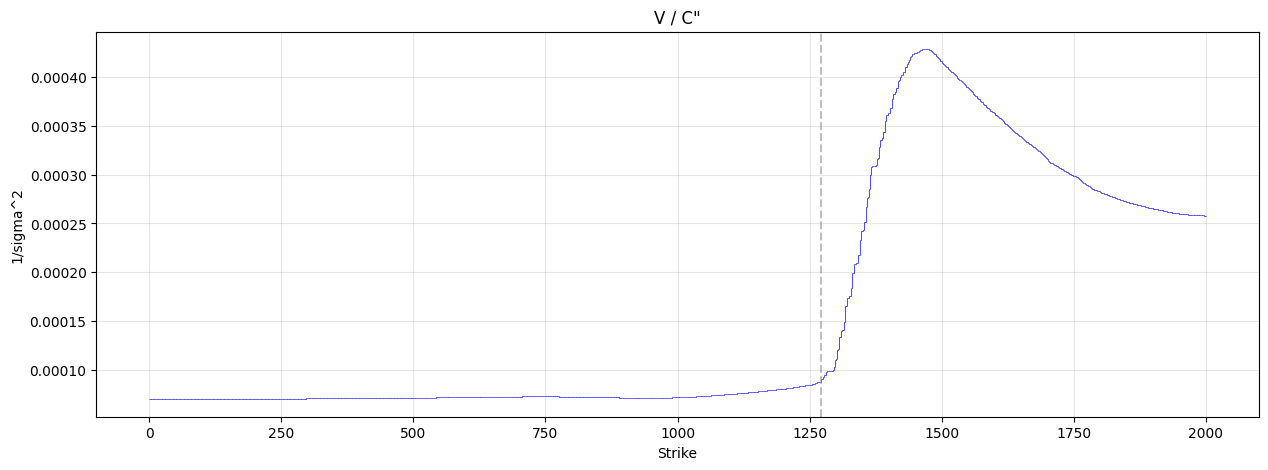

Date:  20110103
ExDate:  20110618
Checking regression constraints for 64 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


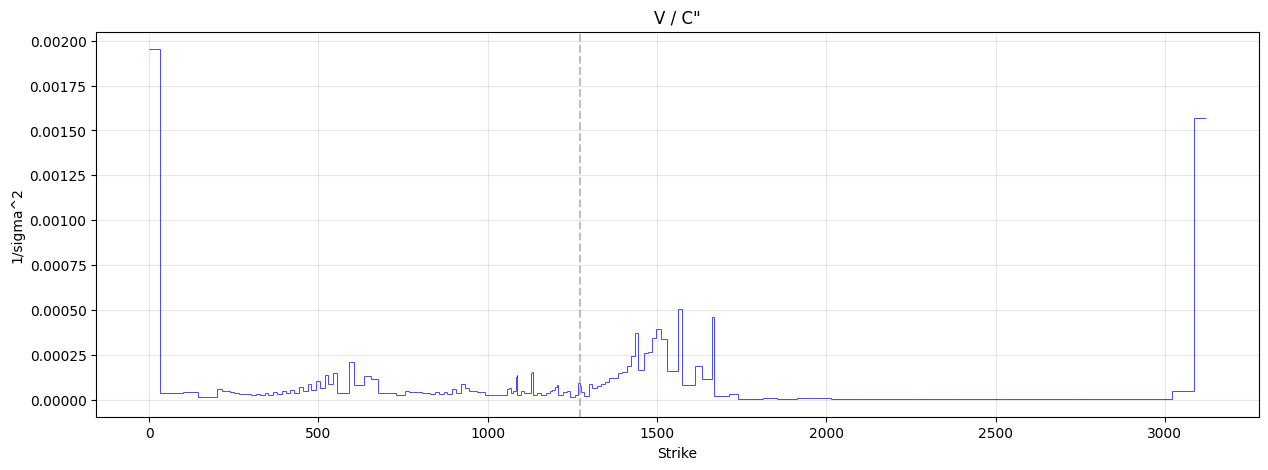

-11.881642333000205 -19.513056455818614 -20.040600757433545 -20.04069777133269


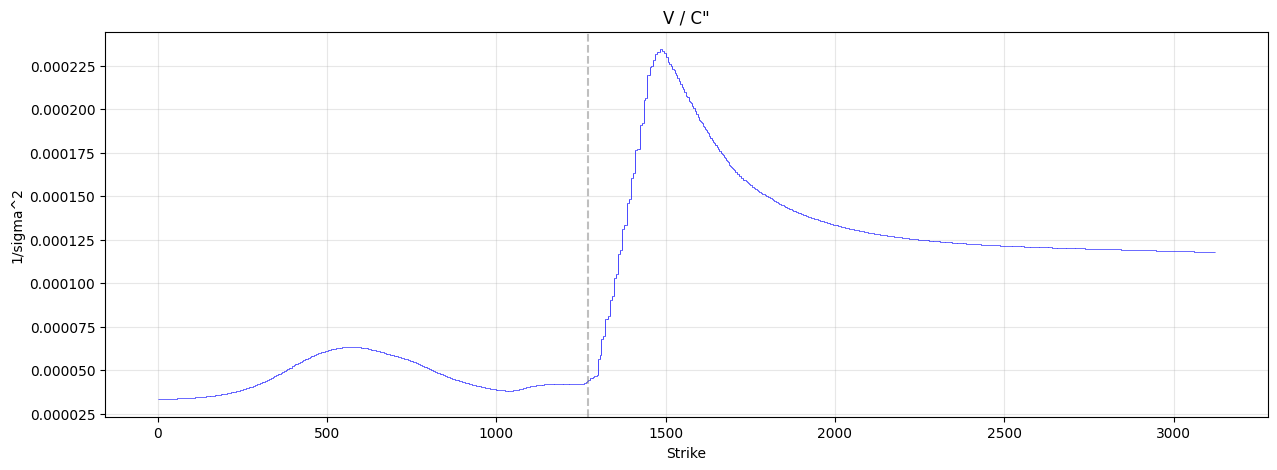

Date:  20110103
ExDate:  20110107
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


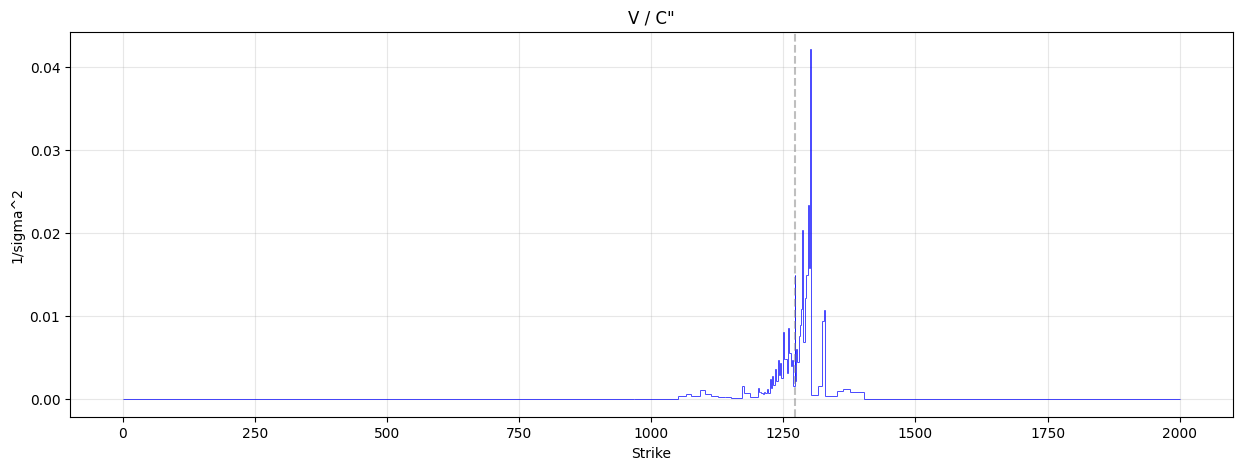

-5.666254114565955 -8.698899386727923 -9.417157118972812 -9.4171571214536


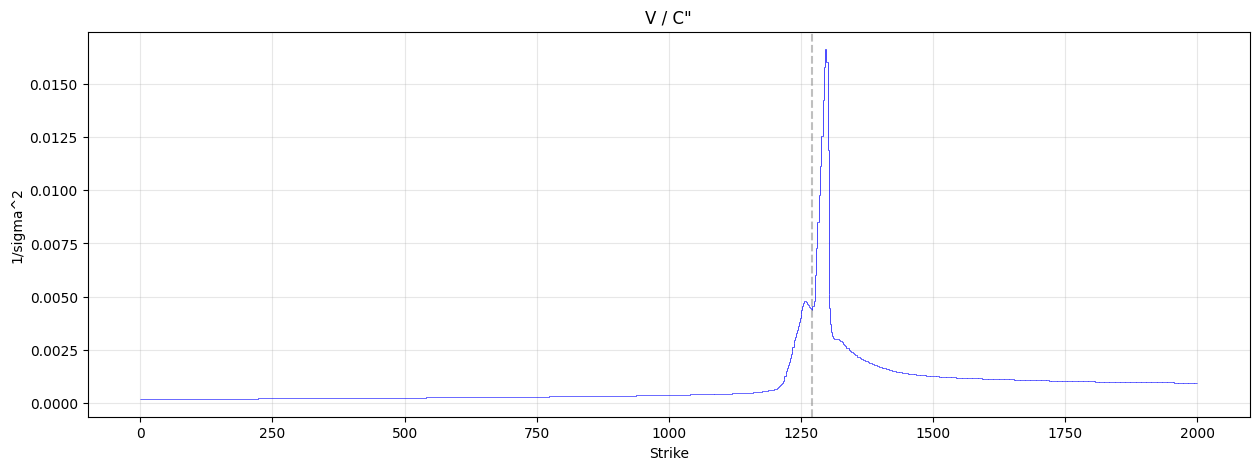

Date:  20110103
ExDate:  20110331
Checking regression constraints for 39 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


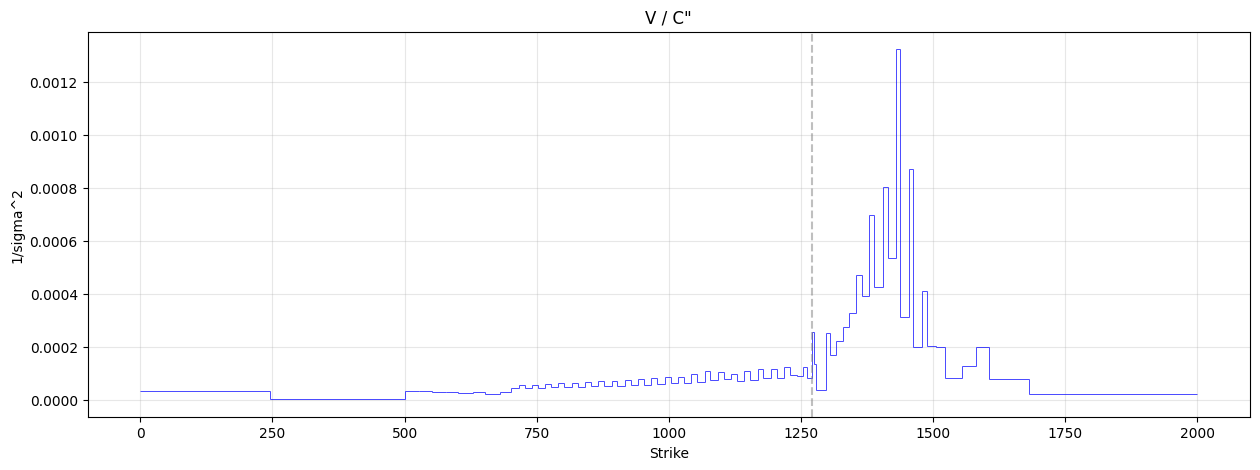

-12.6843929224529 -17.71395021343766 -18.949422464169928 -19.46452981174419


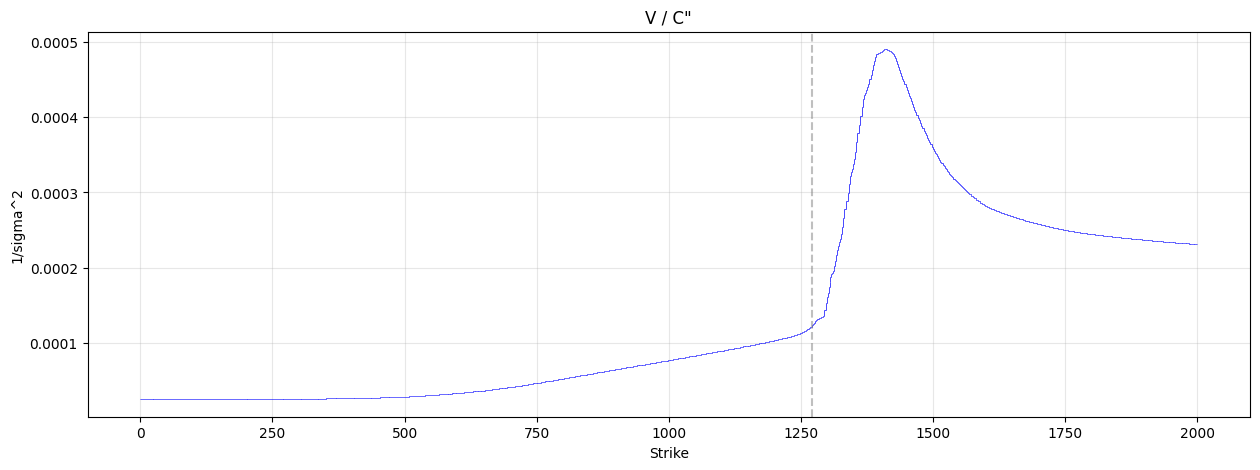

Date:  20110103
ExDate:  20110630
Checking regression constraints for 27 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


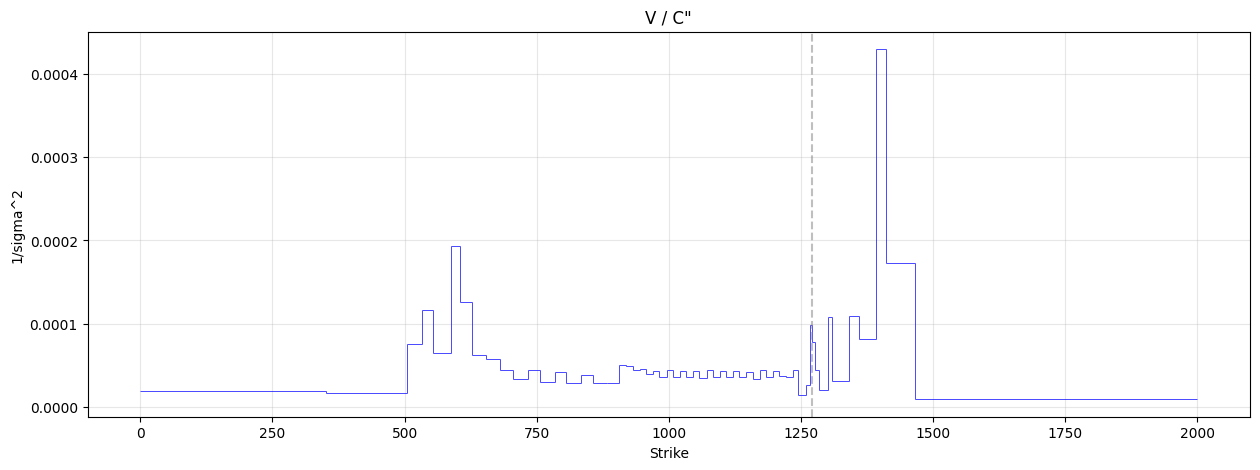

-15.095895546829288 -20.143987712649857 -22.171344600434605 -22.19843466648598


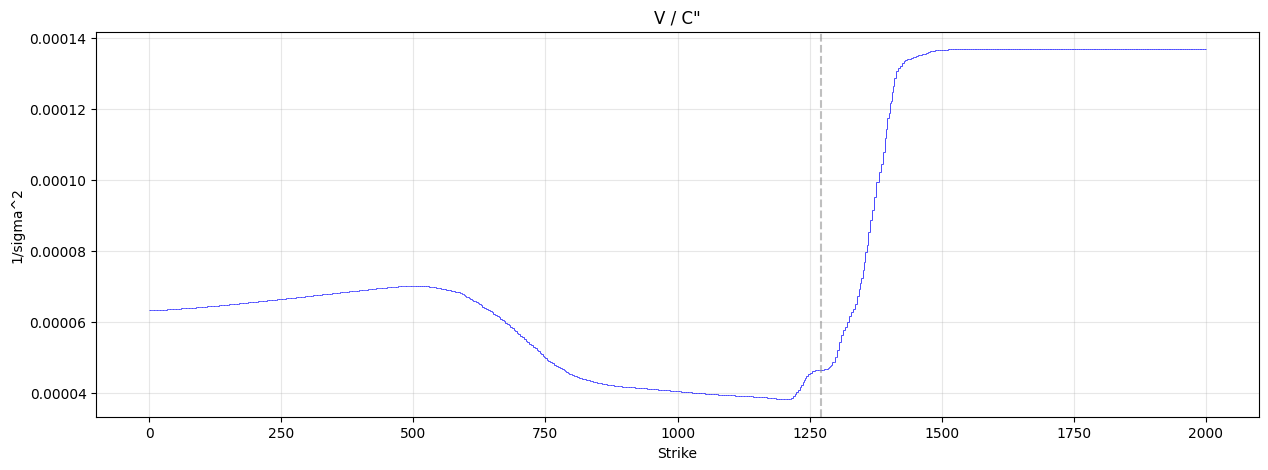

Date:  20110103
ExDate:  20110917
Checking regression constraints for 55 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


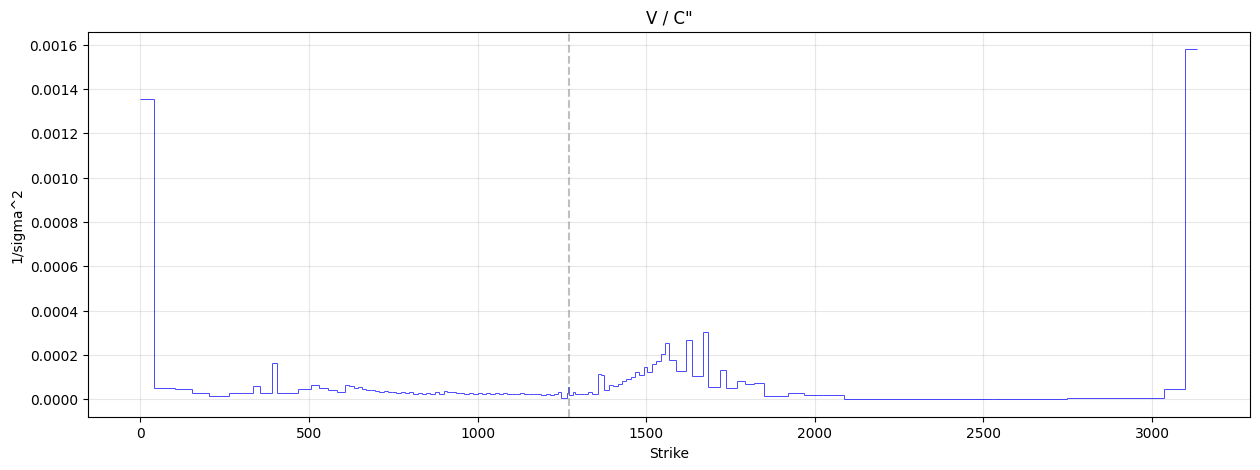

-12.358463860491335 -21.004577428870935 -22.147846273174093 -22.150349533700705


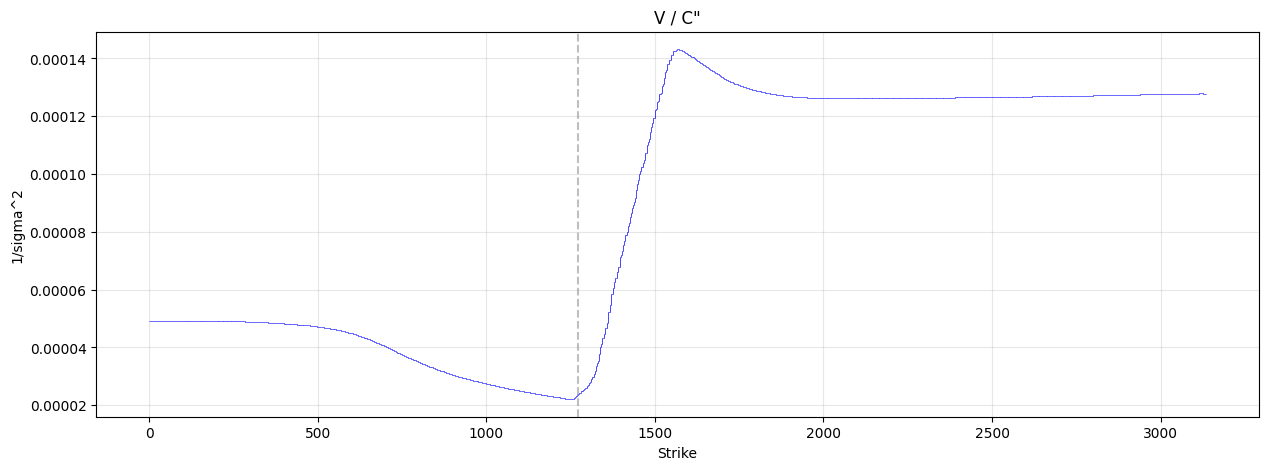

Date:  20110103
ExDate:  20110930
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


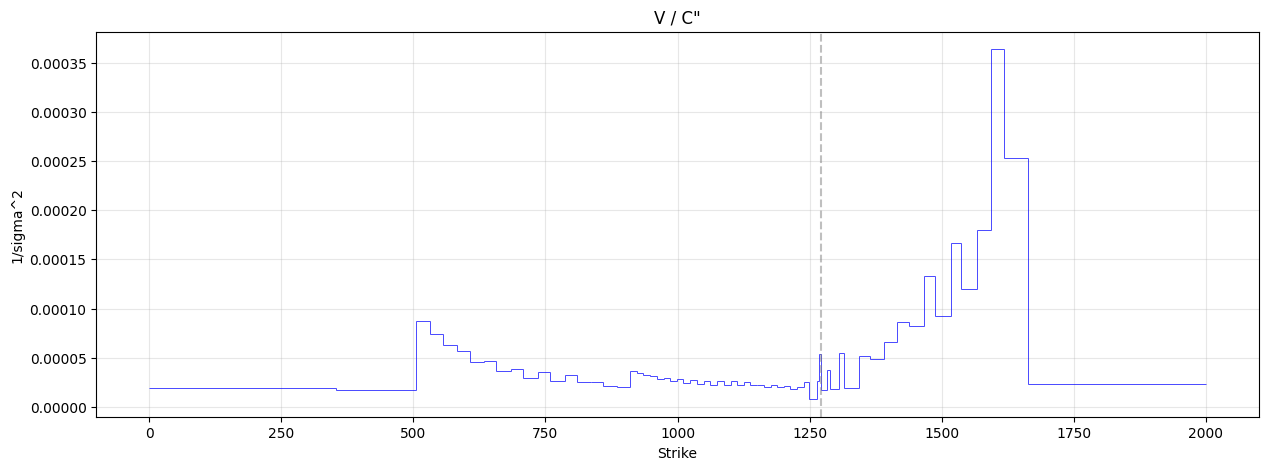

-15.864325952722176 -20.42471434743824 -22.39736070272282 -22.39889334210276


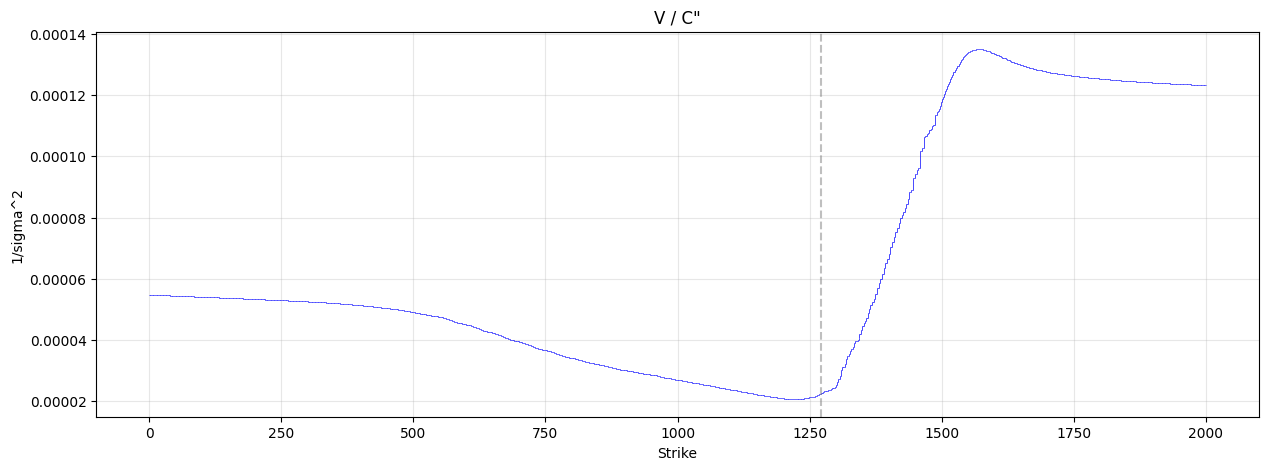

Date:  20110103
ExDate:  20111230
Checking regression constraints for 24 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


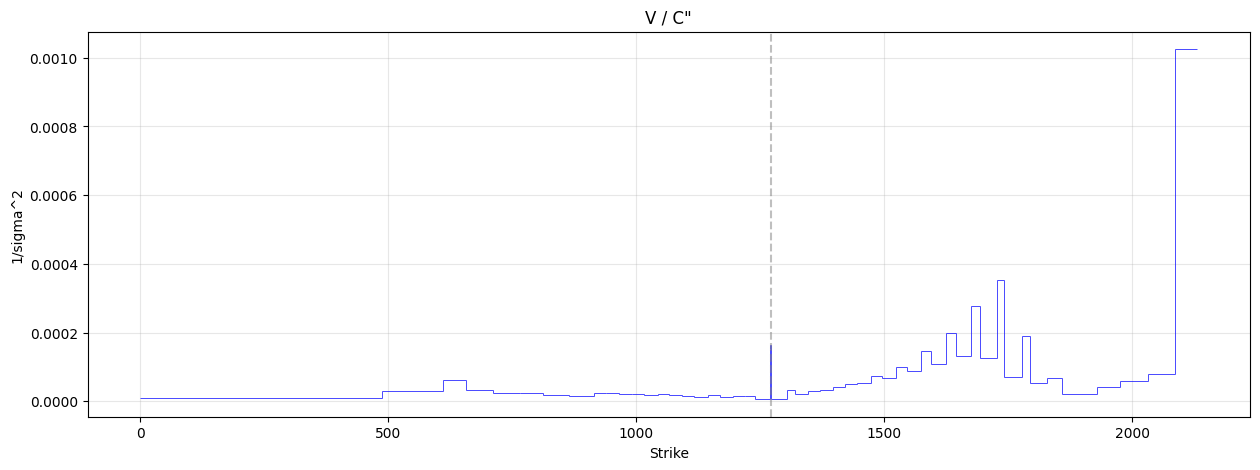

-13.654687555908346 -18.989444392765794 -21.84009342818726 -21.840436542677136


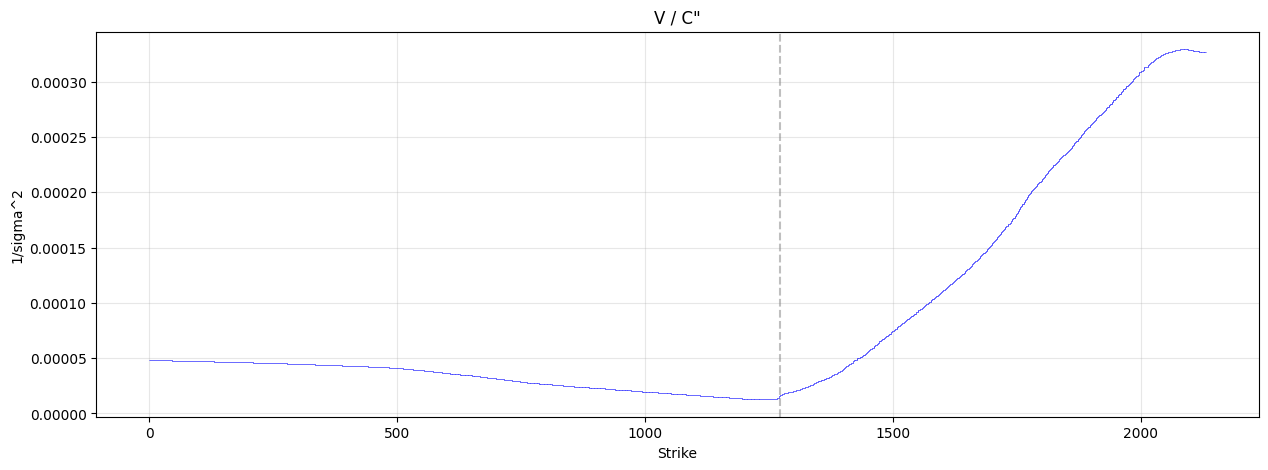

Date:  20110104
ExDate:  20110122
Checking regression constraints for 159 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


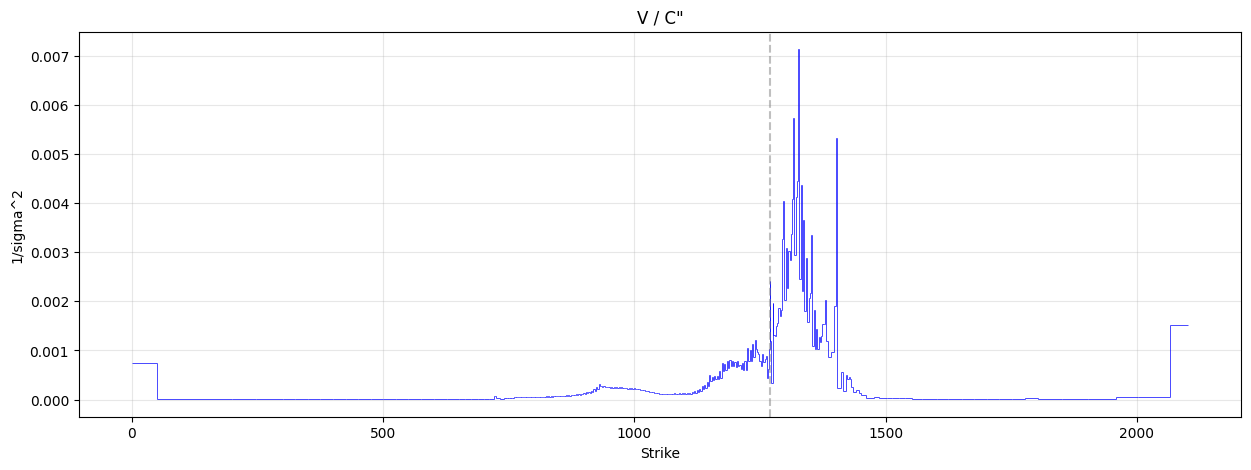

-8.96164343965386 -12.973154664213512 -14.262686678815792 -14.26268668032632


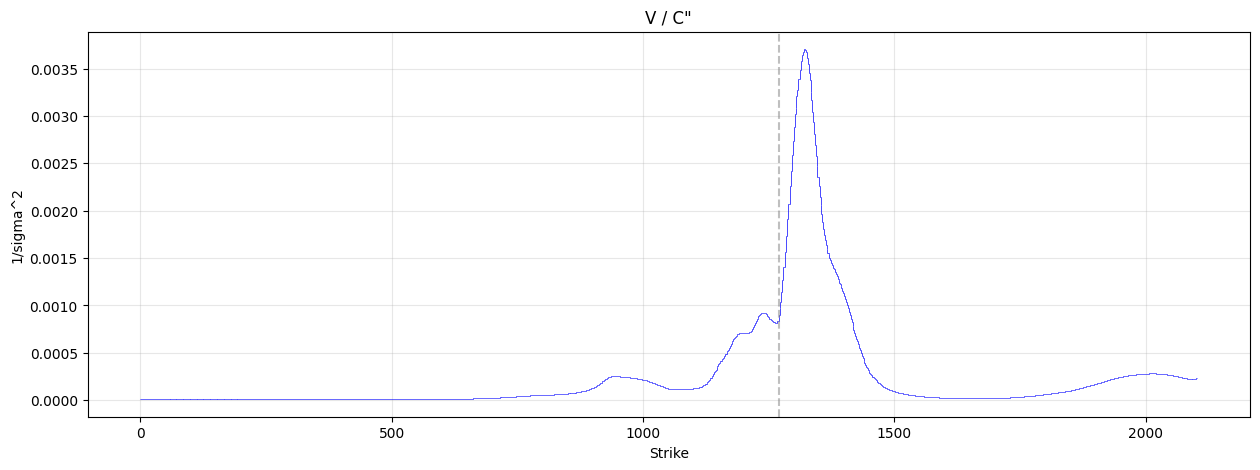

Date:  20110104
ExDate:  20110319
Checking regression constraints for 123 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


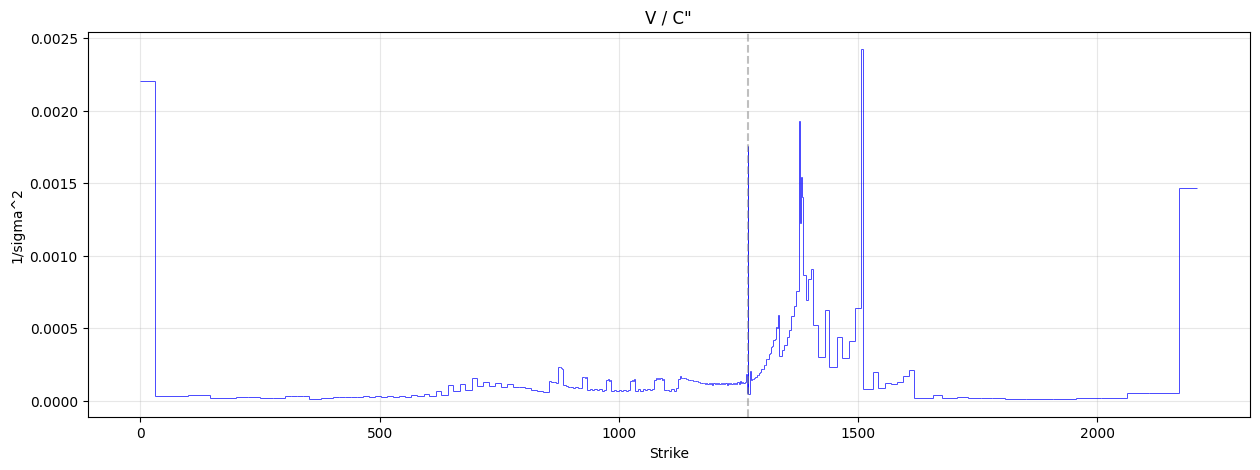

-10.629359712465451 -17.239985143741563 -18.09506165081436 -18.38985687380881


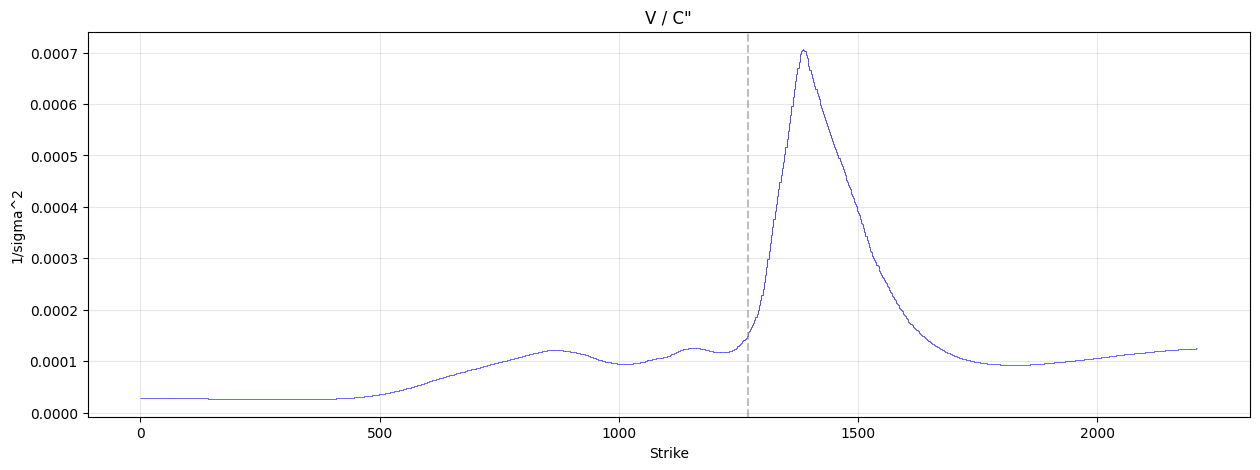

Date:  20110104
ExDate:  20111217
Checking regression constraints for 68 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


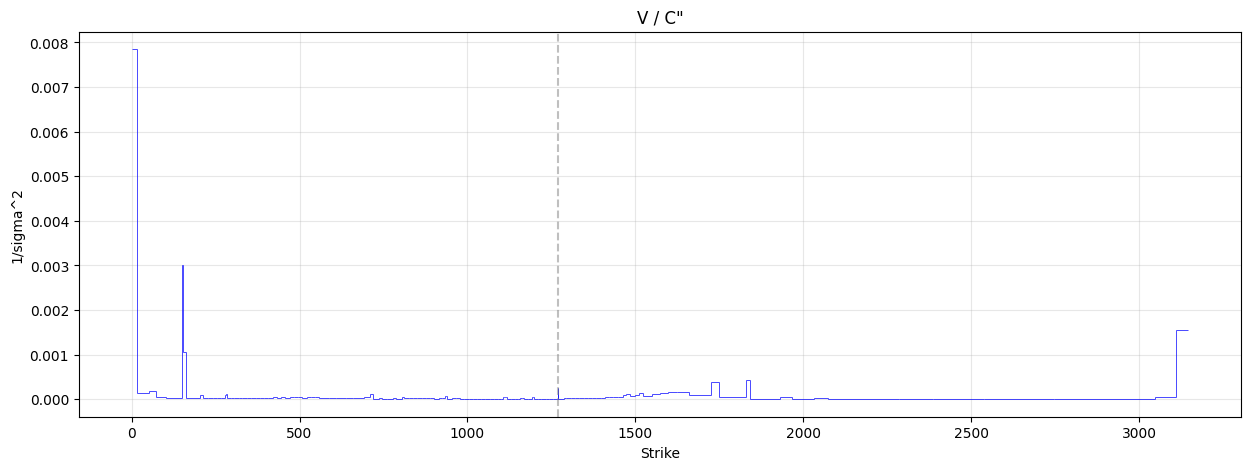

-9.47842936639787 -14.121966239718175 -15.524454626295416 -15.586074856954388


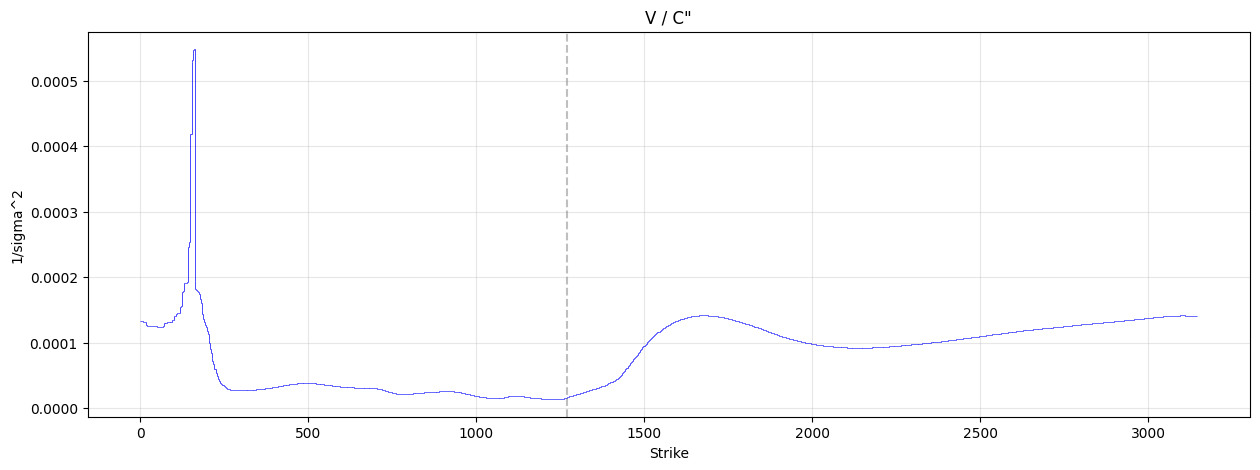

Date:  20110104
ExDate:  20110219
Checking regression constraints for 156 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


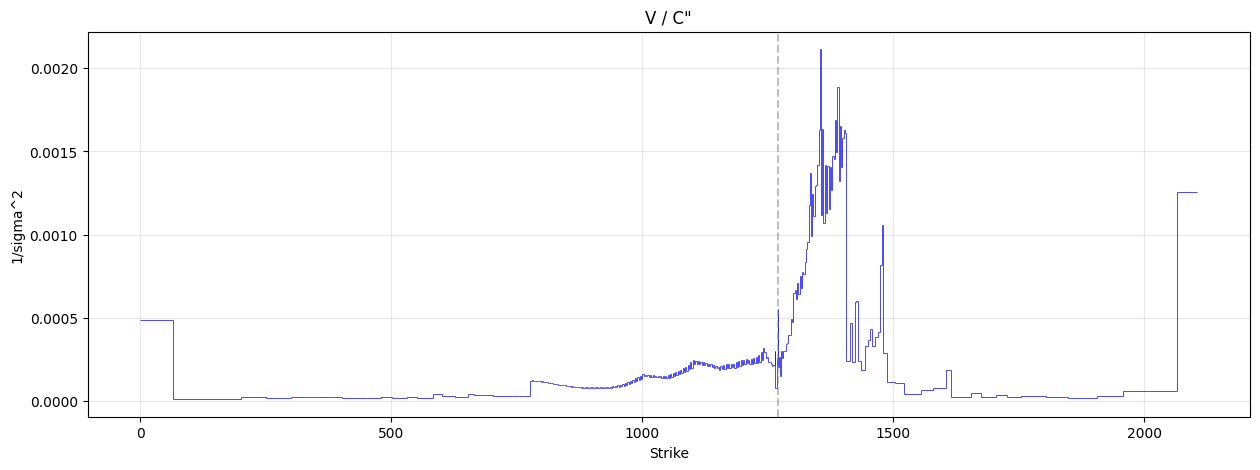

-11.637924640214335 -14.81056829322884 -16.434409186156106 -16.720749028032124


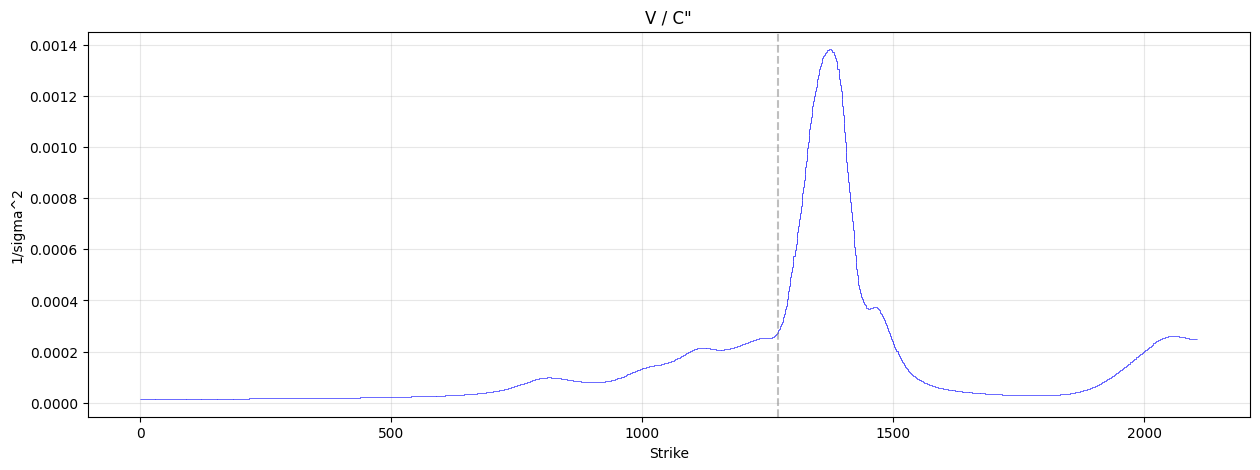

Date:  20110104
ExDate:  20110416
Checking regression constraints for 40 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


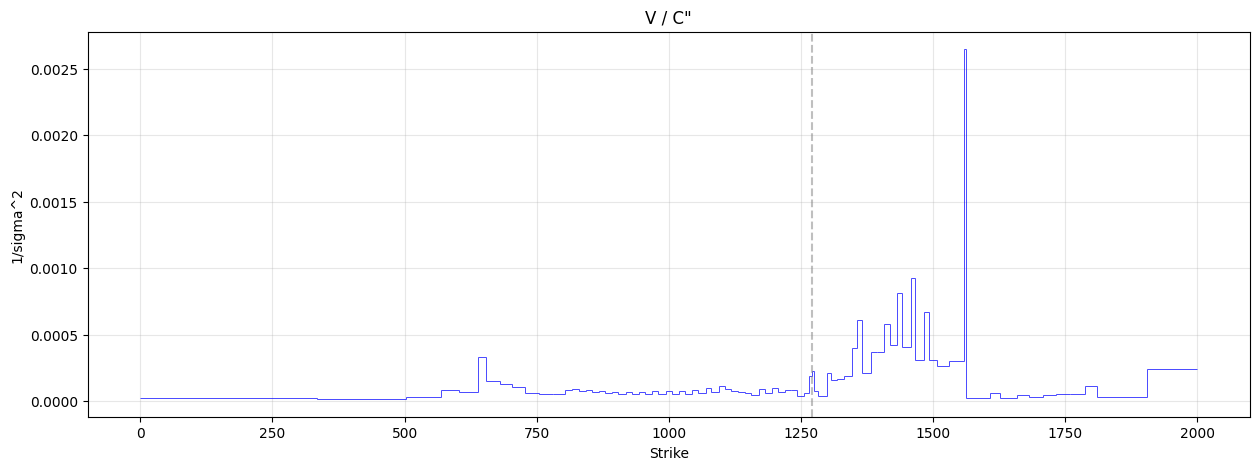

-11.157546489431448 -18.263398272399726 -18.78044029820111 -18.780440300761292


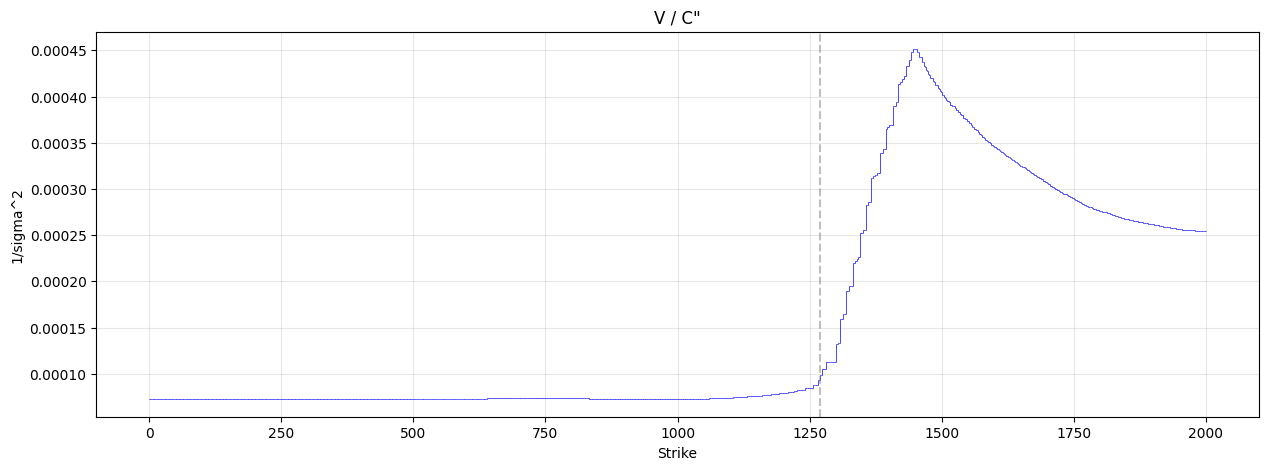

Date:  20110104
ExDate:  20110618
Checking regression constraints for 67 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


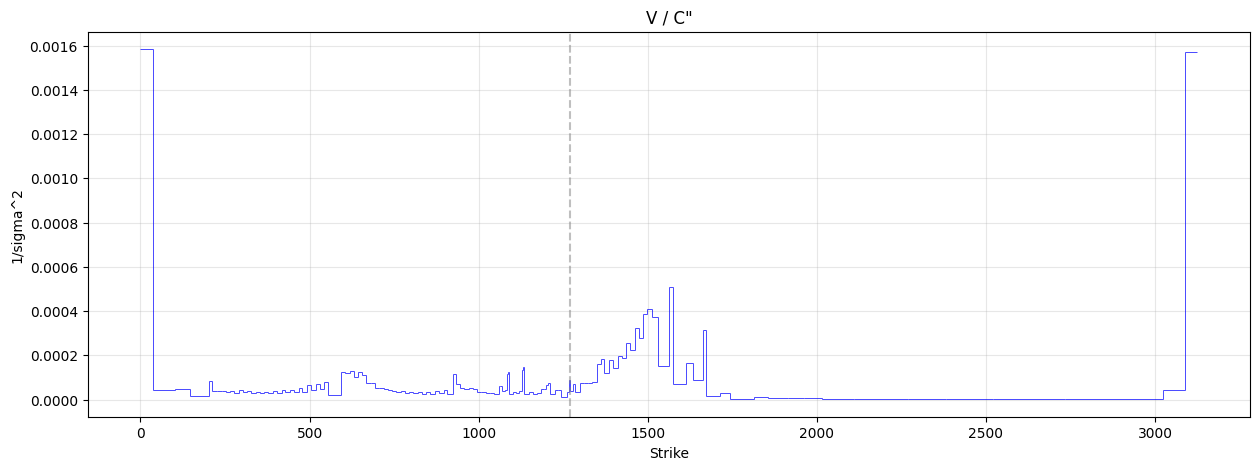

-12.135247267647262 -19.424275523944313 -19.739599672585815 -19.739864264895598


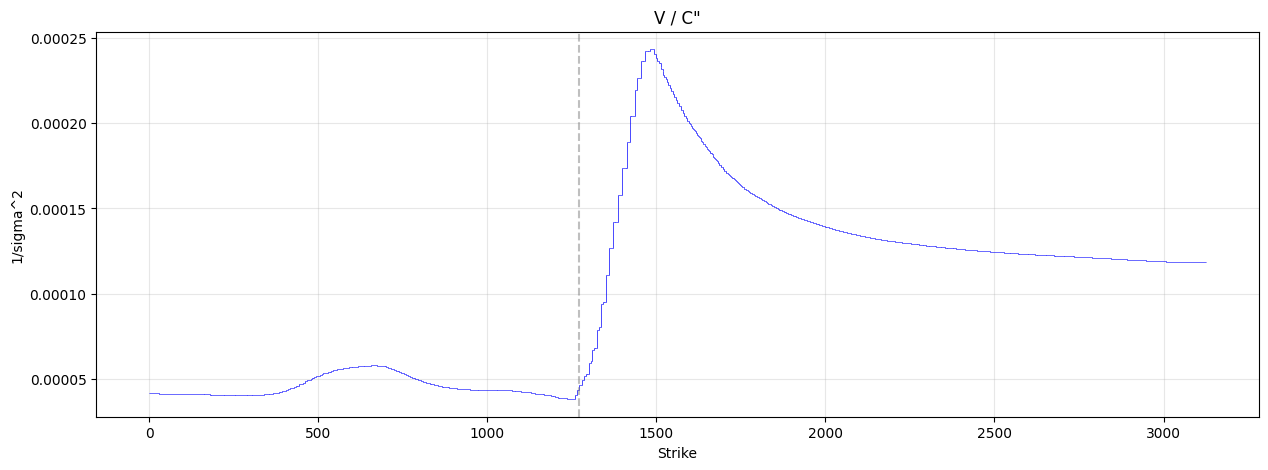

Date:  20110104
ExDate:  20110107
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


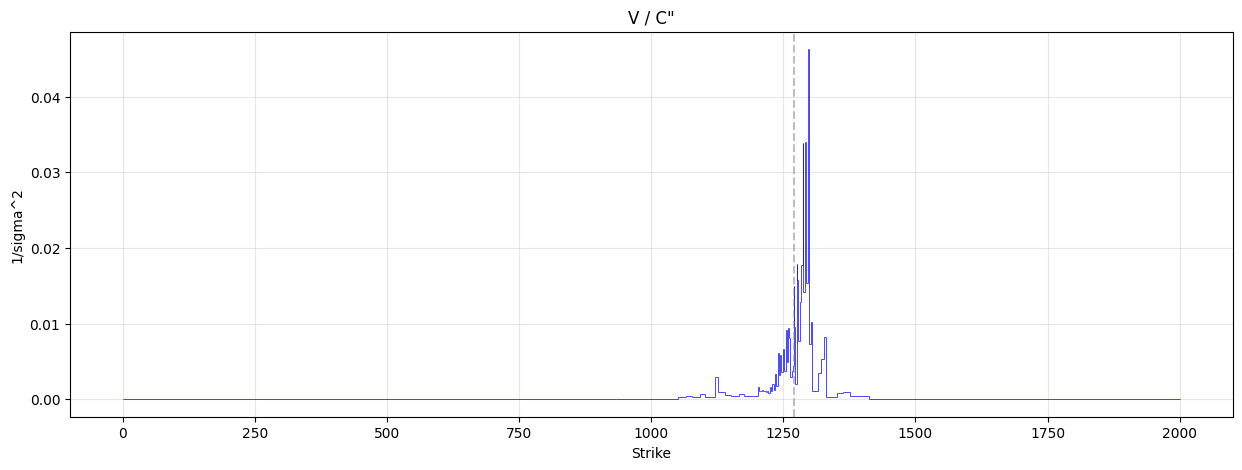

-5.343036191799869 -8.378609729717814 -8.42343761622506 -8.423437616975132


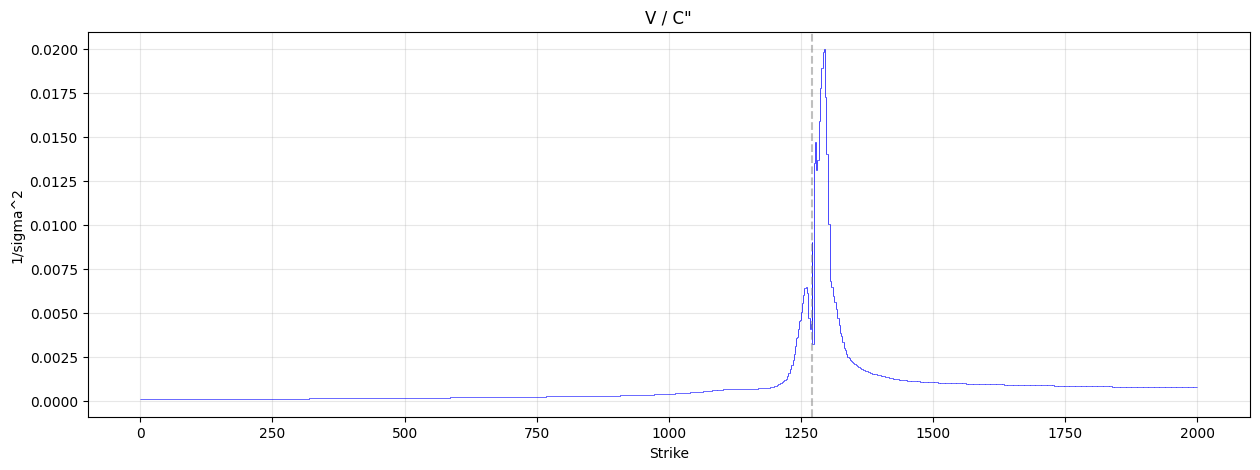

Date:  20110104
ExDate:  20110331
Checking regression constraints for 39 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


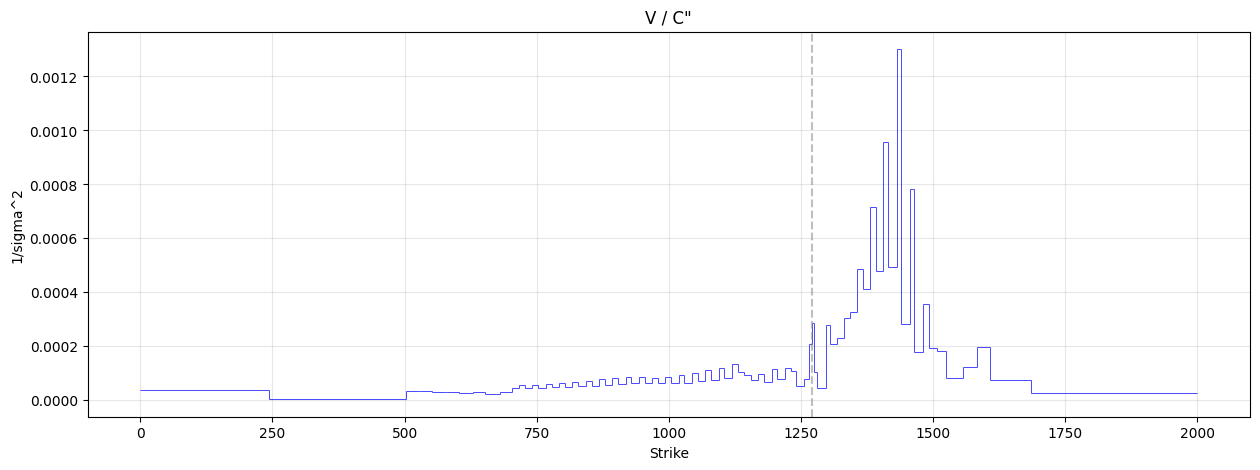

-12.654798114357076 -17.95406523167287 -19.052266098385175 -19.060572632792866


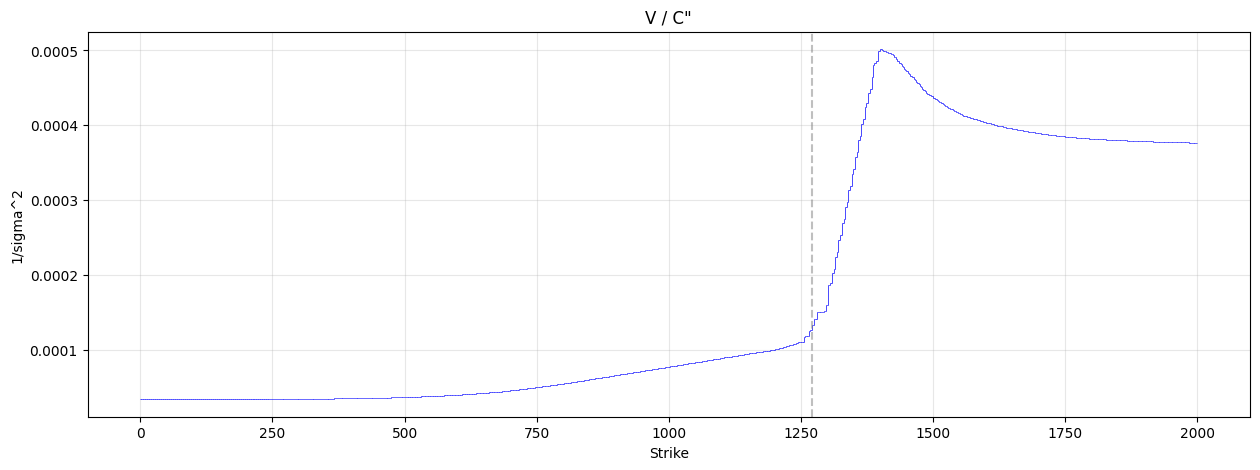

Date:  20110104
ExDate:  20110630
Checking regression constraints for 27 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


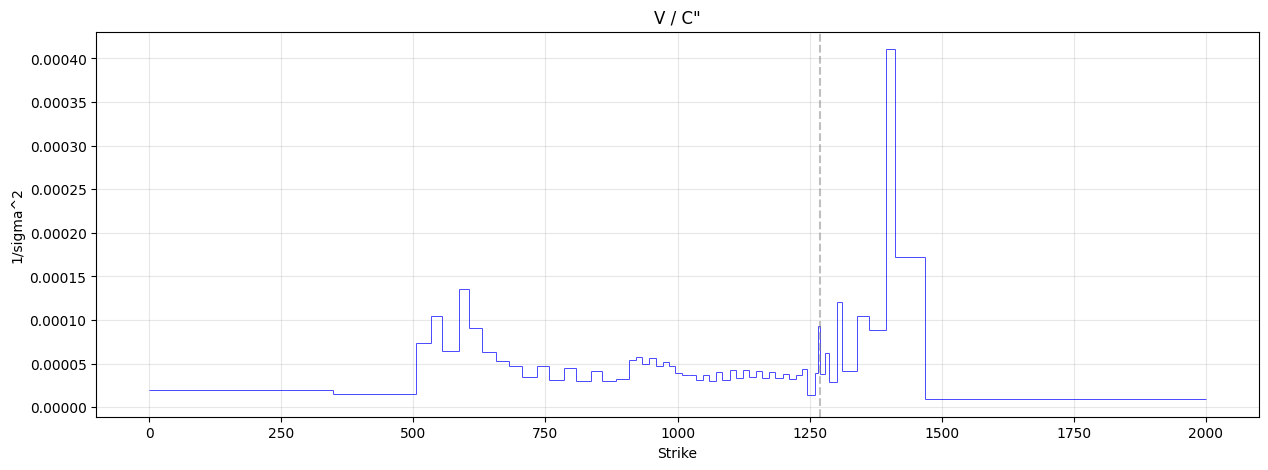

-15.276877299473488 -20.70050964139407 -22.345333023740196 -22.34620852024097


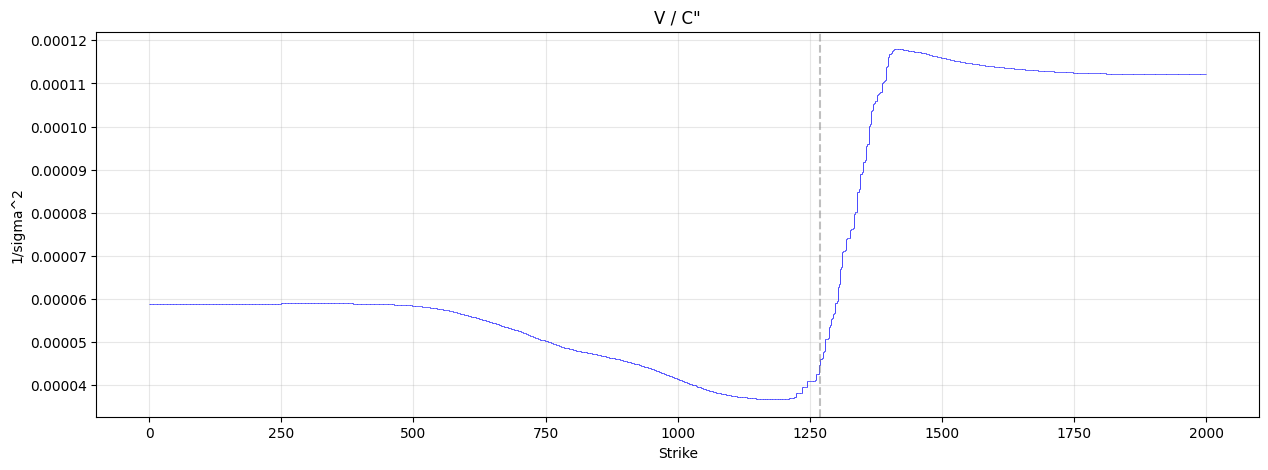

Date:  20110104
ExDate:  20110917
Checking regression constraints for 55 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


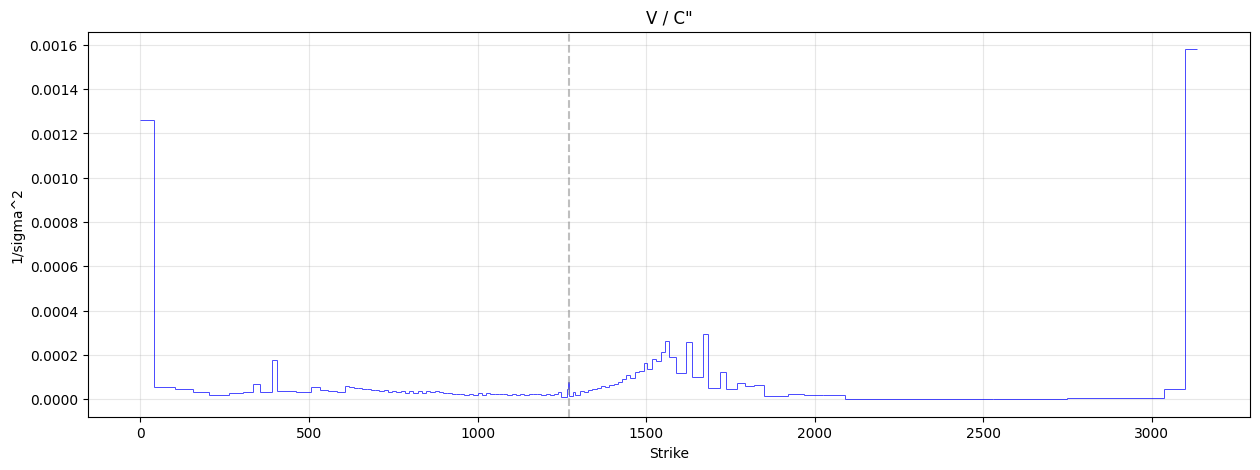

-12.421575096245181 -20.943073991232428 -21.557628796781064 -22.270440474237333


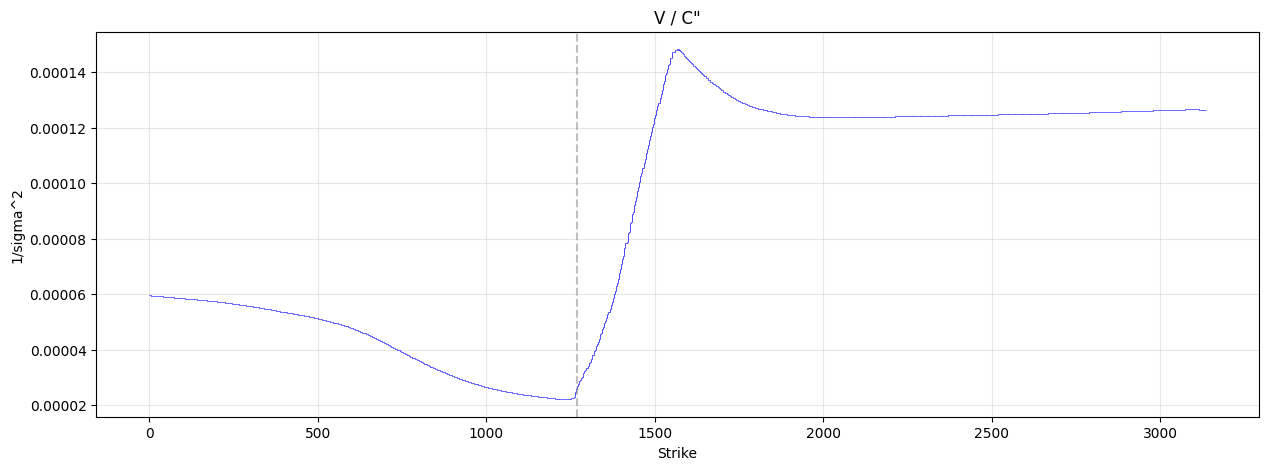

Date:  20110104
ExDate:  20110930
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


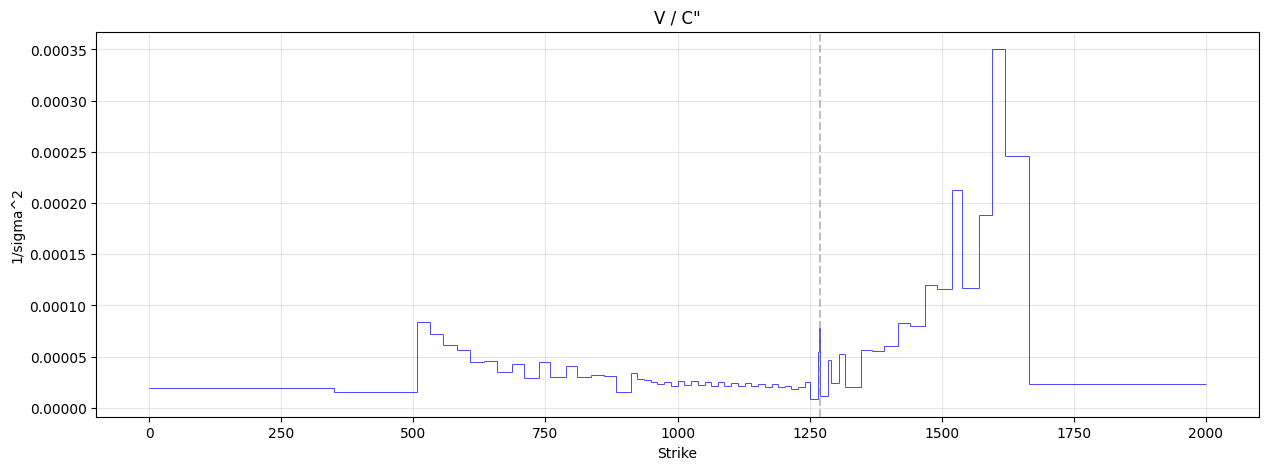

-15.841123787660411 -20.513848698141878 -23.0593033074853 -23.060304049472563


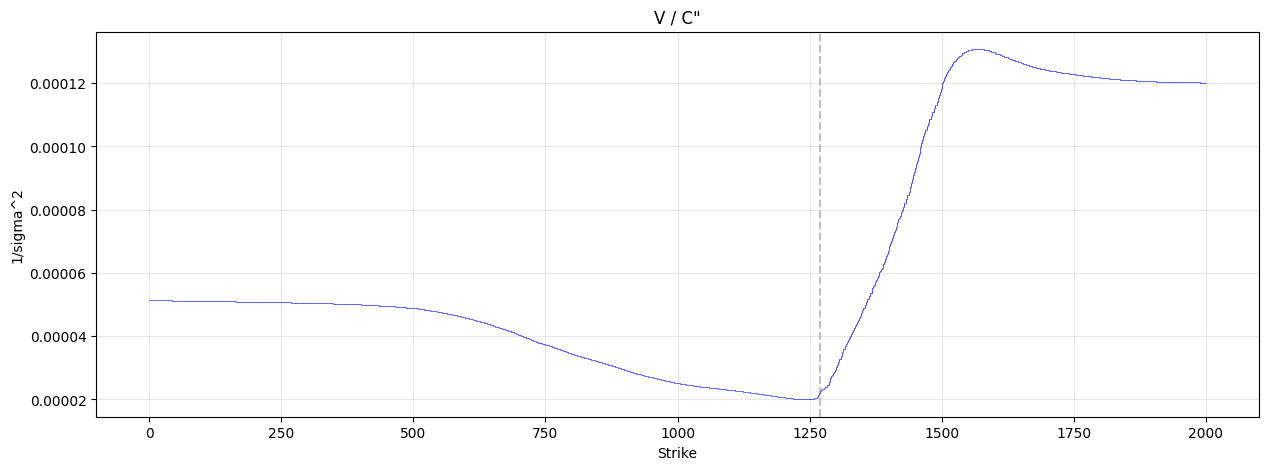

Date:  20110104
ExDate:  20111230
Checking regression constraints for 24 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


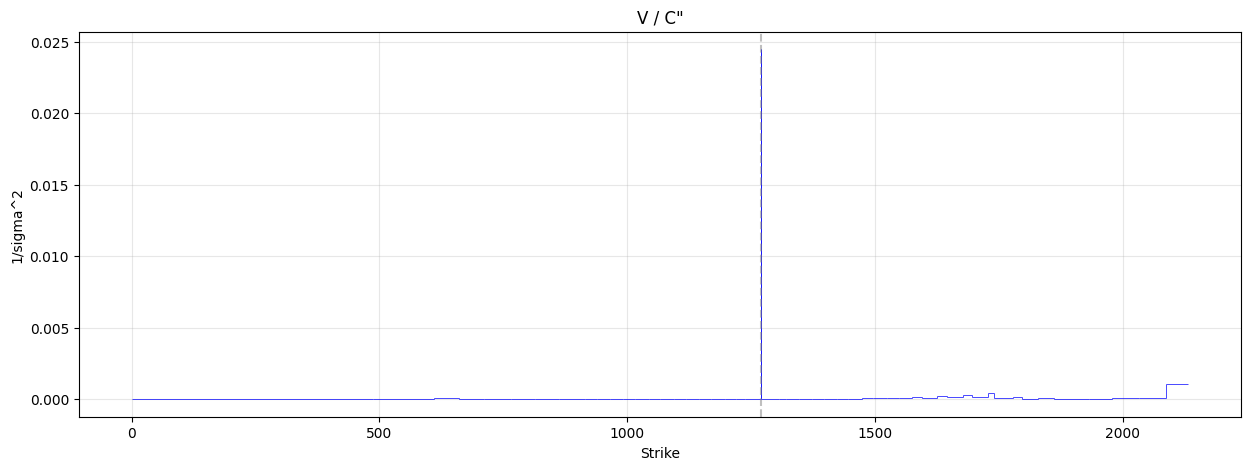

-6.727324968633939 -19.14376915173635 -21.904679281132438 -21.90555445614553


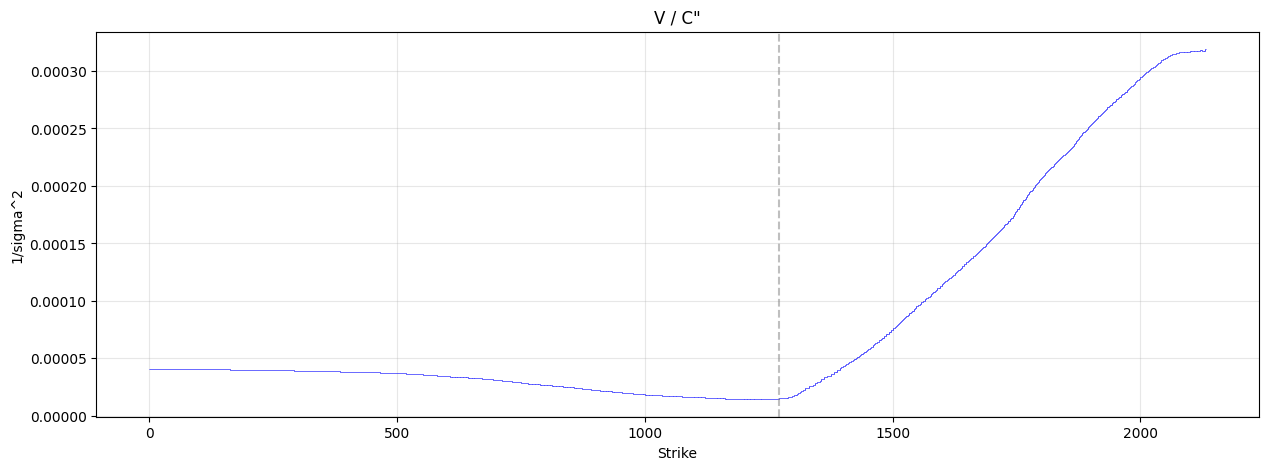

Date:  20110105
ExDate:  20110122
Checking regression constraints for 159 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


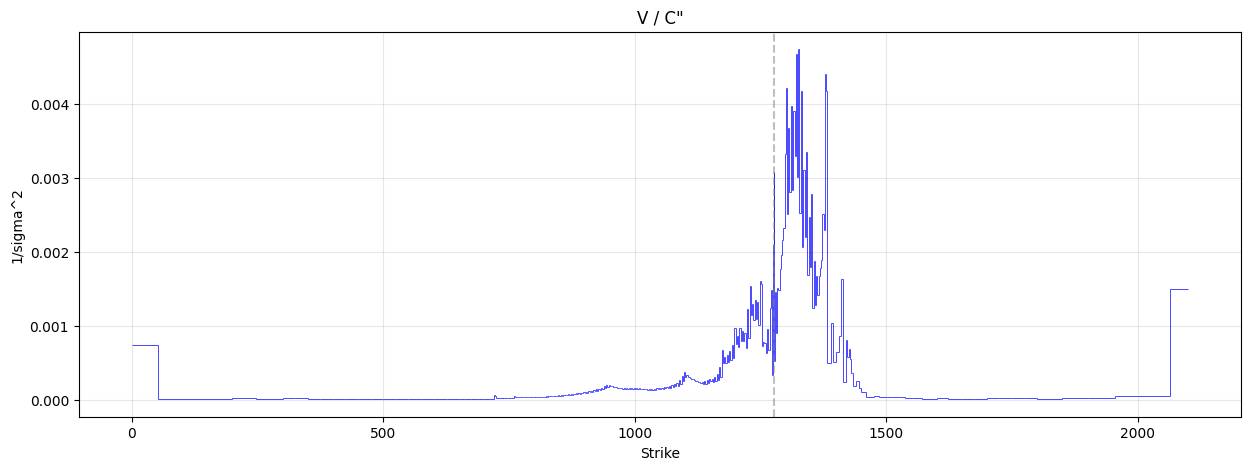

-9.375821470175692 -12.44229463175563 -14.552170037555635 -14.552170042921219


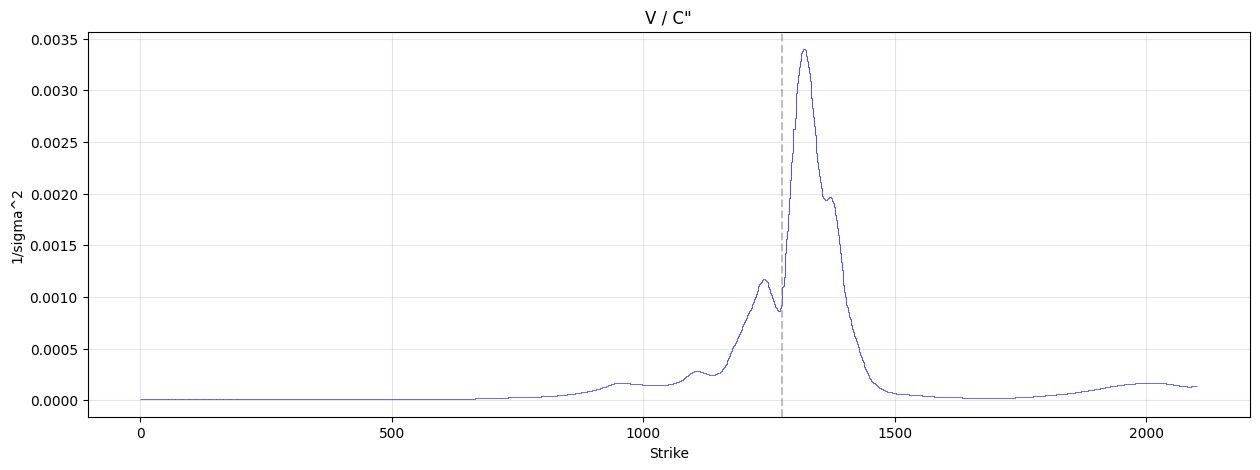

Date:  20110105
ExDate:  20110319
Checking regression constraints for 123 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


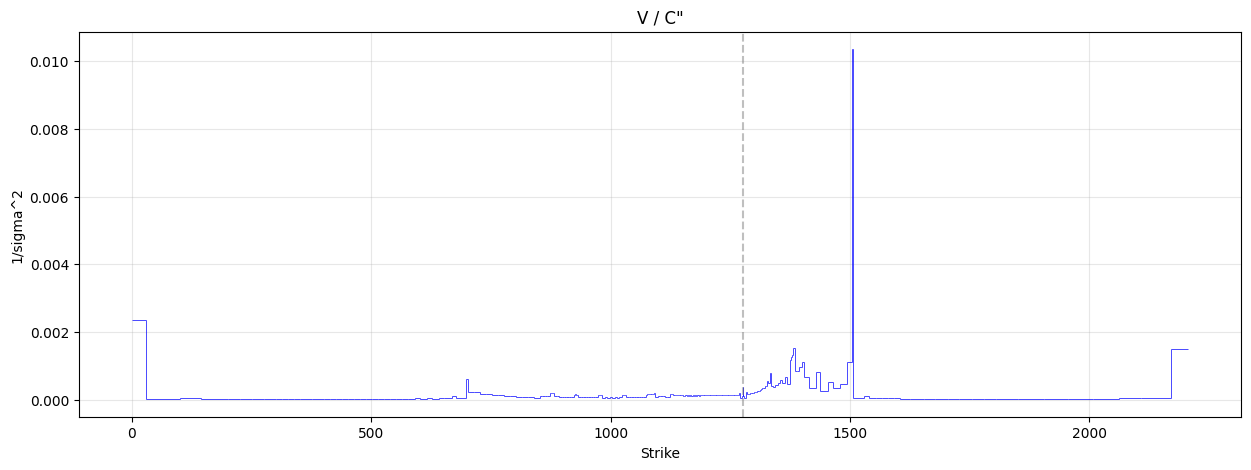

-8.502694947904418 -16.80726469345151 -17.698958401136178 -17.961955476945402


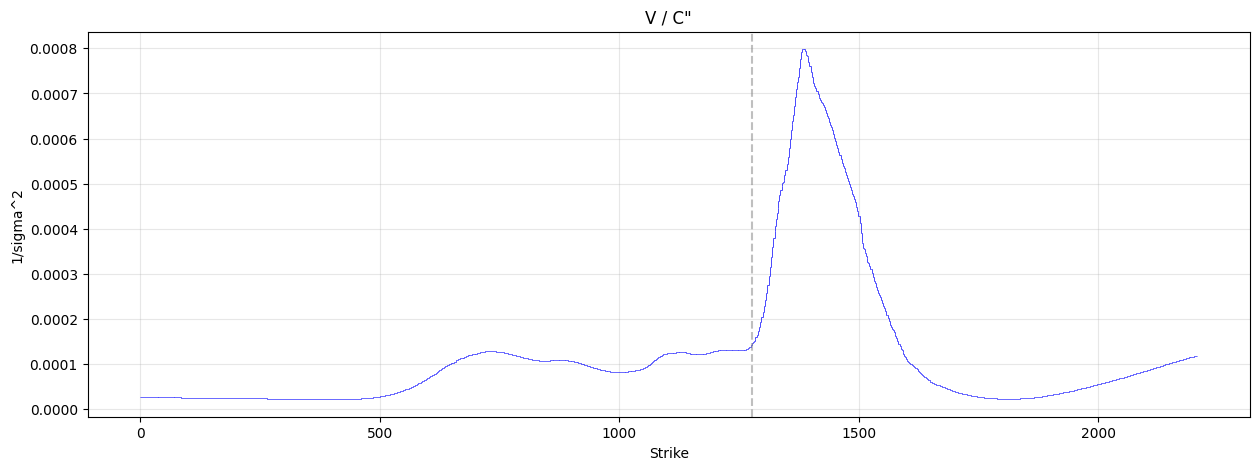

Date:  20110105
ExDate:  20111217
Checking regression constraints for 68 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


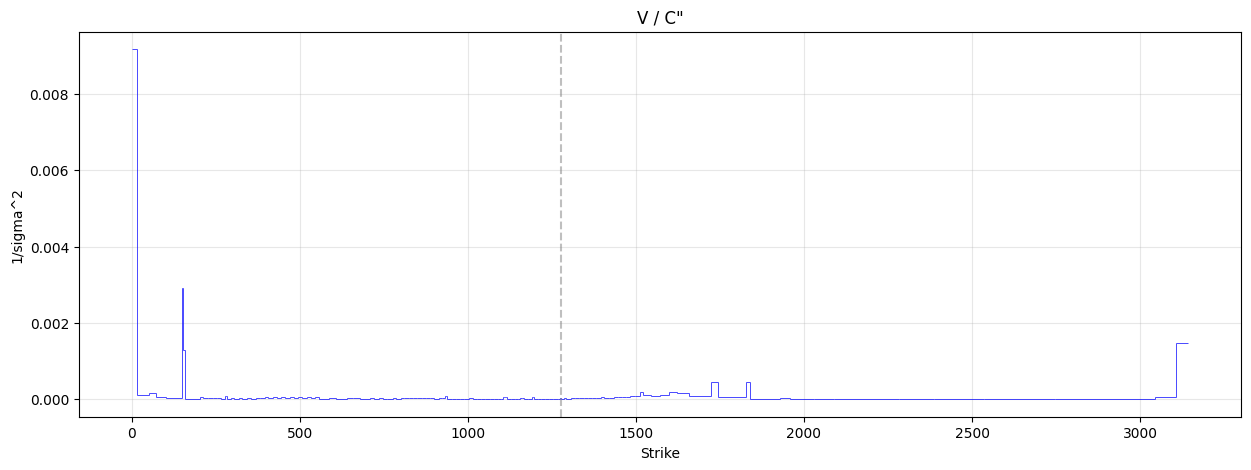

-9.237833317472745 -13.792051405526003 -13.992181639657323 -13.992500261996133


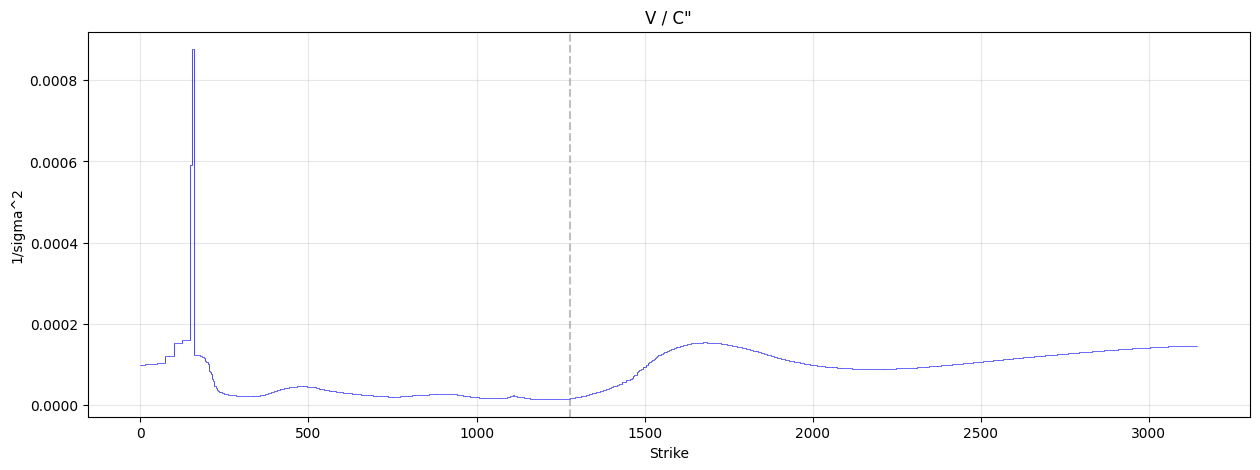

Date:  20110105
ExDate:  20110219
Checking regression constraints for 156 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


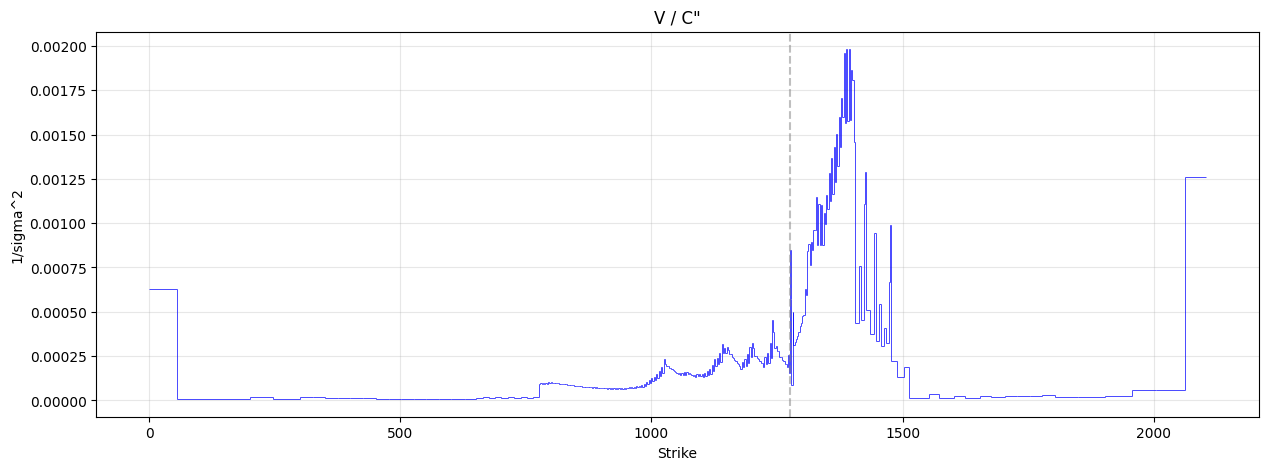

-11.588982315148998 -15.750527040002133 -16.71405213298381 -16.7140521335977


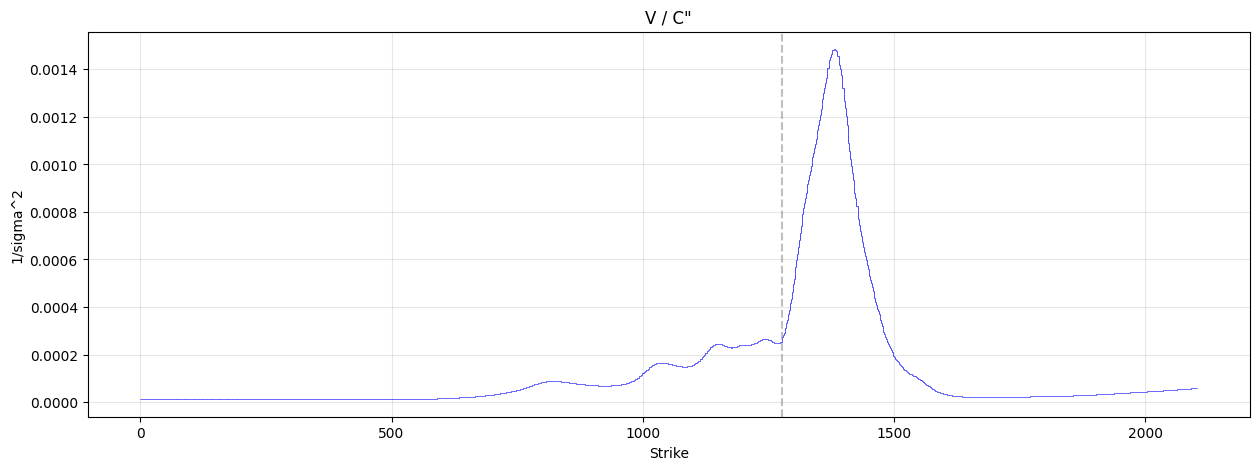

Date:  20110105
ExDate:  20110416
Checking regression constraints for 40 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


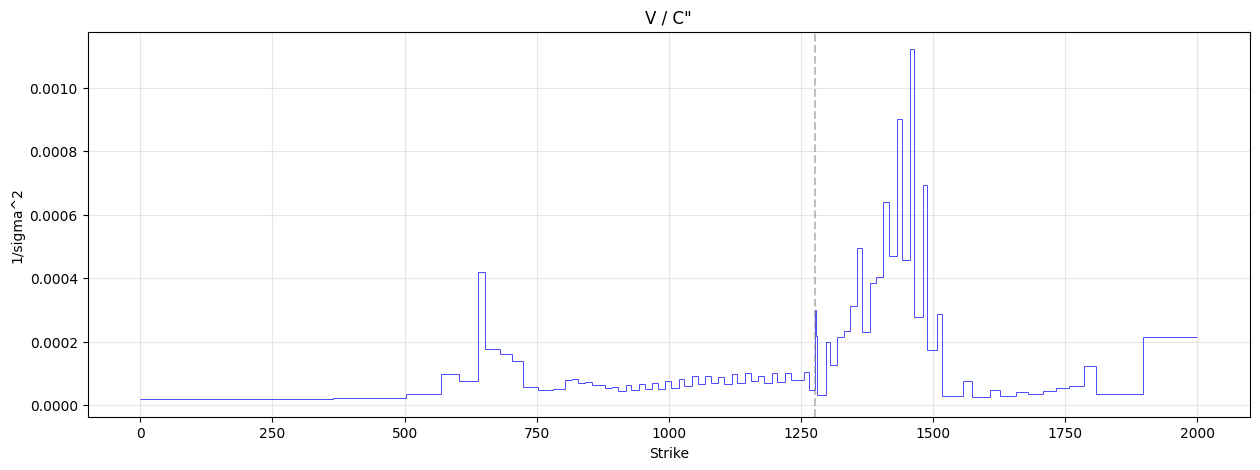

-12.82668395095524 -17.985967653479225 -19.140736405638968 -19.141348653589624


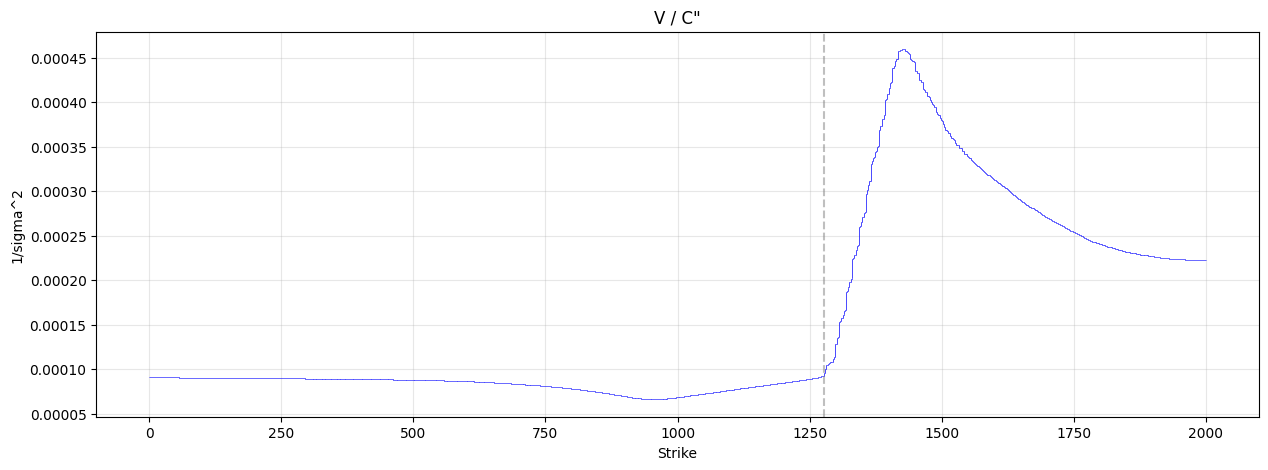

Date:  20110105
ExDate:  20110618
Checking regression constraints for 67 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


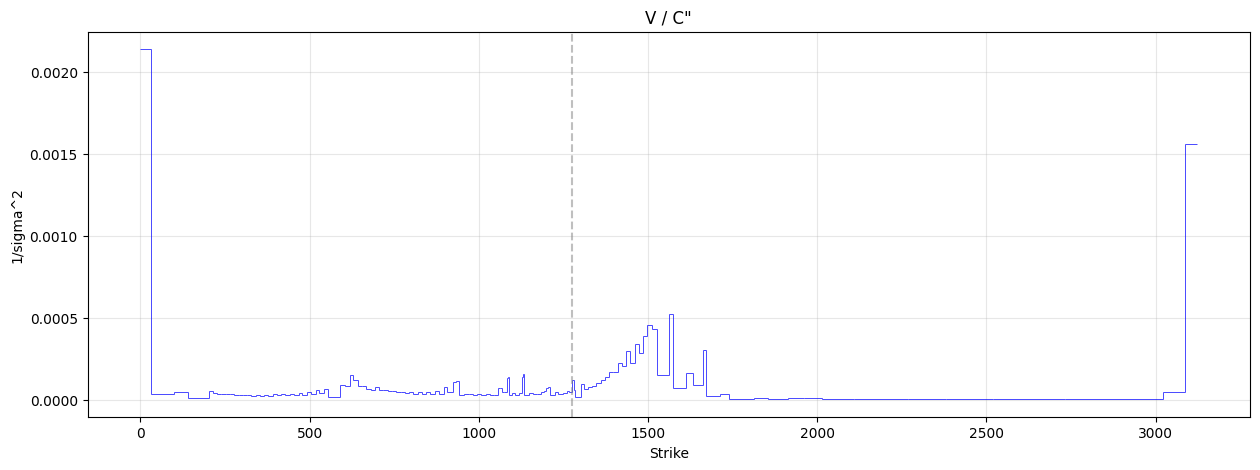

-11.805316995495732 -19.11544050353161 -19.69937874434179 -19.70075297992045


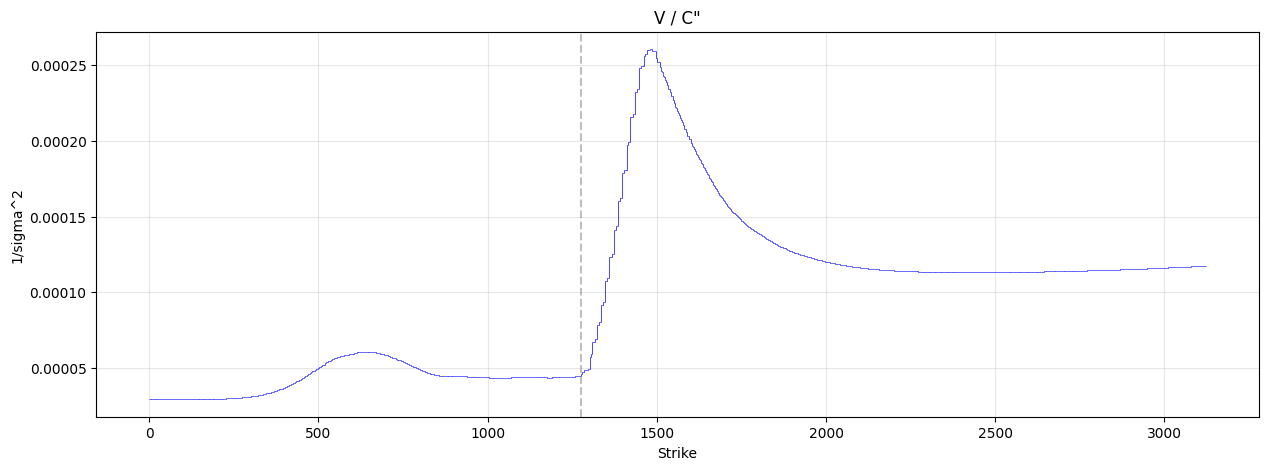

Date:  20110105
ExDate:  20110107
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


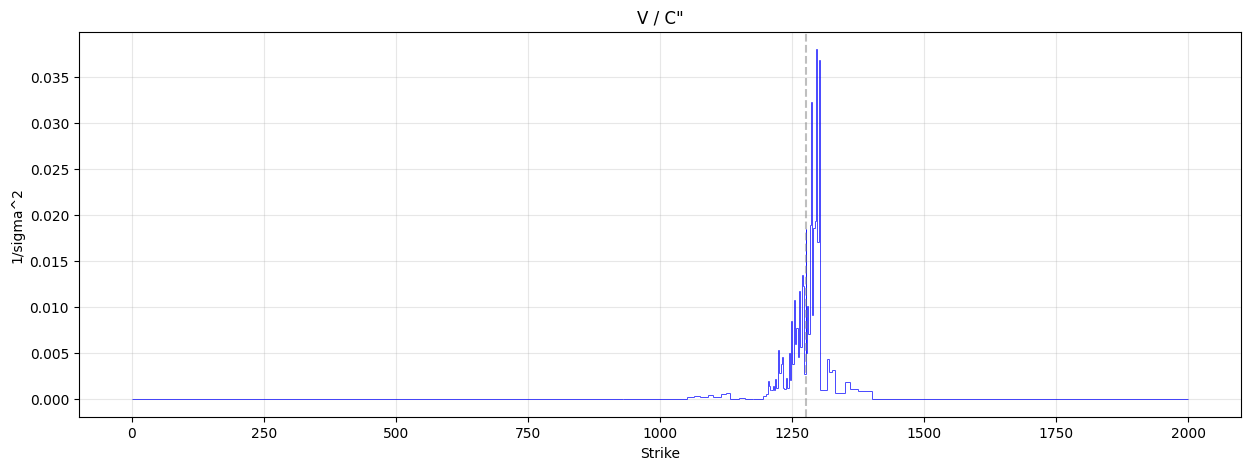

-5.4692788219738455 -8.941912541967813 -9.18457620114873 -9.184576201523992


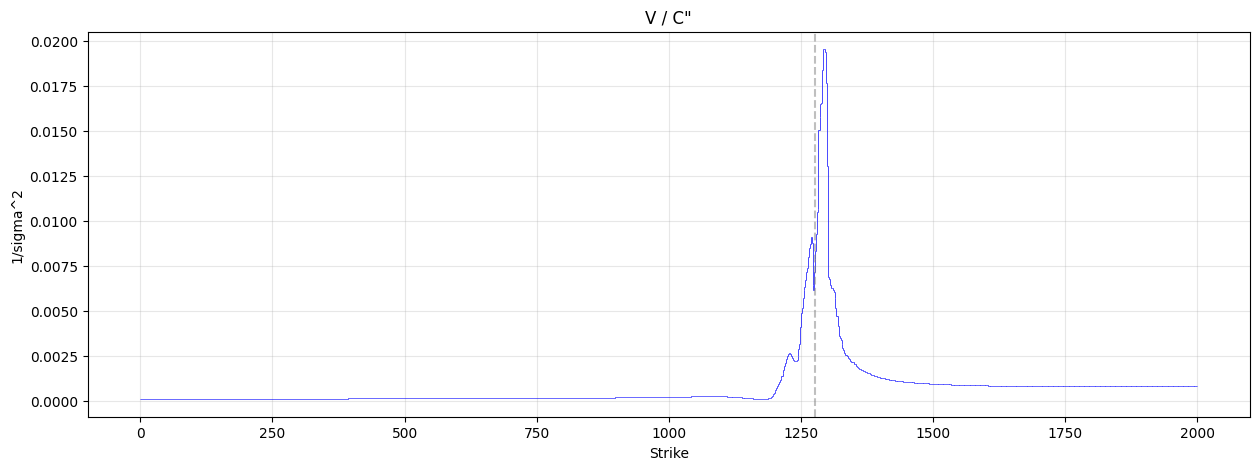

Date:  20110105
ExDate:  20110331
Checking regression constraints for 39 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


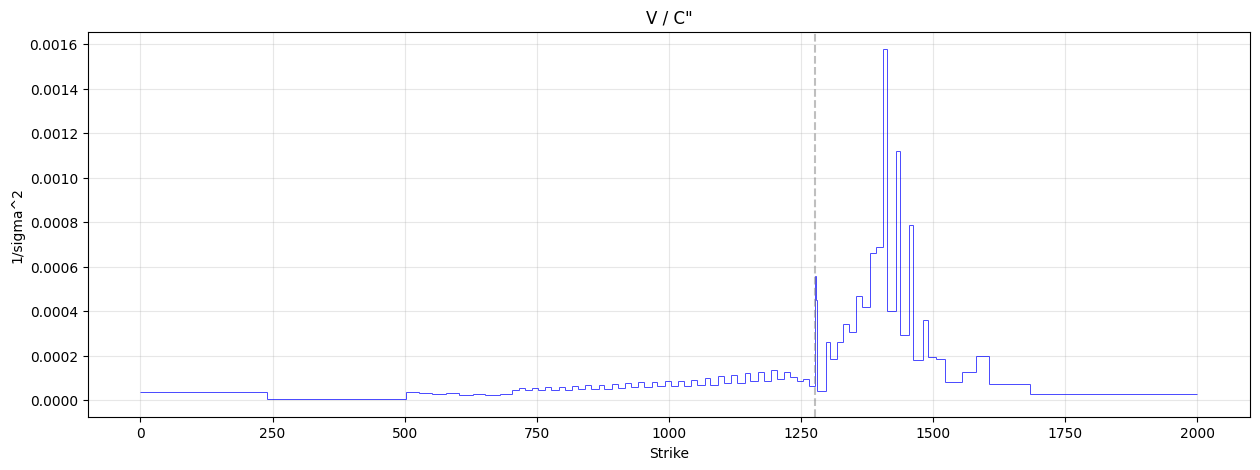

-12.268212184887616 -17.491416561962144 -19.226555566999828 -19.226773813116544


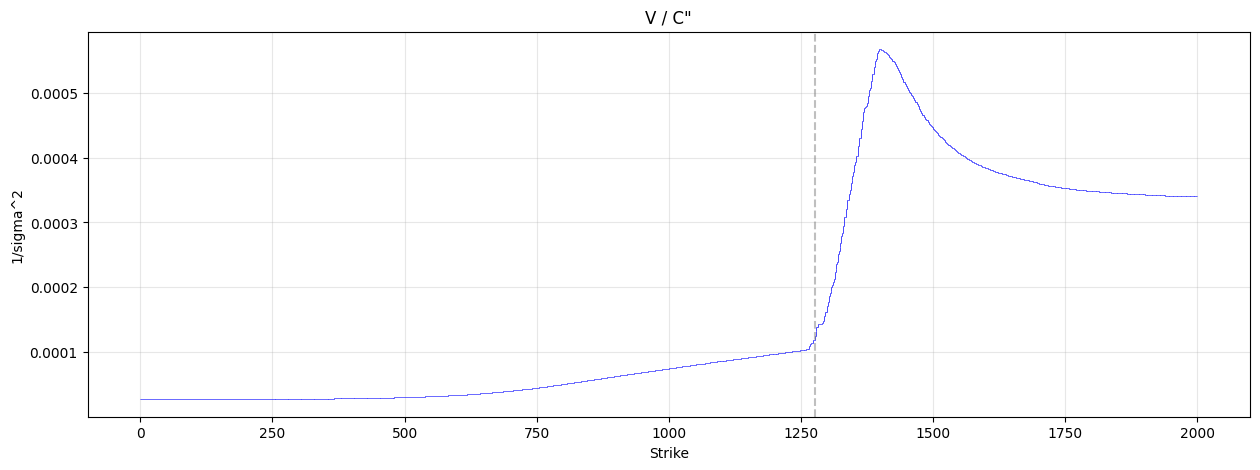

Date:  20110105
ExDate:  20110630
Checking regression constraints for 27 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


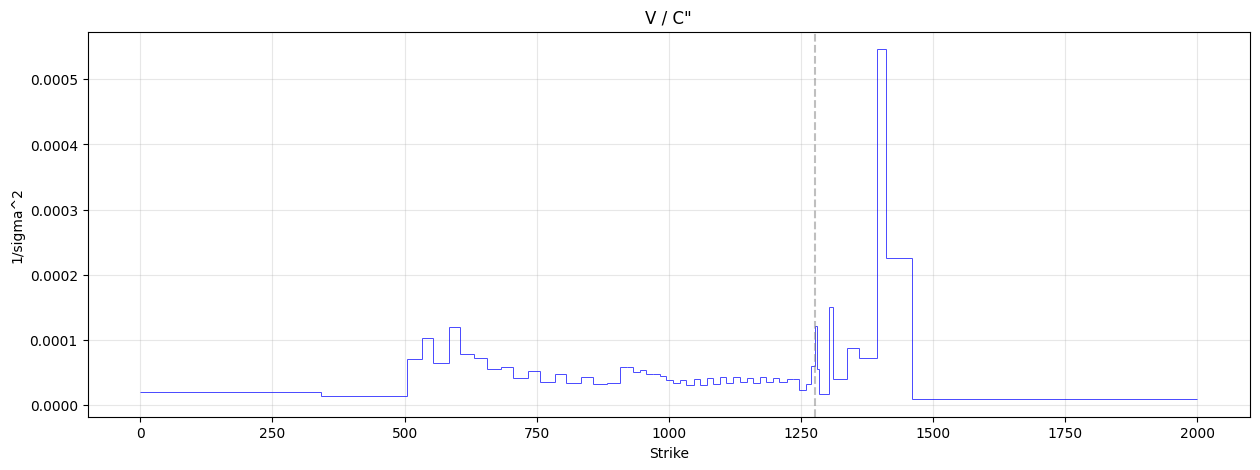

Doesn't satisfy!!!!
Doesn't satisfy!!!!
-14.657375002255142 -19.724246431565675 -21.130864485228642 -21.932075141385056


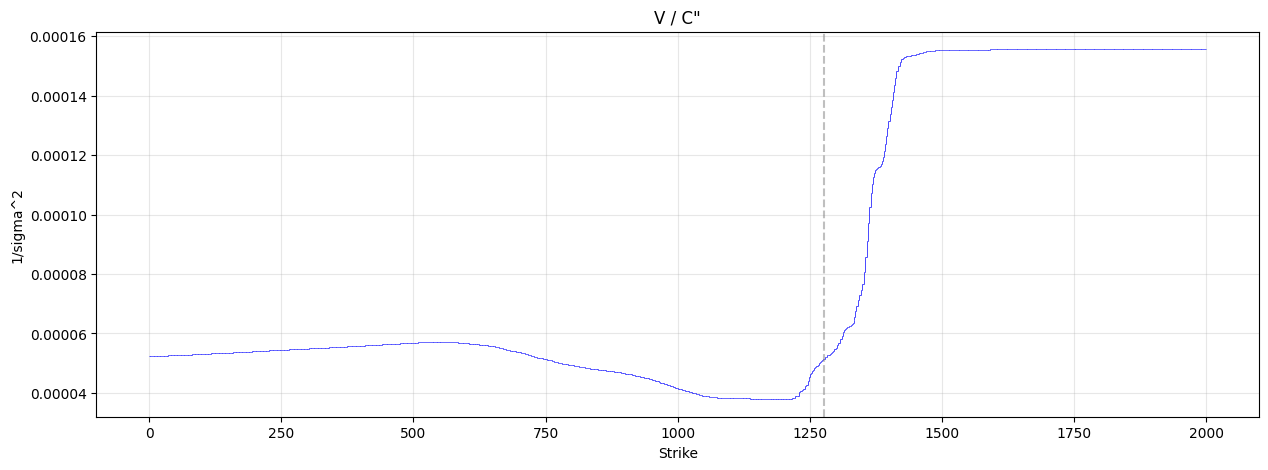

Date:  20110105
ExDate:  20110917
Checking regression constraints for 55 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


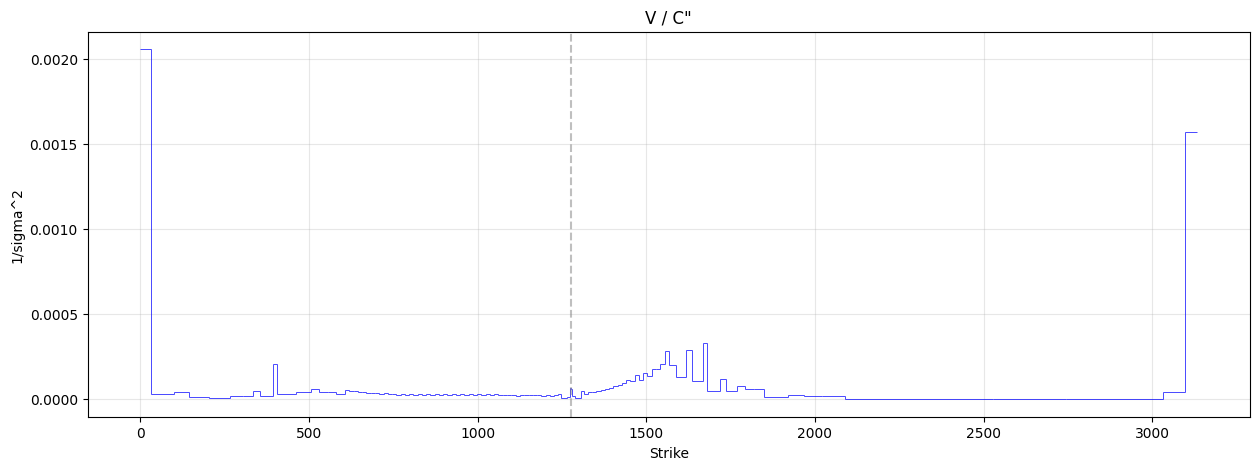

-11.910857282298284 -20.828187420660033 -21.249119166032273 -21.249217345421023


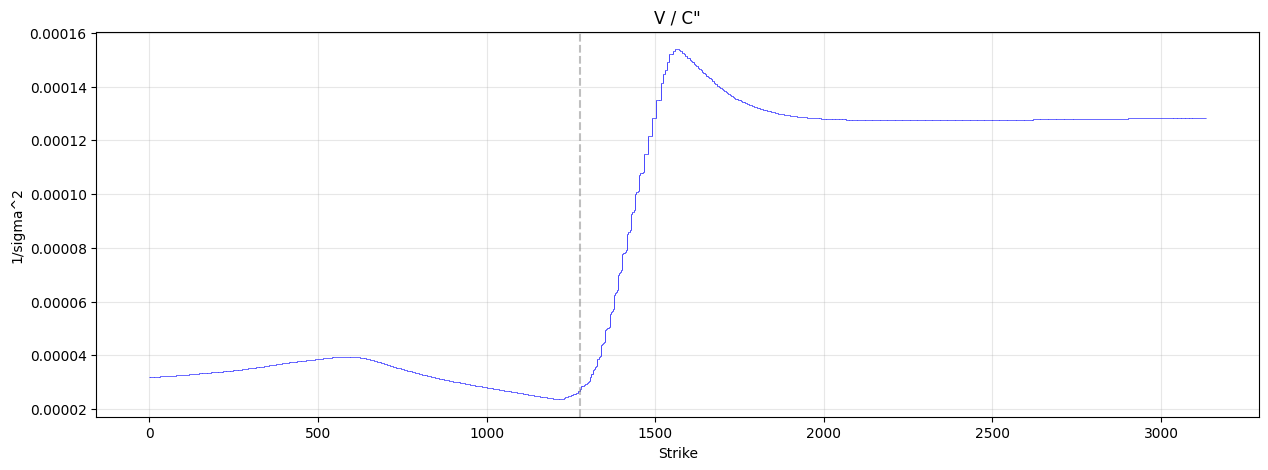

Date:  20110105
ExDate:  20110930
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


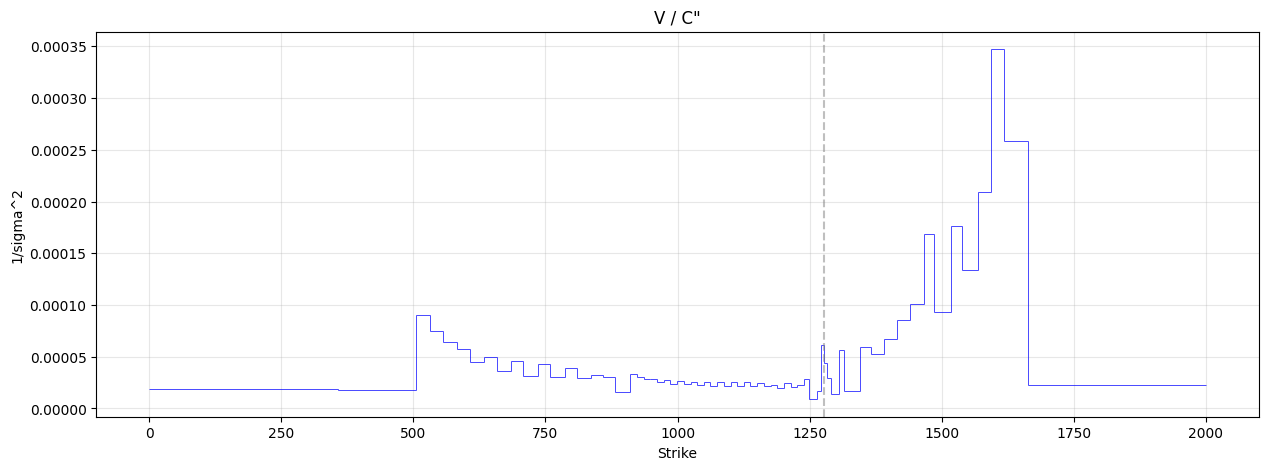

-15.905741132072874 -20.139458791665422 -22.056303837087928 -22.060401481142446


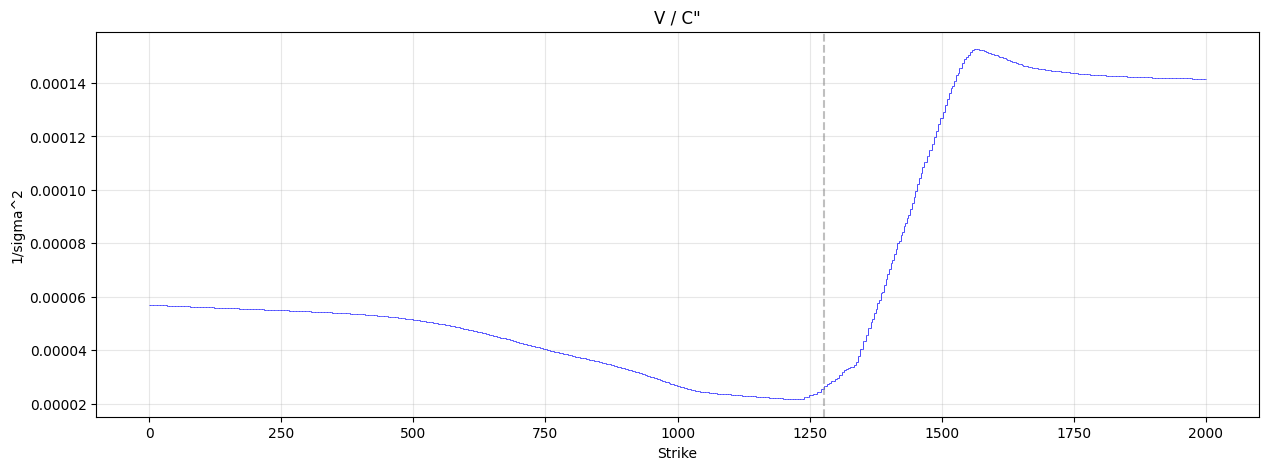

Date:  20110105
ExDate:  20111230
Checking regression constraints for 24 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


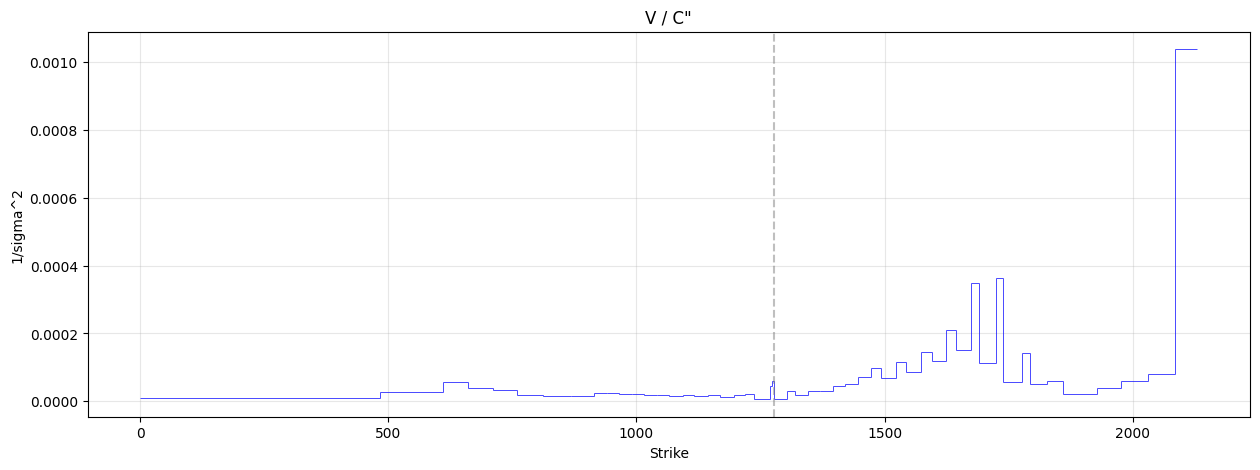

-13.617846961090173 -19.190288867193072 -21.77935904538648 -21.91040520927202


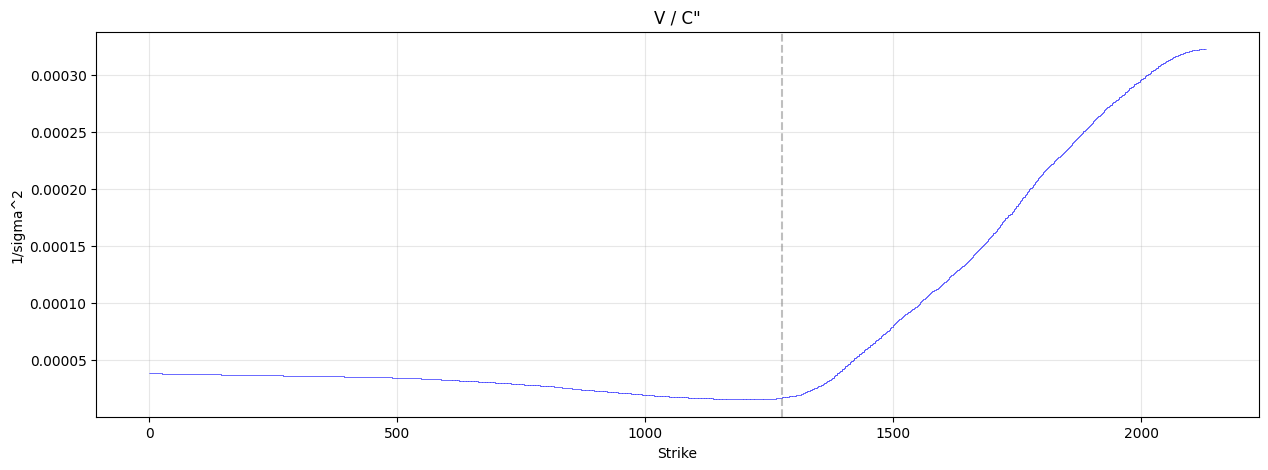

Date:  20110106
ExDate:  20110122
Checking regression constraints for 159 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


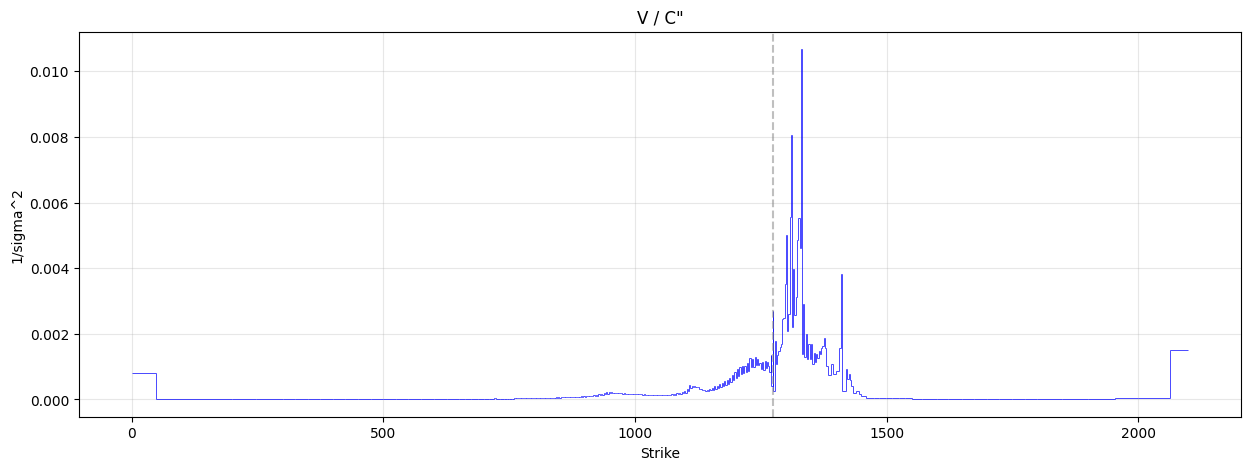

-8.34011742503911 -11.627280248630854 -13.67378453265178 -13.673784534405991


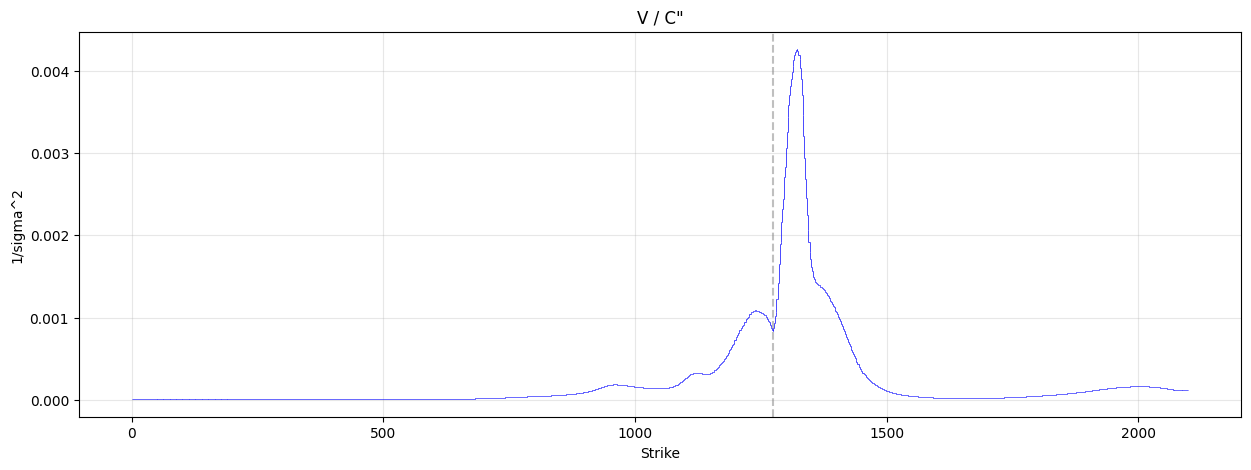

Date:  20110106
ExDate:  20110319
Checking regression constraints for 123 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


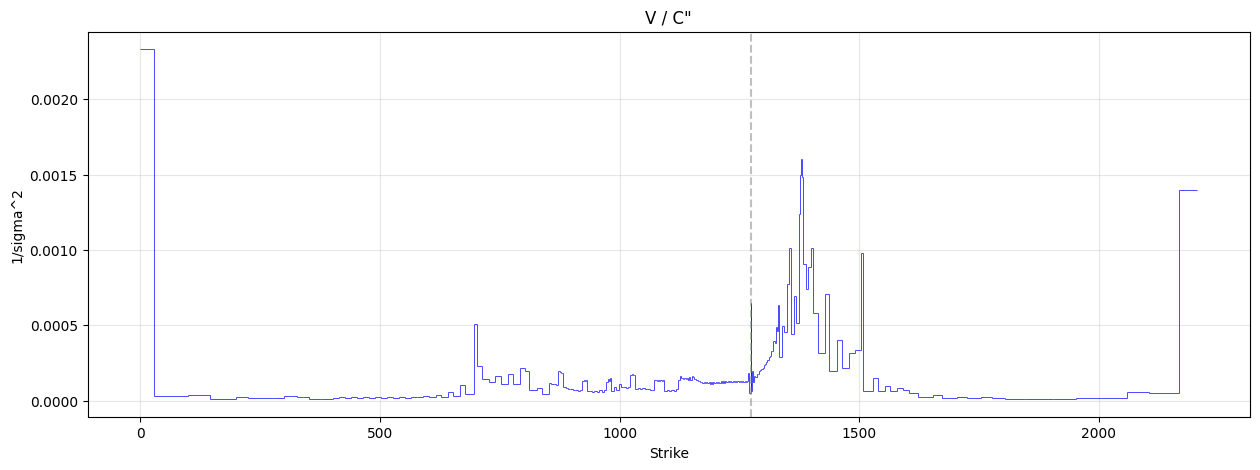

-11.330513394330323 -17.43970762961472 -18.115656079657803 -18.11739334777665


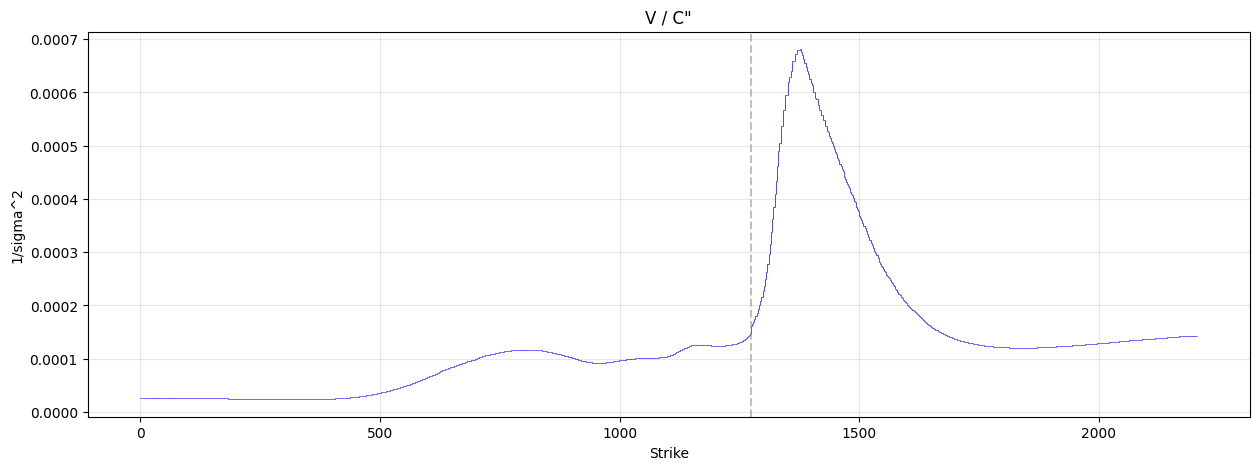

Date:  20110106
ExDate:  20111217
Checking regression constraints for 68 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


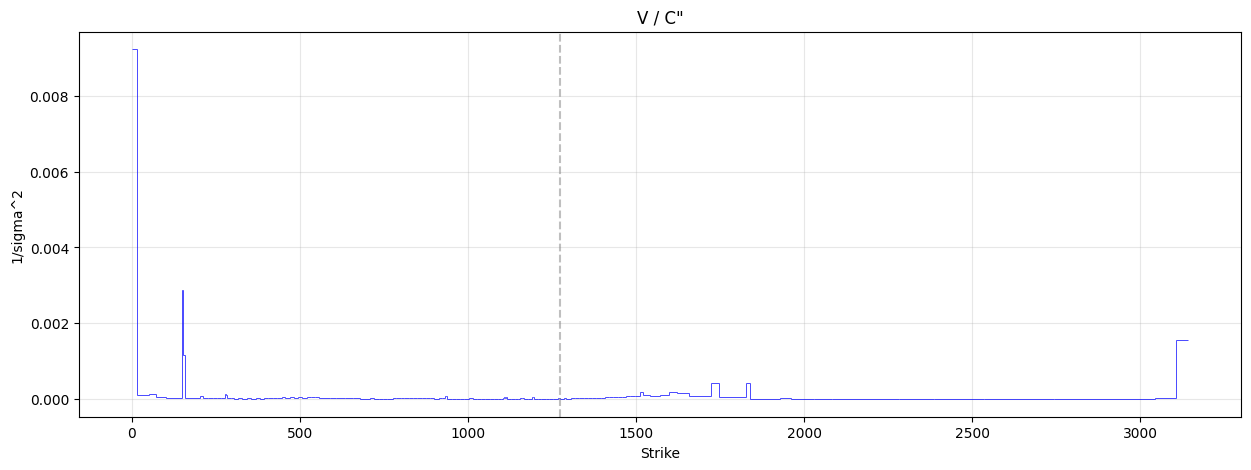

-9.225952386066956 -13.319082663114992 -13.41238649648039 -13.452927985740574


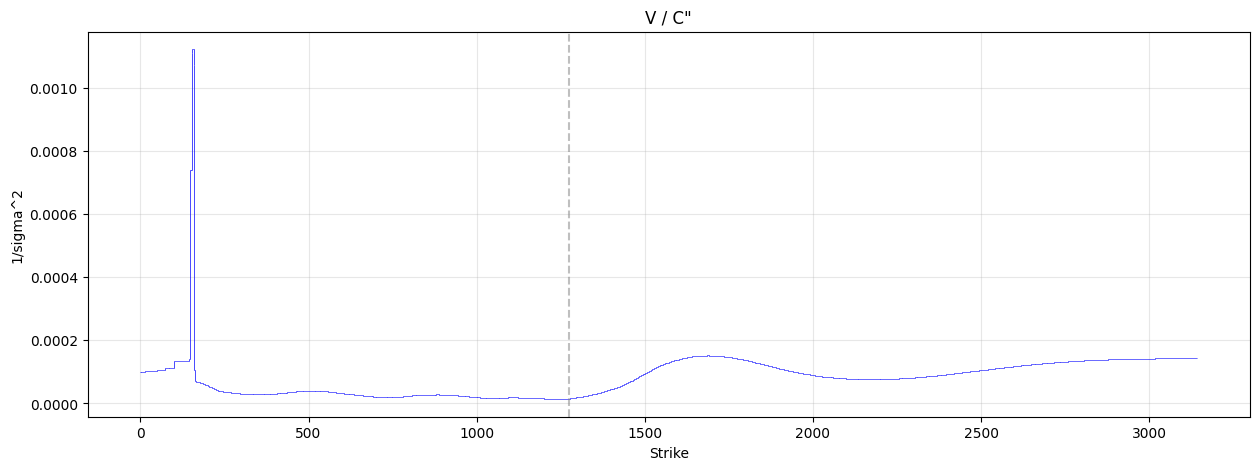

Date:  20110106
ExDate:  20110219
Checking regression constraints for 156 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


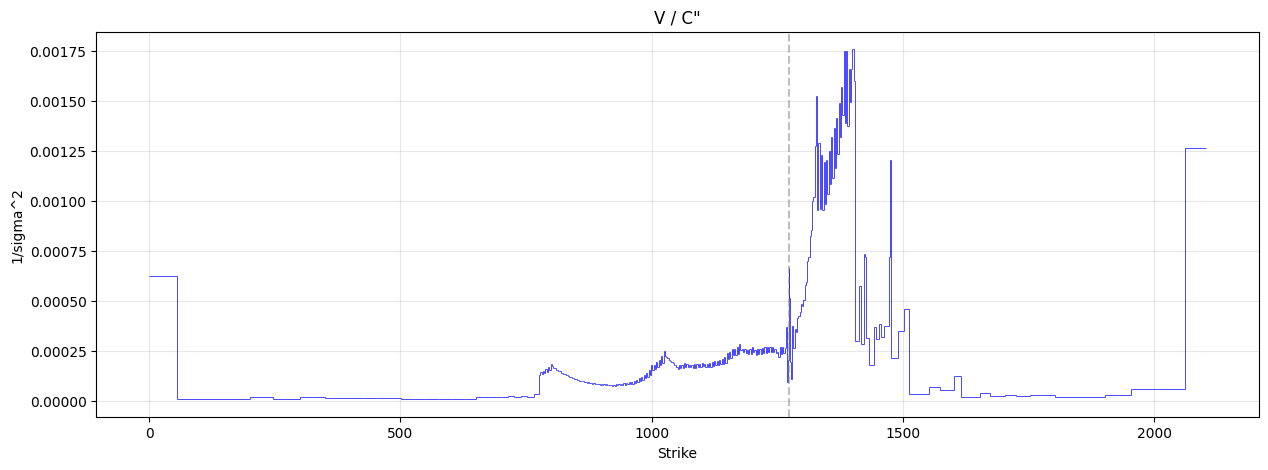

-11.667562753263383 -15.626664481734887 -16.67450063764559 -16.67450063875274


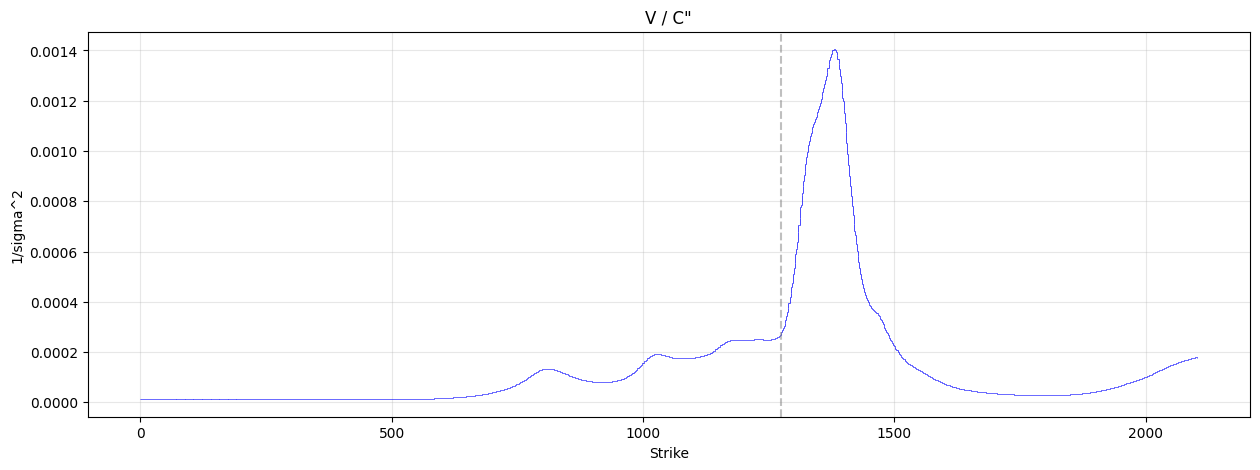

Date:  20110106
ExDate:  20110416
Checking regression constraints for 40 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


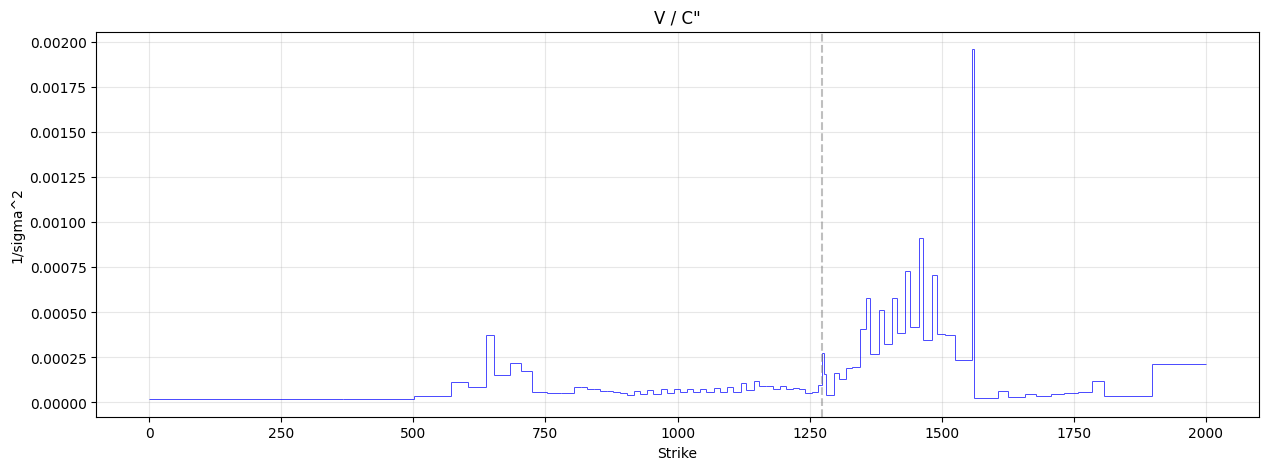

-11.680883510068135 -18.1320999437411 -19.60501605976269 -19.605016061269904


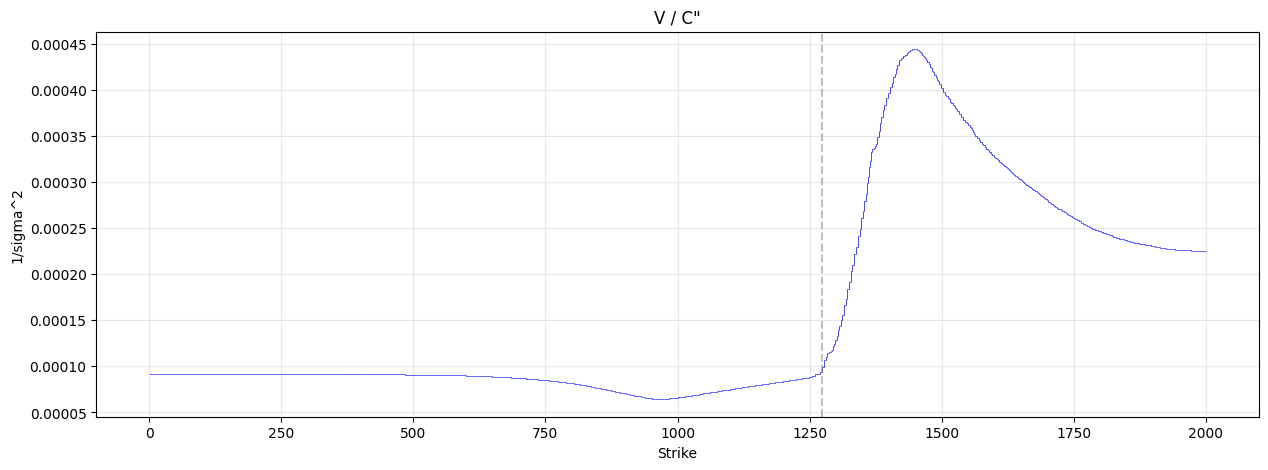

Date:  20110106
ExDate:  20110618
Checking regression constraints for 67 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


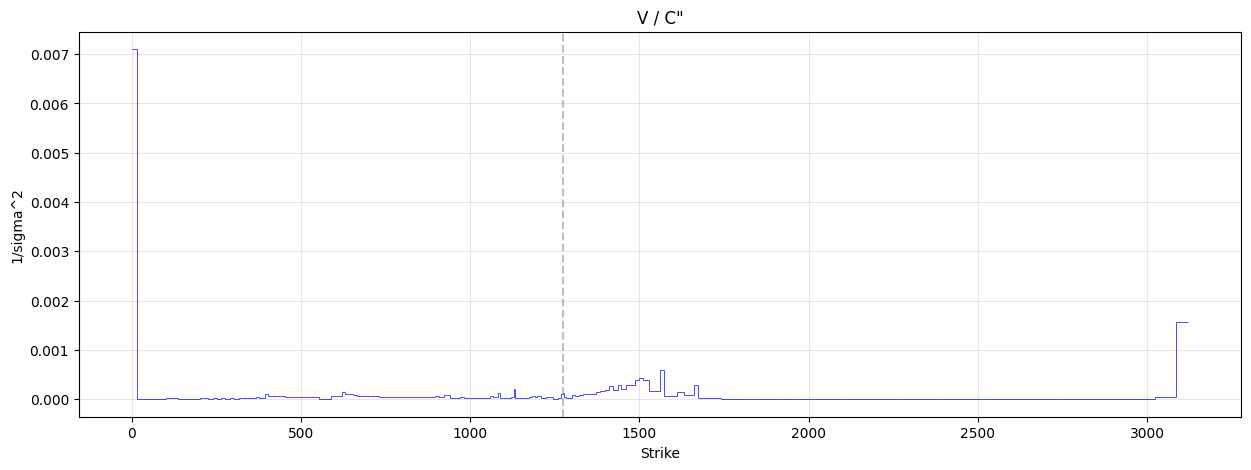

-9.838080355264754 -19.143415855072043 -19.605969258215517 -19.60665762258737


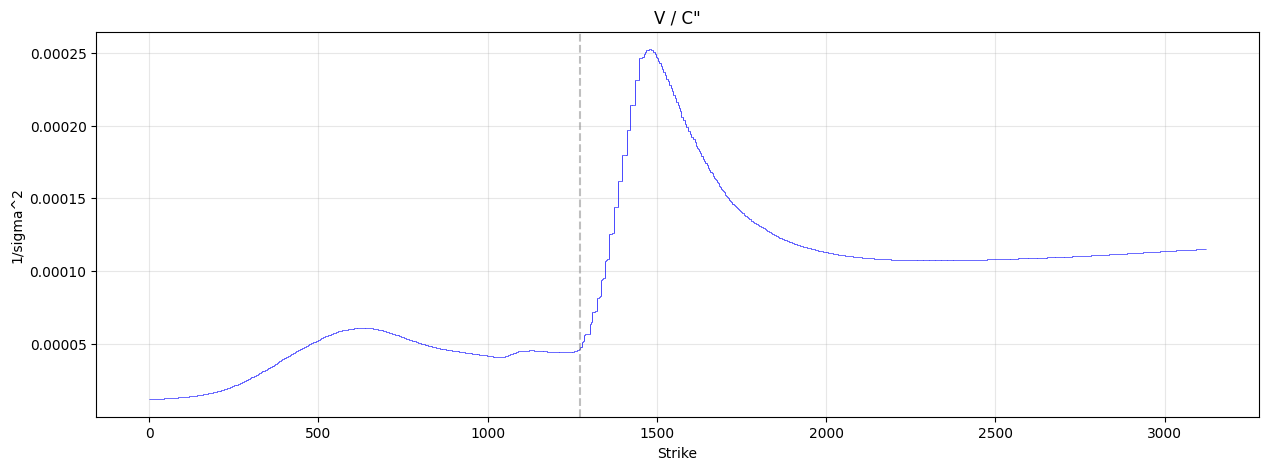

Date:  20110106
ExDate:  20110107
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


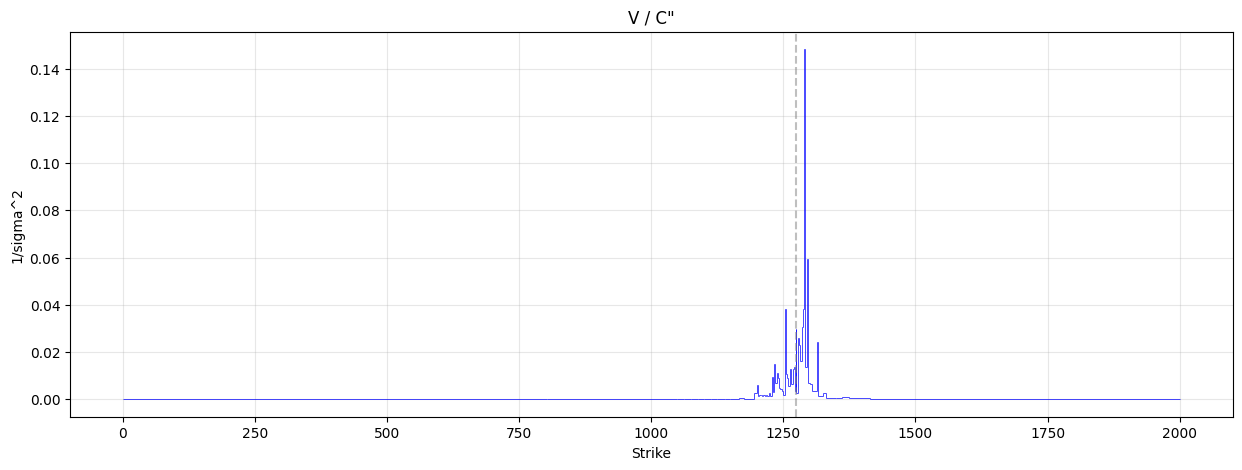

-3.2007832954338316 -8.478856874003197 -8.607501306873207 -8.607501306904854


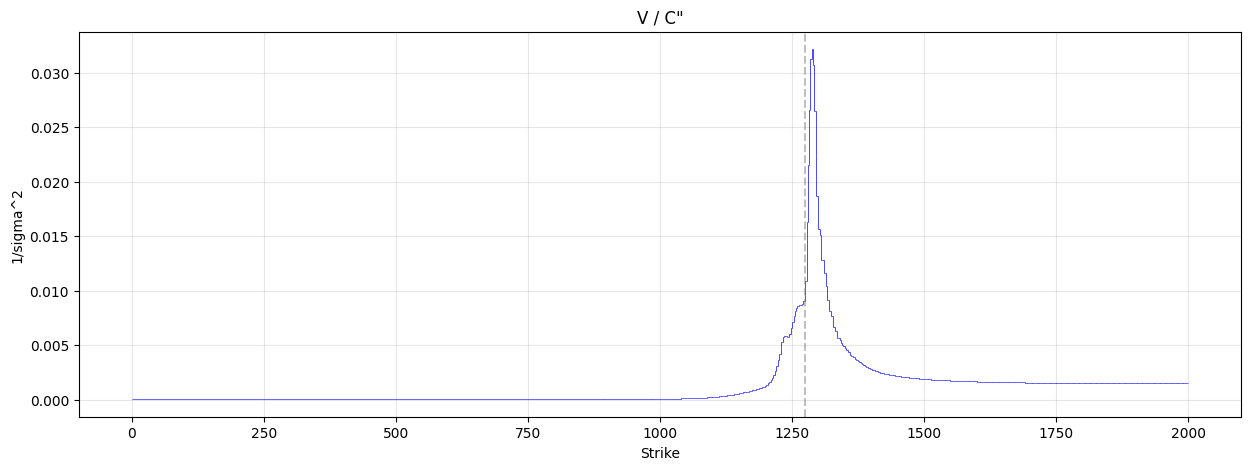

Date:  20110106
ExDate:  20110114
Checking regression constraints for 32 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


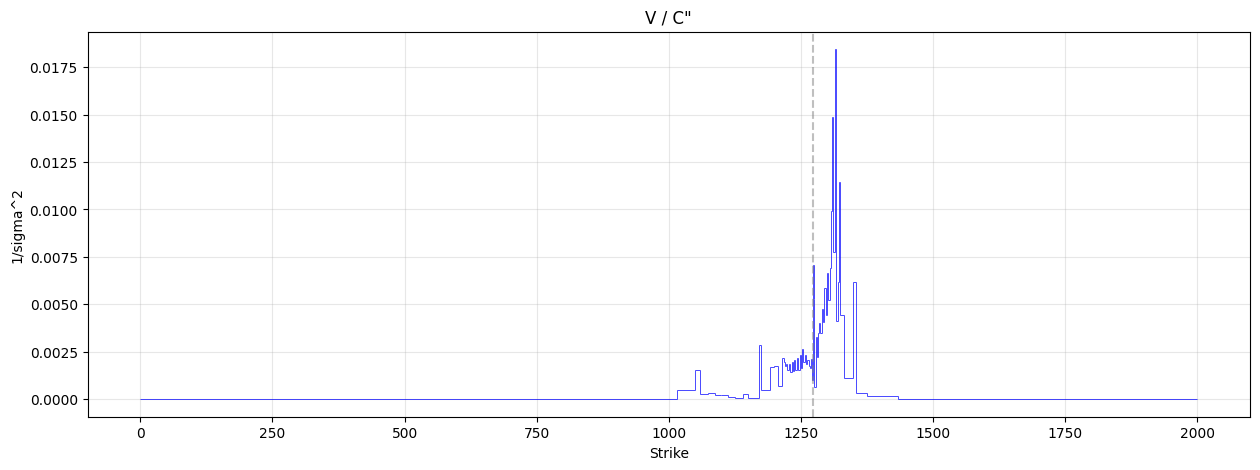

-7.307232022643244 -11.32602386717555 -11.821618942535427 -11.821747738968908


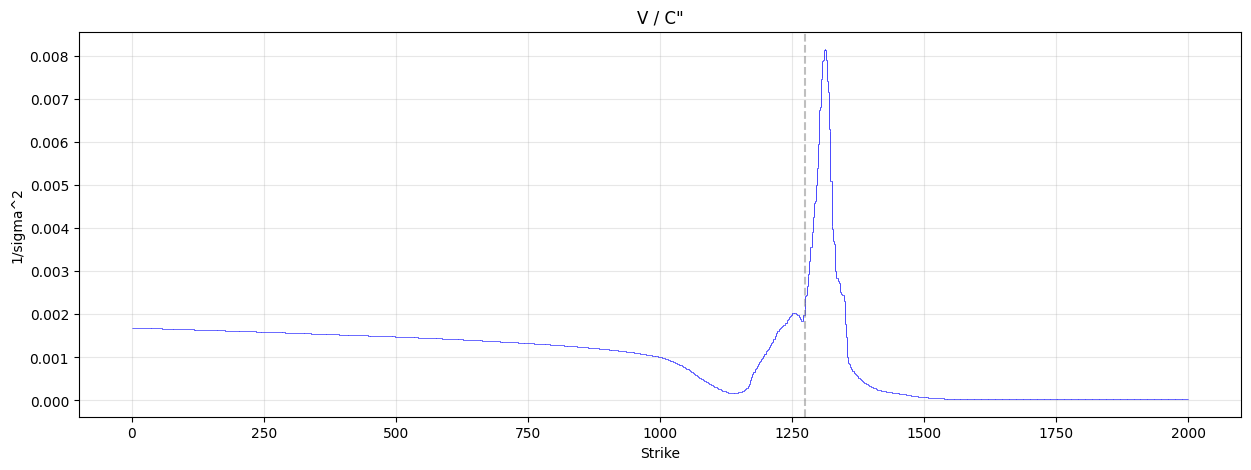

Date:  20110106
ExDate:  20110331
Checking regression constraints for 39 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


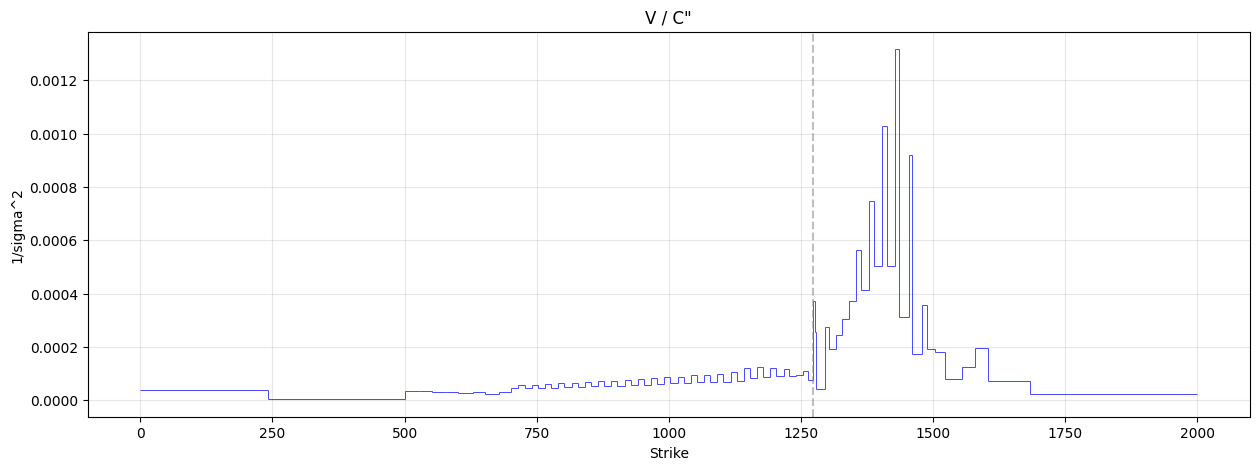

-12.50291299665697 -17.39052986904768 -18.331135460469454 -18.33357489101649


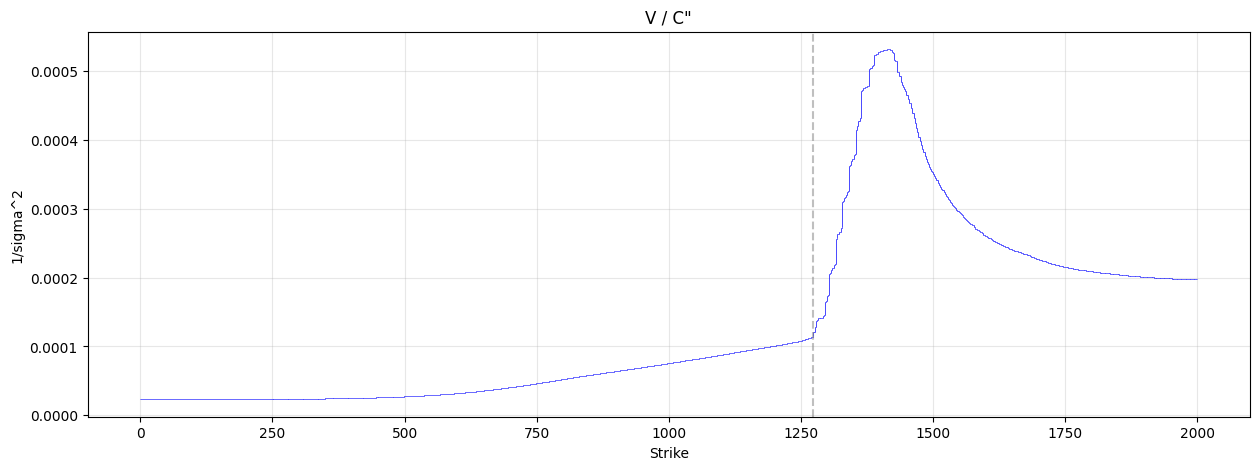

Date:  20110106
ExDate:  20110630
Checking regression constraints for 27 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


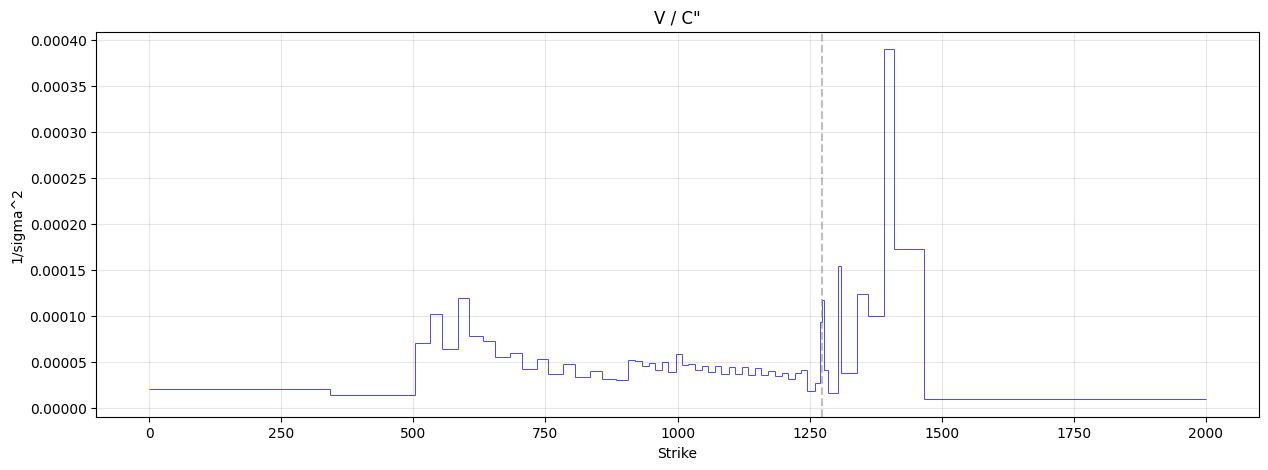

-15.30579254340529 -20.115395809008504 -22.17150862852814 -22.192472001868857


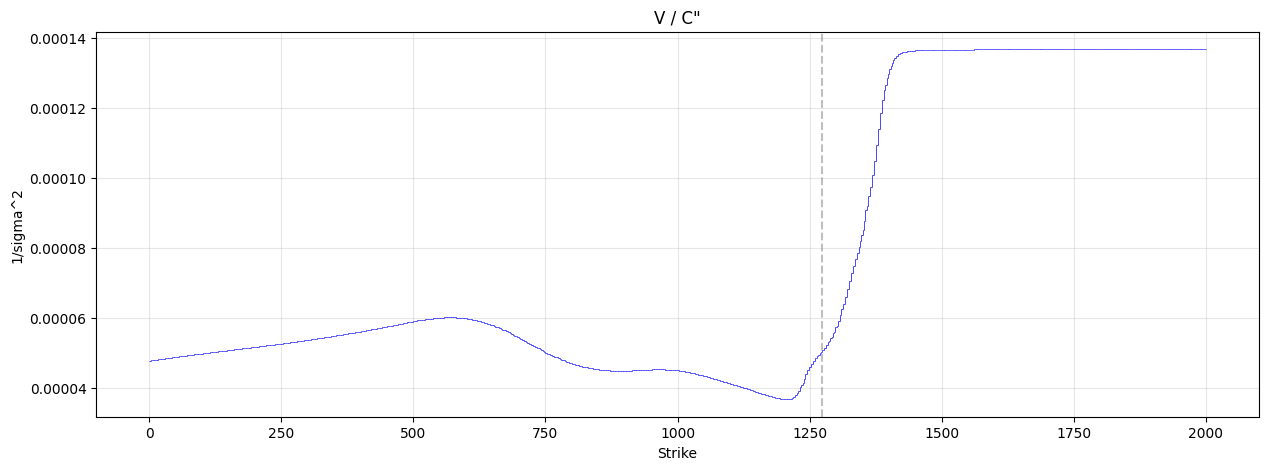

Date:  20110106
ExDate:  20110917
Checking regression constraints for 55 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


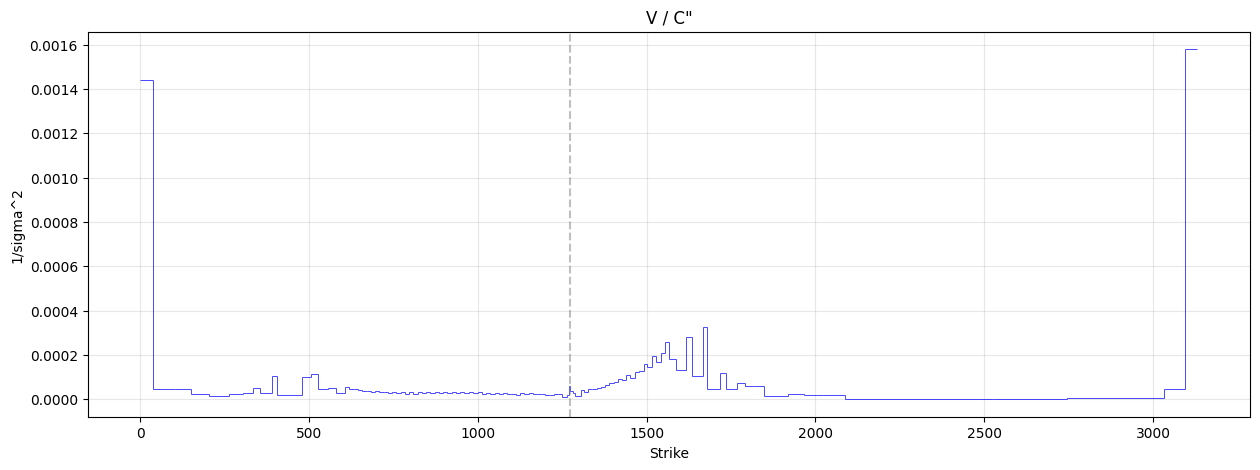

-12.302847531872585 -20.89742594870781 -21.408311814368318 -21.410876584651536


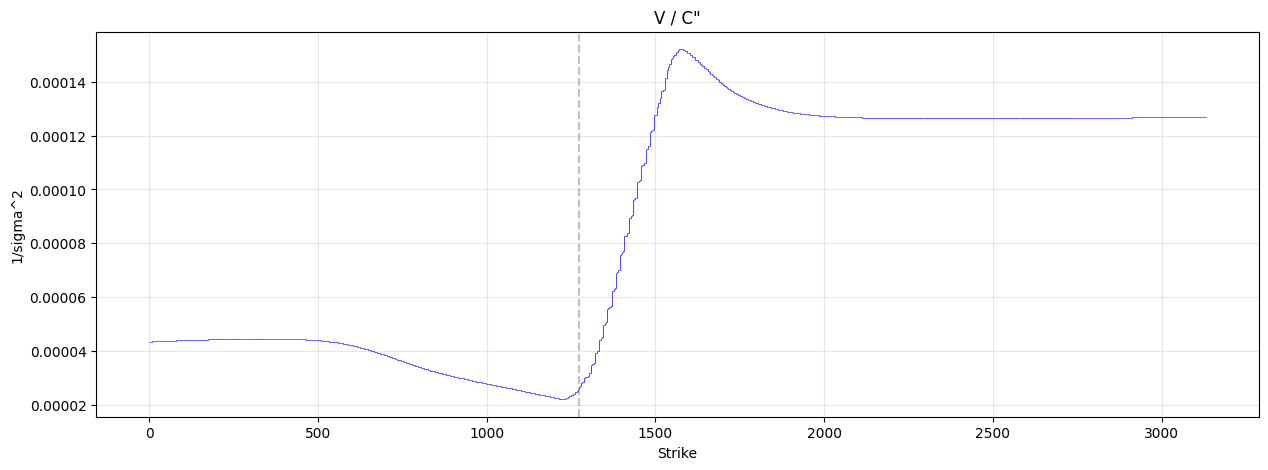

Date:  20110106
ExDate:  20110930
Checking regression constraints for 31 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


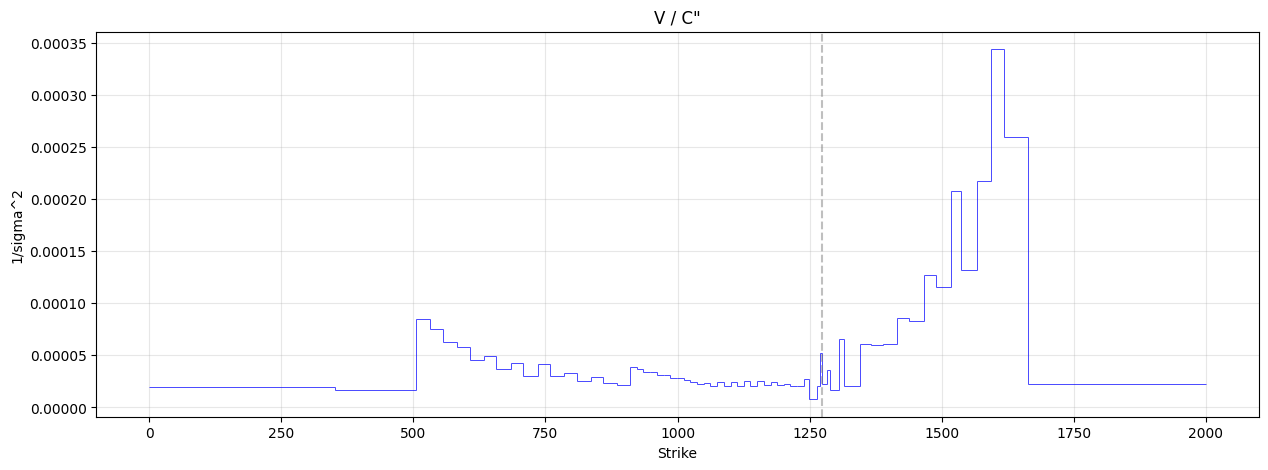

-15.942988475371816 -20.146104015431646 -21.915929259313288 -21.916355522673157


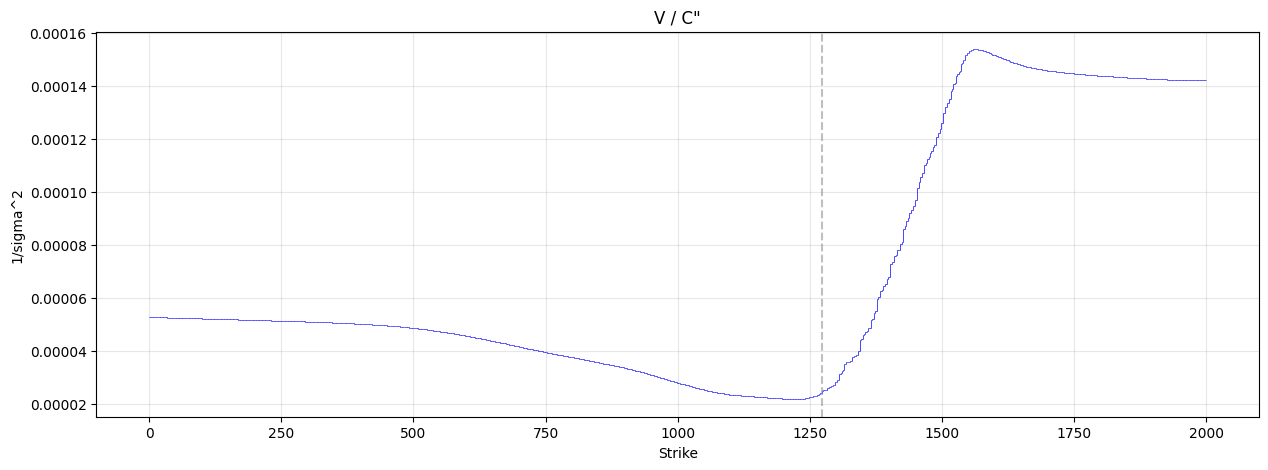

Date:  20110106
ExDate:  20111230
Checking regression constraints for 24 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


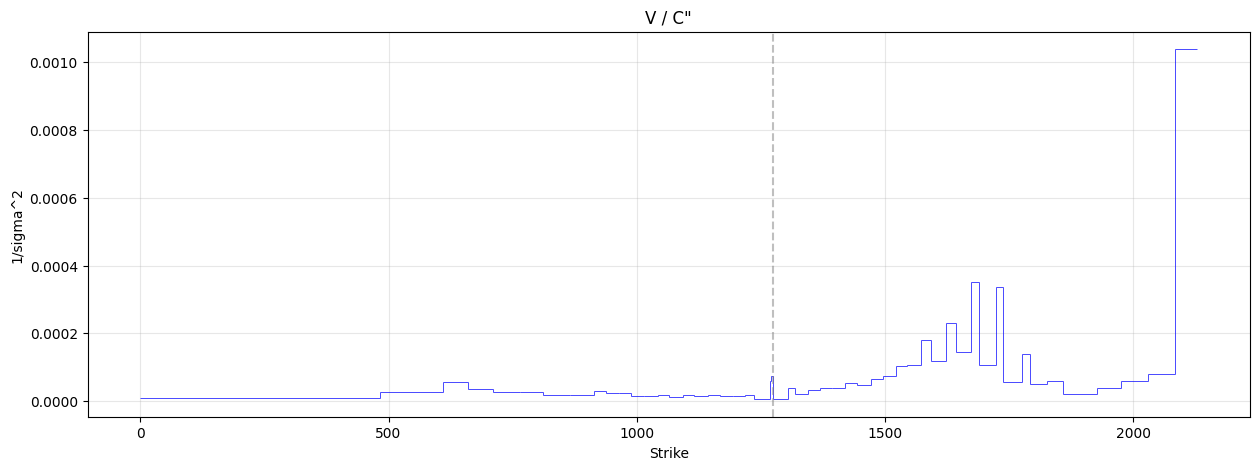

-13.622627706010825 -19.19616640926253 -21.98405166251583 -22.091112026718662


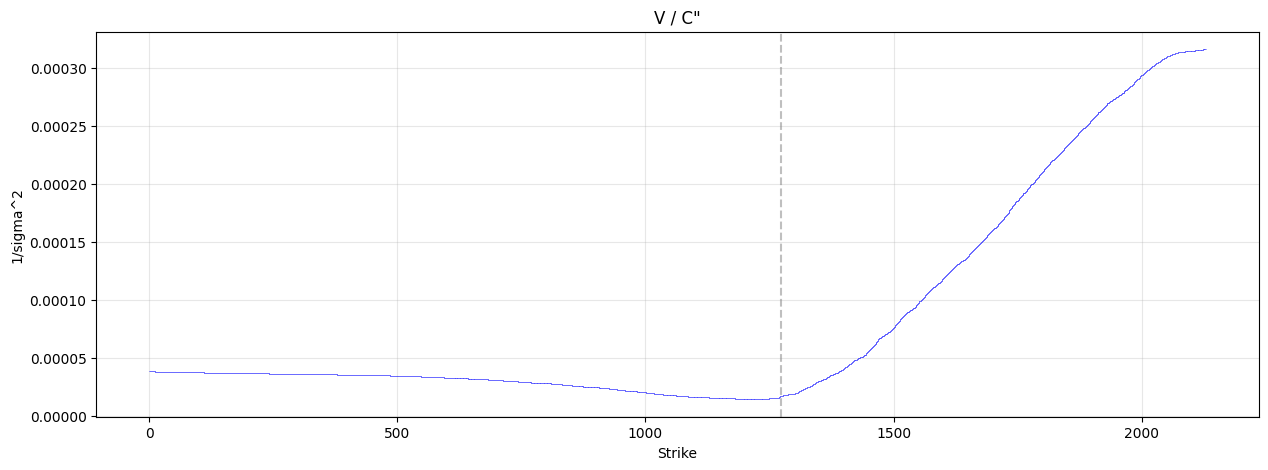

Date:  20110107
ExDate:  20110122
Checking regression constraints for 159 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


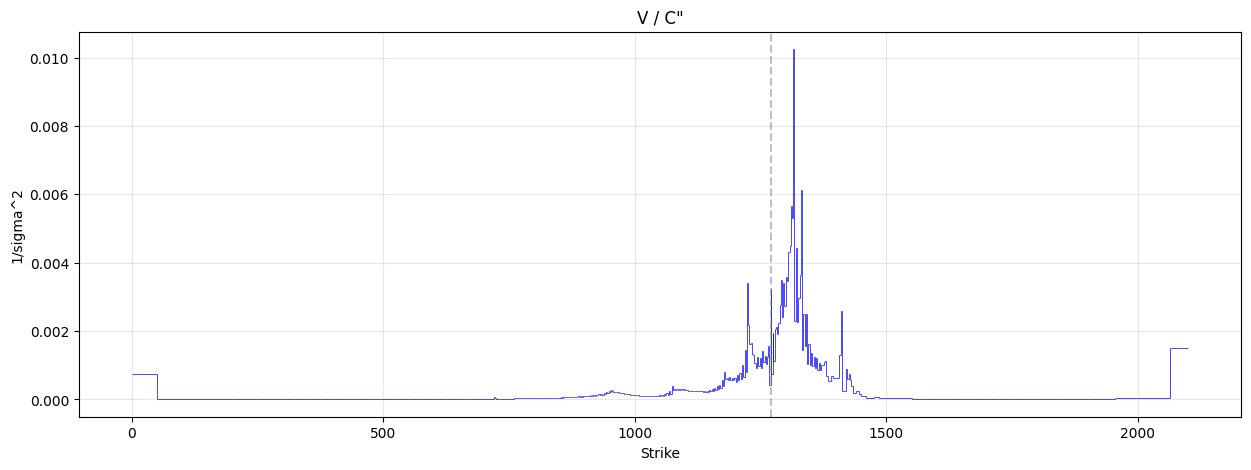

-8.642149117431092 -12.686869920115221 -13.904391257776968 -13.904391261082251


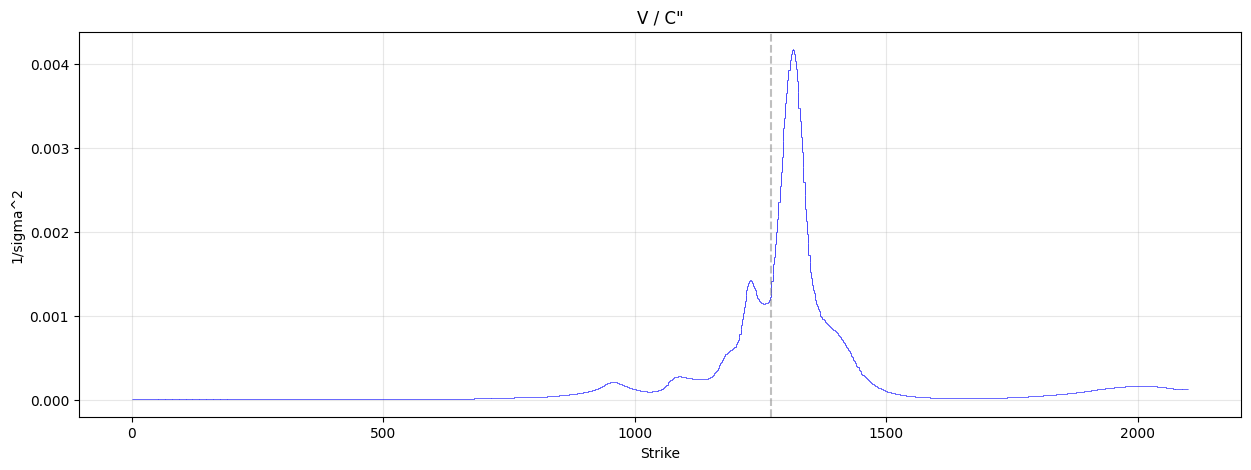

Date:  20110107
ExDate:  20110319
Checking regression constraints for 123 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


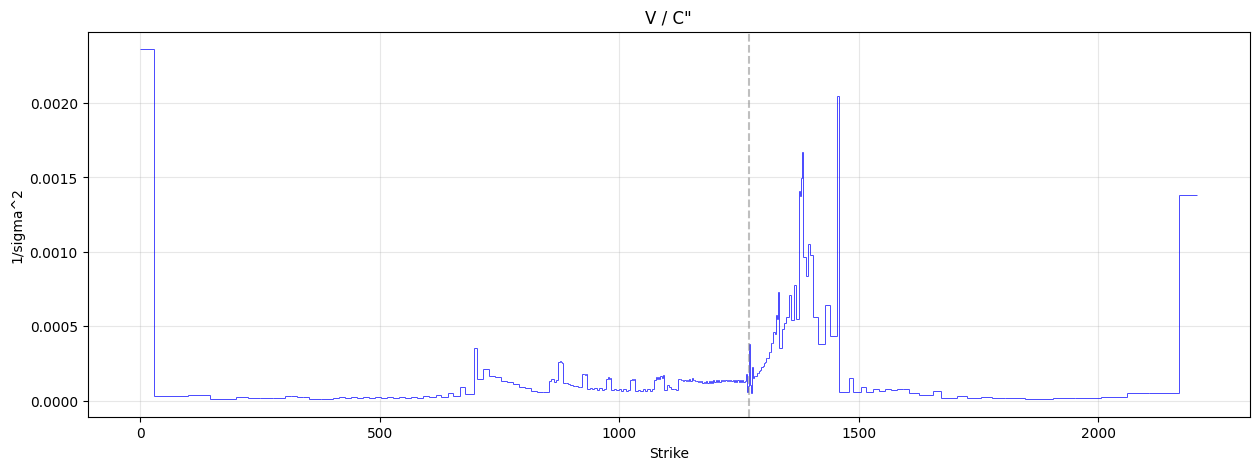

-11.024973025537237 -16.69802845572326 -18.13626509756108 -18.13835320568413


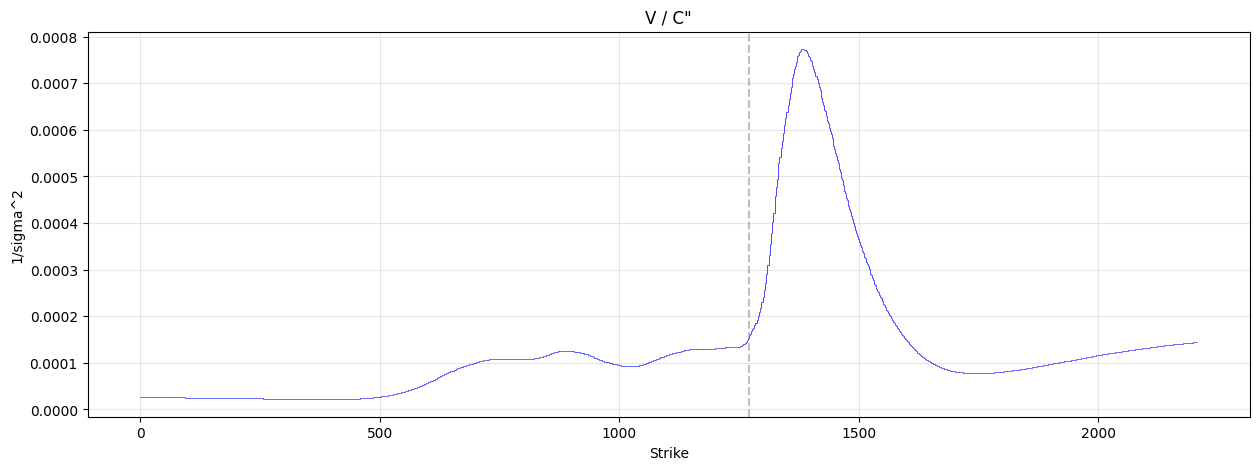

Date:  20110107
ExDate:  20111217
Checking regression constraints for 68 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


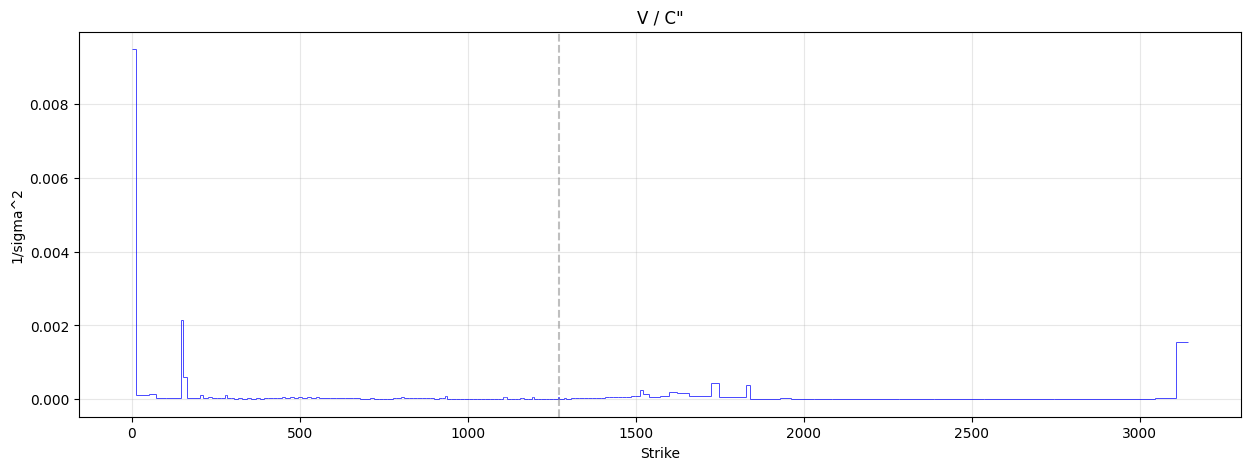

-9.231944555789749 -19.520791477594017 -20.28080924257089 -20.522909889561785


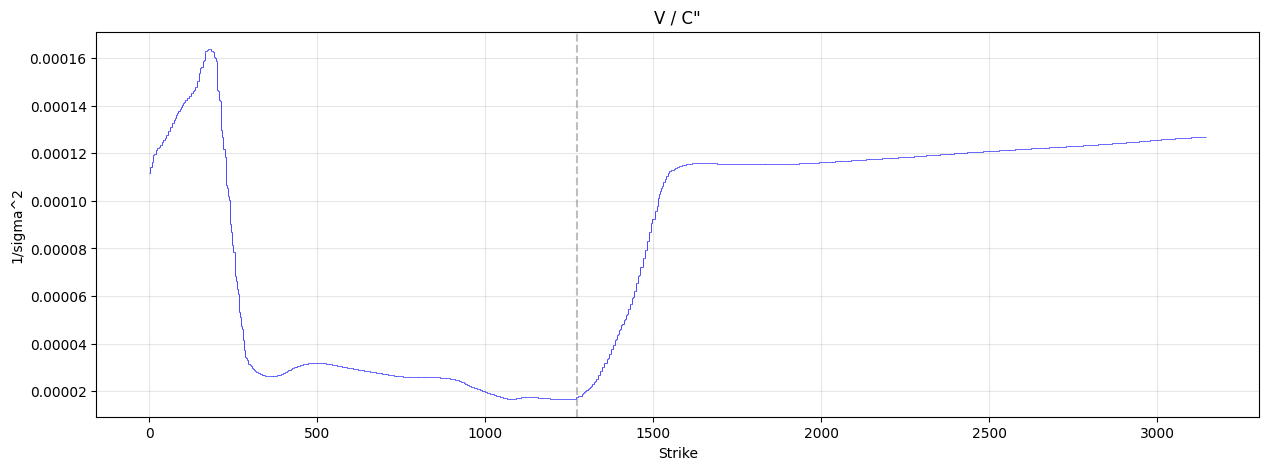

Date:  20110107
ExDate:  20110219
Checking regression constraints for 156 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


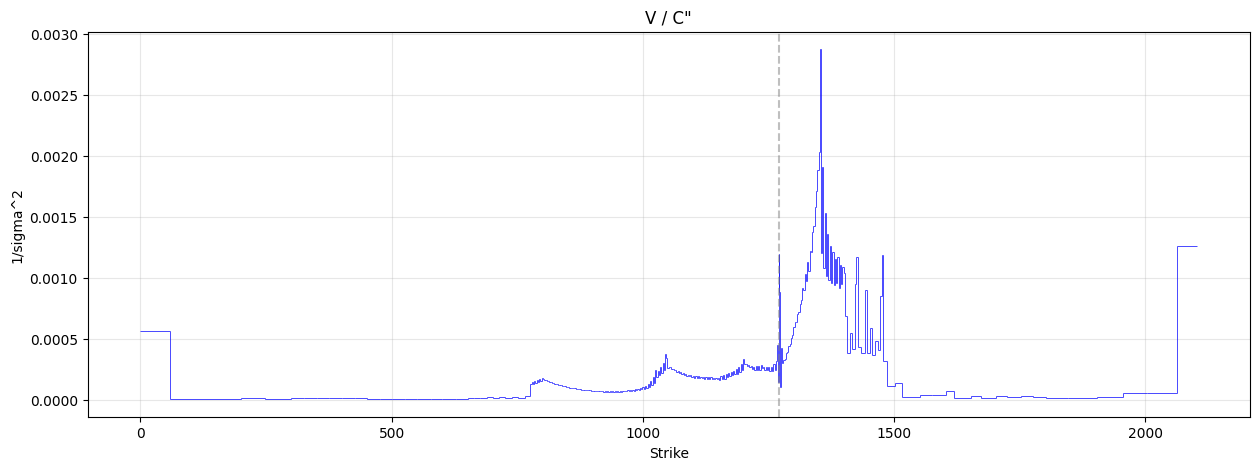

-11.247492131727915 -15.87658670393503 -16.740392313077027 -16.74039231561383


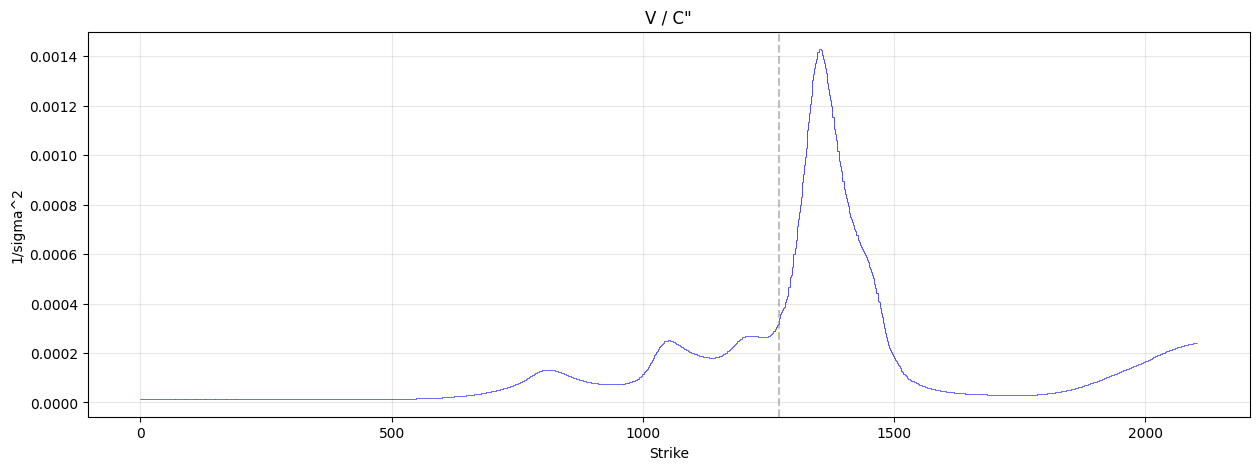

Date:  20110107
ExDate:  20110416
Checking regression constraints for 40 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


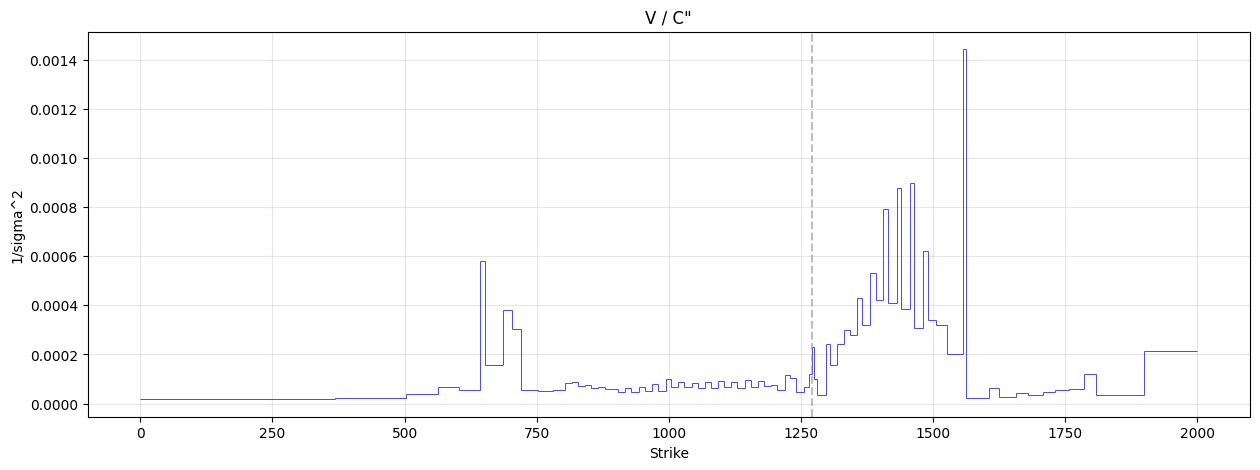

-12.034585921174498 -18.161910795097302 -18.88957908162284 -18.889645844394106


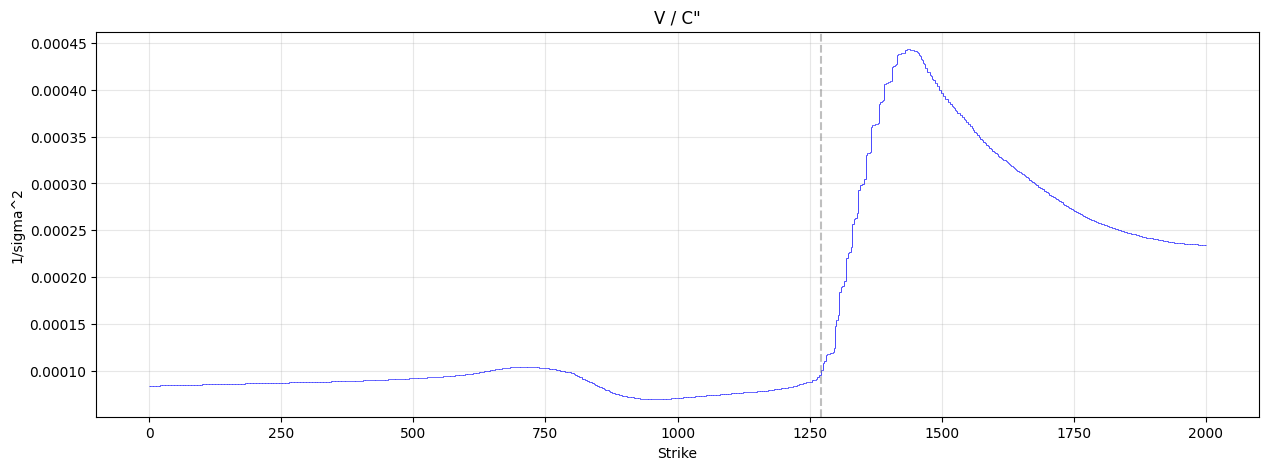

Date:  20110107
ExDate:  20110618
Checking regression constraints for 67 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


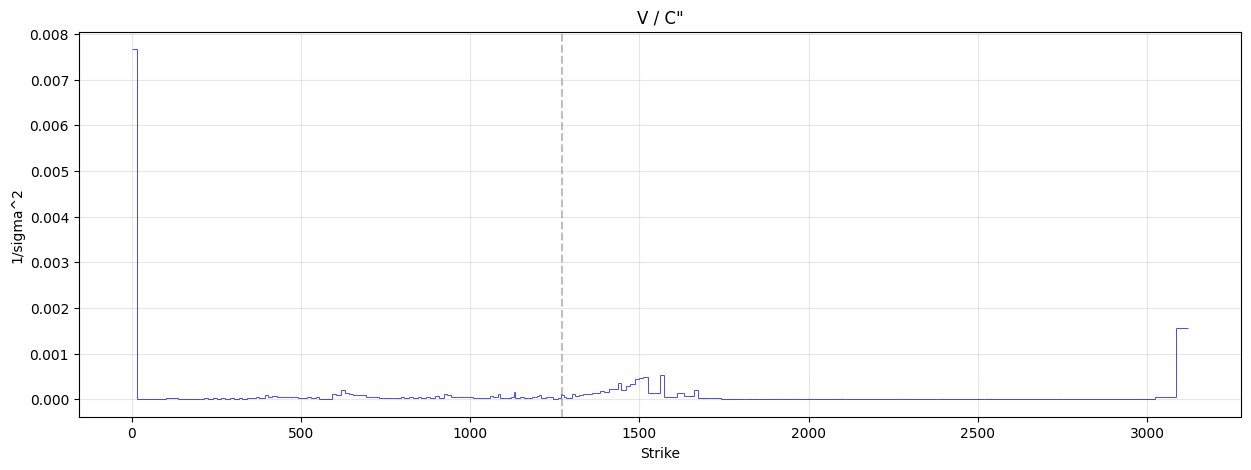

-9.693506883822439 -19.068415133496664 -19.686838485663237 -19.687416254803992


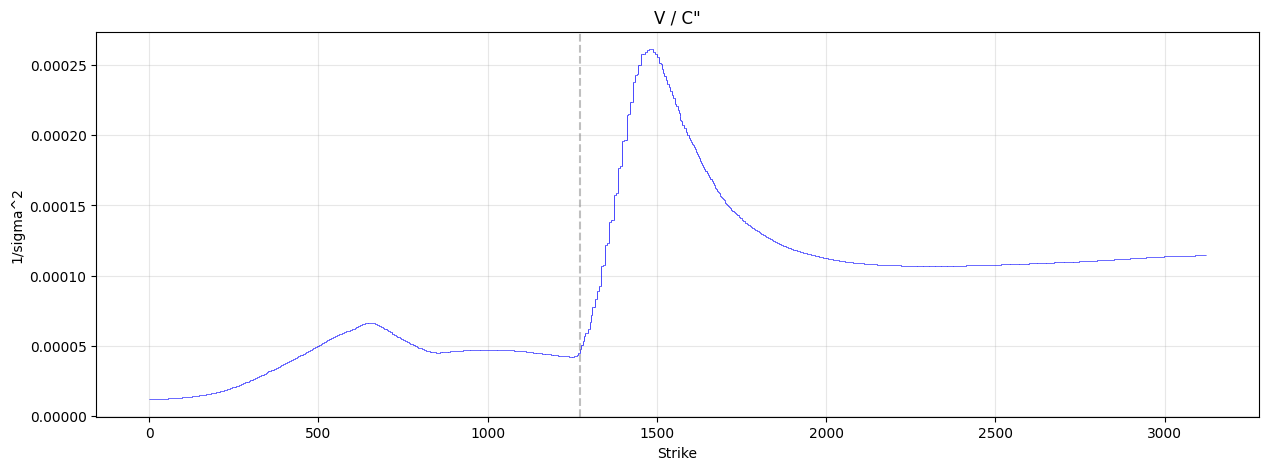

Date:  20110107
ExDate:  20110114
Checking regression constraints for 32 strikes:
Number of violations: 0
All predicted values are within the specified bounds.


SolverError: Solver 'CLARABEL' failed. Try another solver, or solve with verbose=True for more information.

In [5]:
import warnings
warnings.filterwarnings('ignore')

for i in range(100):
    test_index(i)